In [48]:
#imported from Pranav Sanghavi's notebook 
import glob 
import os 
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
from platform import python_version
import math
import psutil
import matplotlib.cm as cm
from scipy.stats import iqr
import pytz,pickle,yaml,sys
#importing for Will's extract_source_pulses function 
from scipy import interpolate
import datetime
from scipy.signal import square
from scipy.stats import pearsonr
import pandas
import time_utils as tu
from mpl_toolkits.axes_grid1 import make_axes_locatable

#import the beamcals module, use forked repository (not original):
#sys.path.insert(0, '../../classes/')
#import corr, concat, drone
#import plotting_utils as pu
#import fitting_utils as fu
#import geometry_utils as gu
import time_utils as tu
#import site_utils as si
#gbosite=si.Site('../../metadata/TONE_d5_config.npz')
#gbosite=si.Site('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/TONE_d5_config.npz')


style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
        This function converts seconds to degrees of sky motion at a latitude 
        default TONE latitude -- default for crab.
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
        This function reads all hdf5 files.
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(corr_dat):
    """
        This function returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_dat), np.rad2deg(np.angle(corr_dat))

def plot_waterfall_corr_data(data, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), cmap='gnuplot2', aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Power [$ADU^2$]')
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    """
        This function plots phase for a given frequency index for given time window.
    """
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            plt.plot(pow_mag[:, freq_index, corr_index])
    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()
    
def plot_phase_corr_data(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(25, 10))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c=colorsarr[300], label=f'time index {t_index}')
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                plt.xlabel(f"frequency index")
                plt.ylabel(f"phase (degrees)")
                plt.title(f"Corr: {corr_data.prod[corr_index]}")
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()
        
def chunk_lists_(data_):
    """
        This function makes sublists of time indices of individual ON/OFF pulses.
        Returns list of lists
    """

    consecutive_list = []

    for chunks in range(len(data_)):
        try:
            if data_[chunks + 1] - data_[chunks] == 1:
                
                #check if index is already in list:
                if data_[chunks] not in consecutive_list:
                    consecutive_list.append(data_[chunks])
                #add last index too
                consecutive_list.append(data_[chunks + 1])

            else:
                yield consecutive_list
                consecutive_list = []
                
        except Exception:
            pass
        
    yield consecutive_list


In [2]:
print("current python version is:",python_version())
print("current numpy version is:",np.__version__)

current python version is: 3.9.10
current numpy version is: 1.22.4


In [ ]:
from matplotlib import colormaps
list(colormaps)

In [ ]:
#Reading h5py file -- extracting arrays 

In [ ]:
import h5py

In [4]:
f = h5py.File("/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/digital_gains/20250412T191307Z_WVUc52_digitalgain/00000056.h5","r")

print(list(f.attrs))
print(f.attrs['acquisition_name'])
print(f.attrs['archive_version'])
print(f.attrs['collection_server'])
print(f.attrs['git_version_tag'])
print(f.attrs['instrument_name'])
print(f.attrs['notes'])
print(f.attrs['system_user'])
print(f.attrs['type'])
print(f.attrs['version'])

print(list(f.items()))

print(f"Digital gains are computed for total {len(f['index_map']['input'][:])} channels.")
print((f['index_map']['input'][:]))
print(f"Number of frequency channels per correlator channel : {len(f['index_map']['freq'][:])}")
print((f['index_map']['freq'][:]))
print(f"Update time is given as {(f['index_map']['update_time'][0])} sec")

print(f"Gain coefficient are : {f['gain_coeff'][:,:,2:4]}")
print(f"Gain exponential for channel (3,3) are : {f['gain_exp'][:,2][0]}")
print(f"Gain exponential for channel (4,4) are : {f['gain_exp'][:,3][0]}")
#gain = gaincoeff.real*np.exp2(gainexp)  

['acquisition_name', 'archive_version', 'collection_server', 'git_version_tag', 'instrument_name', 'notes', 'system_user', 'type', 'version']
20250412T191307Z_WVUc52_digitalgain
3.2.0
weathertop
heads/kmb/gbo_outrigger-0-gc2e502f0-dirty
WVUc52

wvurail
<class 'pychfpga.digital_gain.DigitalGainArchive'>
0.5
[('compute_time', <HDF5 dataset "compute_time": shape (1, 16), type "<f8">), ('gain_coeff', <HDF5 dataset "gain_coeff": shape (1, 1024, 16), type "<c8">), ('gain_exp', <HDF5 dataset "gain_exp": shape (1, 16), type "<i4">), ('index_map', <HDF5 group "/index_map" (3 members)>), ('update_id', <HDF5 dataset "update_id": shape (1,), type "|O">)]
Digital gains are computed for total 16 channels.
[( 0, b'WVU12') ( 1, b'WVU13') ( 2, b'WVU14') ( 3, b'WVU15')
 ( 4, b'WVU08') ( 5, b'WVU09') ( 6, b'WVU10') ( 7, b'WVU11')
 ( 8, b'WVU04') ( 9, b'WVU05') (10, b'WVU06') (11, b'WVU07')
 (12, b'WVU00') (13, b'WVU01') (14, b'WVU02') (15, b'WVU03')]
Number of frequency channels per correlator channel : 

In [ ]:
print(f"Gains array size : {gain.shape}")
for corr_index in range(16):
    print(f"Gains for ch {f['index_map']['input'][corr_index]} are: {gain[:,:,corr_index][0]} ")

['acquisition_name', 'archive_version', 'collection_server', 'git_version_tag', 'instrument_name', 'notes', 'system_user', 'type', 'version']
20250412T191307Z_WVUc52_digitalgain
3.2.0
weathertop
heads/kmb/gbo_outrigger-0-gc2e502f0-dirty
WVUc52

wvurail
<class 'pychfpga.digital_gain.DigitalGainArchive'>
0.5
[('compute_time', <HDF5 dataset "compute_time": shape (1, 16), type "<f8">), ('gain_coeff', <HDF5 dataset "gain_coeff": shape (1, 1024, 16), type "<c8">), ('gain_exp', <HDF5 dataset "gain_exp": shape (1, 16), type "<i4">), ('index_map', <HDF5 group "/index_map" (3 members)>), ('update_id', <HDF5 dataset "update_id": shape (1,), type "|O">)]
<HDF5 dataset "compute_time": shape (1, 16), type "<f8">
<HDF5 group "/index_map" (3 members)>
<HDF5 dataset "gain_coeff": shape (1, 1024, 16), type "<c8">
<HDF5 dataset "gain_exp": shape (1, 16), type "<i4">
Calculating digital gains of the channels...


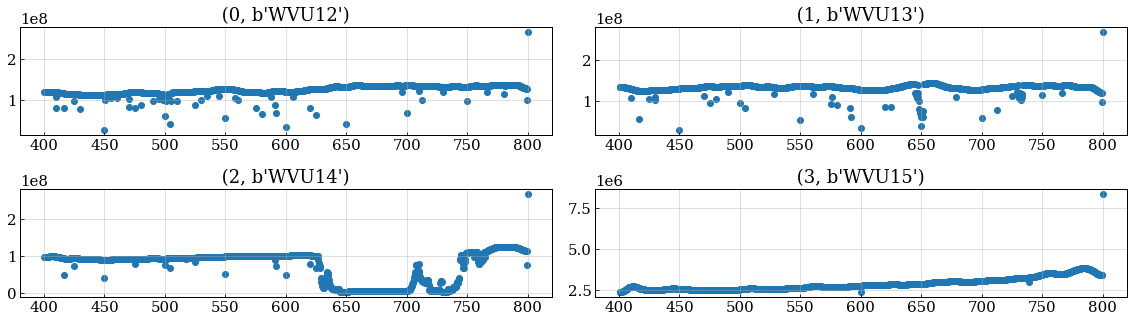

In [5]:
#Reading digital gains -- 
f = h5py.File("/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/digital_gains/20250412T191307Z_WVUc52_digitalgain/00000056.h5","r")

#Plotting digital gains -- 
print(list(f.attrs))
print(f.attrs['acquisition_name'])
print(f.attrs['archive_version'])
print(f.attrs['collection_server'])
print(f.attrs['git_version_tag'])
print(f.attrs['instrument_name'])
print(f.attrs['notes'])
print(f.attrs['system_user'])
print(f.attrs['type'])
print(f.attrs['version'])

print(list(f.items()))
print((f['compute_time']))
print((f['index_map']))
print((f['gain_coeff']))
print((f['gain_exp']))

inputs = (f['index_map']['input'][:])
frqs = f['index_map']['freq'][:]
gaincoeff = f['gain_coeff'][()]
gainexp = f['gain_exp'][()]
gain = gaincoeff.real*np.exp2(gainexp)

plt.figure(figsize=[16,18])
print(f"Calculating digital gains of the channels...")
i = 0
for i in np.arange(0,4,1):  
    plt.subplot(8,2,i+1)
    #Digital gain of every channel
    plt.scatter(frqs['centre'], gain[0][:,i]) # i referes to input channel (total 16 ch on iceboard); 
    #plt.title( " %s and gain_exp = %s and rms %s for rms i/p %s" %(inputs[i], gainexp[:,i], rms[i][2], rms[i][0][2]))
    plt.title( " %s " %(inputs[i]))
plt.tight_layout()

In [ ]:
"""Analysis of correlator data for correlation powers, waterfall and phase -- 
"""

In [49]:
## Reading correlation files -- 
file_path = '/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/*/*' 
corr_data = read_corr_mode_h5(file_path, f_start=61, f_stop=65) 
pow_mag, pow_phase = get_mag_phase(corr_data.vis)
print("done getting pow_mag and pow_phase")
sat_data = corr_data.sat.real

corr_size=corr_data.vis[:,:,:].shape 
print('corr data shape: {}'.format(corr_size)) # time bins - freq bins - corr indices

Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0061
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0061
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0062
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0062
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0063
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_ra

In [45]:
tmin,tmax=[0,corr_size[0]]
print(corr_data.vis.real.shape)
print(f"real power : {corr_data.vis.real[tmin:tmax,315,8]}")
print(f"imag power : {corr_data.vis.imag[tmin:tmax,315,8]}") 
print(f"abs power : {pow_mag[tmin:tmax,315,8]}")

(1024, 1024, 10)
real power : [0. 0. 0. ... 0. 0. 0.]
imag power : [0. 0. 0. ... 0. 0. 0.]
abs power : [0. 0. 0. ... 0. 0. 0.]


Each time bin is: 0.04194304 seconds
total time bins (considered for the plots) are 1024
lowest time bin 0 and highest time bin 1024
42.94967296 seconds of data (considered for the plots)


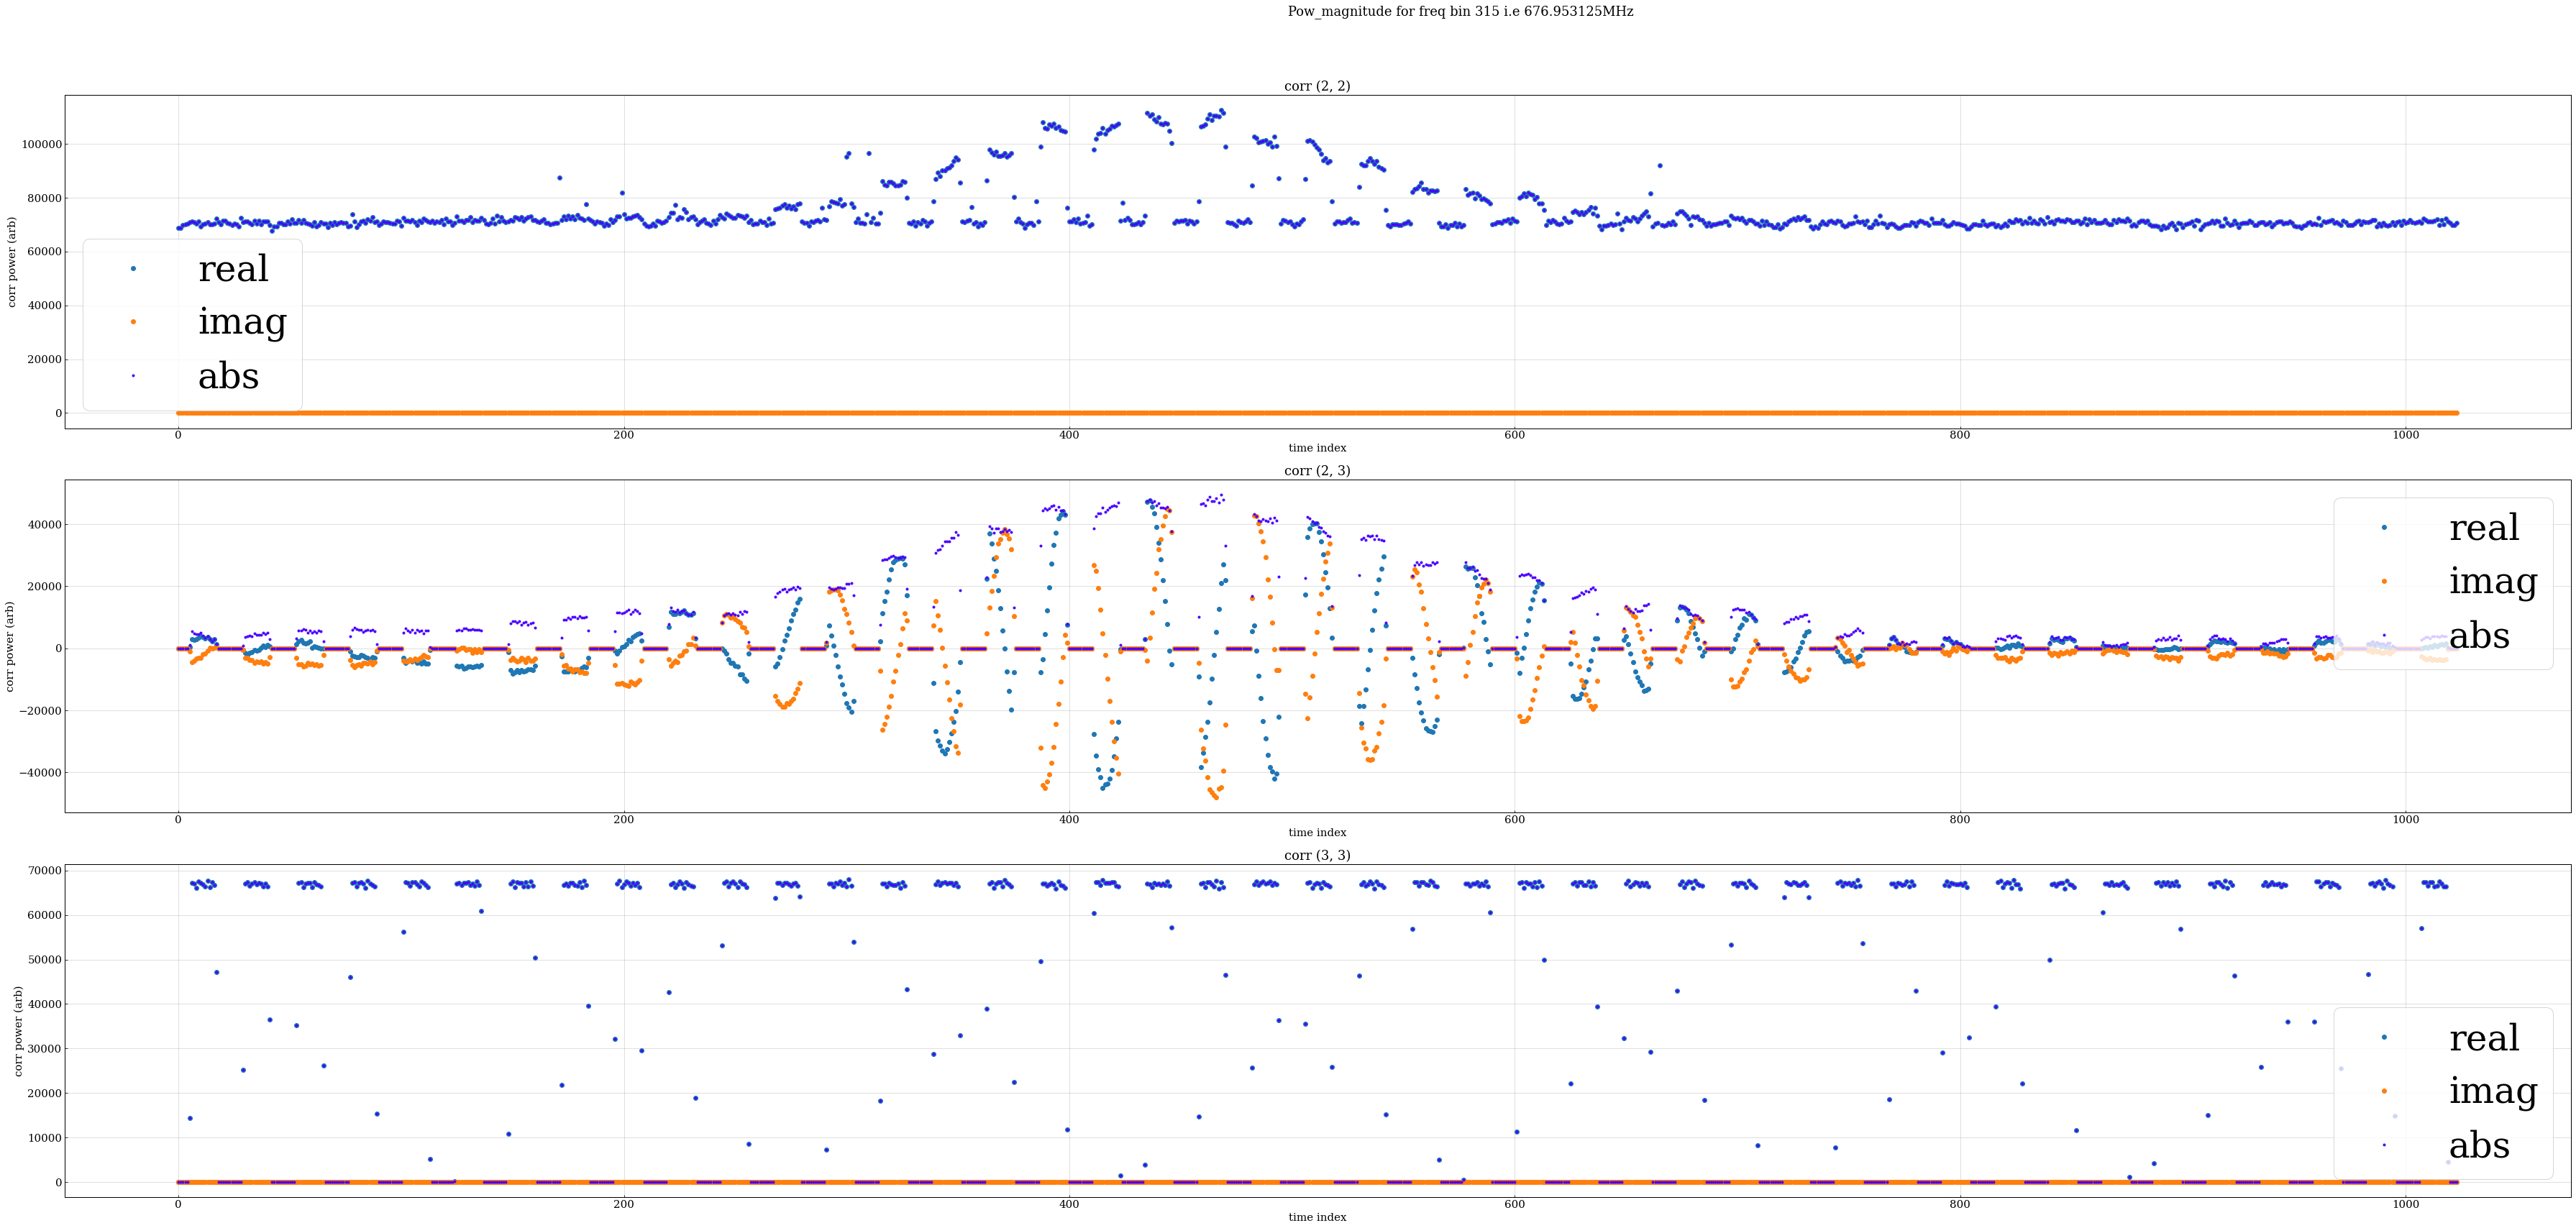

In [83]:
#Plotting real and imag correlation powers against time index for a given set of frequencies -- 
tmin,tmax=[0,corr_size[0]]
freq_arr=[315]
corr_indices=[7,8,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[50,25])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        ax.plot(corr_data.vis.real[tmin:tmax,f_ind,corr_index],'o', label='real')
        ax.plot(corr_data.vis.imag[tmin:tmax,f_ind,corr_index],'o', label='imag')
        ax.plot(pow_mag[tmin:tmax,f_ind,corr_index],'.', c=colorsarr[700], label='abs')
        #plt.xlim(500,600)
        #plt.ylim(0,10000)
        ax.legend(fontsize=50)
        plt.title(f"corr {corr_data.prod[corr_index]}")
        plt.xlabel("time index")
        plt.ylabel("corr power (arb)")
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/phase_offset_investigate/real_imag_corr_powers_1ms_files61-65.pdf")

delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9 
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_data.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 

In [64]:
## Metric -- Mean
## DC offset if non-zero 
print("For Co-Pol:")
print(np.mean(corr_data.vis.real[tmin:tmax,315,7]))
print(np.mean(corr_data.vis.imag[tmin:tmax,315,7]))


print("For Cross-Pol:")
print(np.mean(corr_data.vis.real[tmin:tmax,315,8]))
print(np.mean(corr_data.vis.imag[tmin:tmax,315,8]))

print("For Ref:")
print(np.mean(corr_data.vis.real[tmin:tmax,315,9]))
print(np.mean(corr_data.vis.imag[tmin:tmax,315,9]))

Metric used -- Mean
For Co-Pol:
74893.5322265625
0.0
For Cross-Pol:
224.53125
-1229.3671875
For Ref:
33506.7412109375
0.0


In [75]:
## Metric -- Variance 
## Gain imbalence if unequal 
print("For Co-Pol channel:")
print(np.var(corr_data.vis.real[tmin:tmax,315,7]))
print(np.var(corr_data.vis.imag[tmin:tmax,315,7]))

print("For Cross-Pol channel:")
print(np.var(corr_data.vis.real[tmin:tmax,315,8]))
print(np.var(corr_data.vis.imag[tmin:tmax,315,8]))
print(f"Difference in variance of real and imaginary part is: {np.var(corr_data.vis.real[tmin:tmax,315,8])-np.var(corr_data.vis.imag[tmin:tmax,315,8])}")

print("For Ref channel:")
print(np.var(corr_data.vis.real[tmin:tmax,315,9]))
print(np.var(corr_data.vis.imag[tmin:tmax,315,9]))

Metric used -- Variance
For Co-Pol channel:
90865726.43255518
0.0
For Cross-Pol channel:
116955000.69042969
115748707.11126709
Difference in variance of real and imaginary part is: 1206293.5791625977
For Ref channel:
1056303378.4672074
0.0


complex128


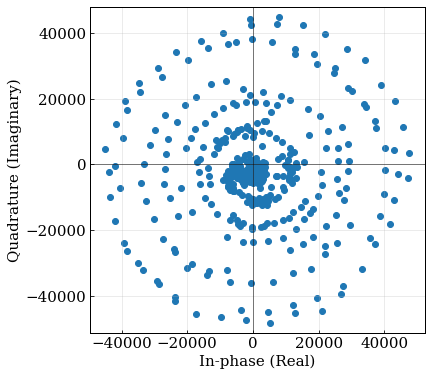

In [111]:
## Metric -- constellation plot 
## Phase skew would distort circle to ellipse? 
## data type is complex128
print(corr_data.vis.dtype)
plt.figure(figsize=(6,6))
plt.scatter(corr_data.vis.real[tmin:tmax,315,8], corr_data.vis.imag[tmin:tmax,315,8])

plt.axhline(0, color='k', lw=0.5); 
plt.axvline(0, color='k', lw=0.5)
plt.xlabel('In-phase (Real)'); 
plt.ylabel('Quadrature (Imaginary)')
plt.grid(True, alpha=0.3); 
plt.axis('equal')
plt.savefig("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/phase_offset_investigate/constellation_1ms_files61-65.pdf")
plt.show()


In [121]:
# removing phase rotation (mean phasor)
phi=np.angle(np.mean(corr_data.vis[tmin:tmax,315,8]))
corr_dat_rot= corr_data.vis[tmin:tmax,315,8] * np.exp(-1j * phi)

mean_I=np.mean(corr_dat_rot.real)
mean_Q=np.mean(corr_dat_rot.imag)
var_I=np.var(corr_dat_rot.real)
var_Q=np.var(corr_dat_rot.imag)

print(mean_I, mean_Q)
print(f"Indicates DC offset in I component whereas dc offset on Q-comp is essentially zero.")
print(f"Needs correction to I-comp" )
print(var_I, var_Q)
print(f"Variances are very close -- diff of ~2.7% indicating gain imbalance between I and Q is small")


1249.7031503233968 1.7053025658242404e-13
Indicates DC offset in I component whereas dc offset on Q-comp is essentially zero.
Needs correction to I-comp
114780322.67749217 117923385.1242046
Variances are very close -- diff of ~2.7% indicating gain imbalance between I and Q is small


In [114]:
# checking if systematic phase offset exists between real and imag
iq_corr =np.corrcoef(corr_data.vis.real[tmin:tmax,315,8], corr_data.vis.imag[tmin:tmax,315,8])[0,1]
iq_corr
print("this is really small -- tiny residual corr")

0.0244921606480071

In [125]:
corr_data_dc_IQ_corr=(corr_data.vis.real[tmin:tmax,315,8] - np.mean(corr_data.vis.real[tmin:tmax,315,8])) + 1j*(corr_data.vis.imag[tmin:tmax,315,8] - np.mean(corr_data.vis.imag[tmin:tmax,315,8]))

mean_I=np.mean(corr_data_dc_IQ_corr.real)
mean_Q=np.mean(corr_data_dc_IQ_corr.imag)
print(mean_I, mean_Q)

0.0 0.0


complex128


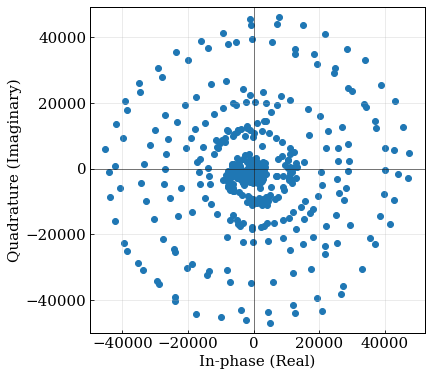

In [128]:
## Metric -- constellation plot after DC offset correction 
## Phase skew would distort circle to ellipse? 
## data type is complex128
print(corr_data.vis.dtype)
plt.figure(figsize=(6,6))
plt.scatter(corr_data_dc_IQ_corr.real, corr_data_dc_IQ_corr.imag)

plt.axhline(0, color='k', lw=0.5); 
plt.axvline(0, color='k', lw=0.5)
plt.xlabel('In-phase (Real)'); 
plt.ylabel('Quadrature (Imaginary)')
plt.grid(True, alpha=0.3); 
plt.axis('equal')
plt.savefig("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/phase_offset_investigate/constellation_1ms_files61-65.pdf")
plt.show()

Each time bin is: 0.04194304 seconds
total time bins (considered for the plots) are 1024
lowest time bin 0 and highest time bin 1024
42.94967296 seconds of data (considered for the plots)


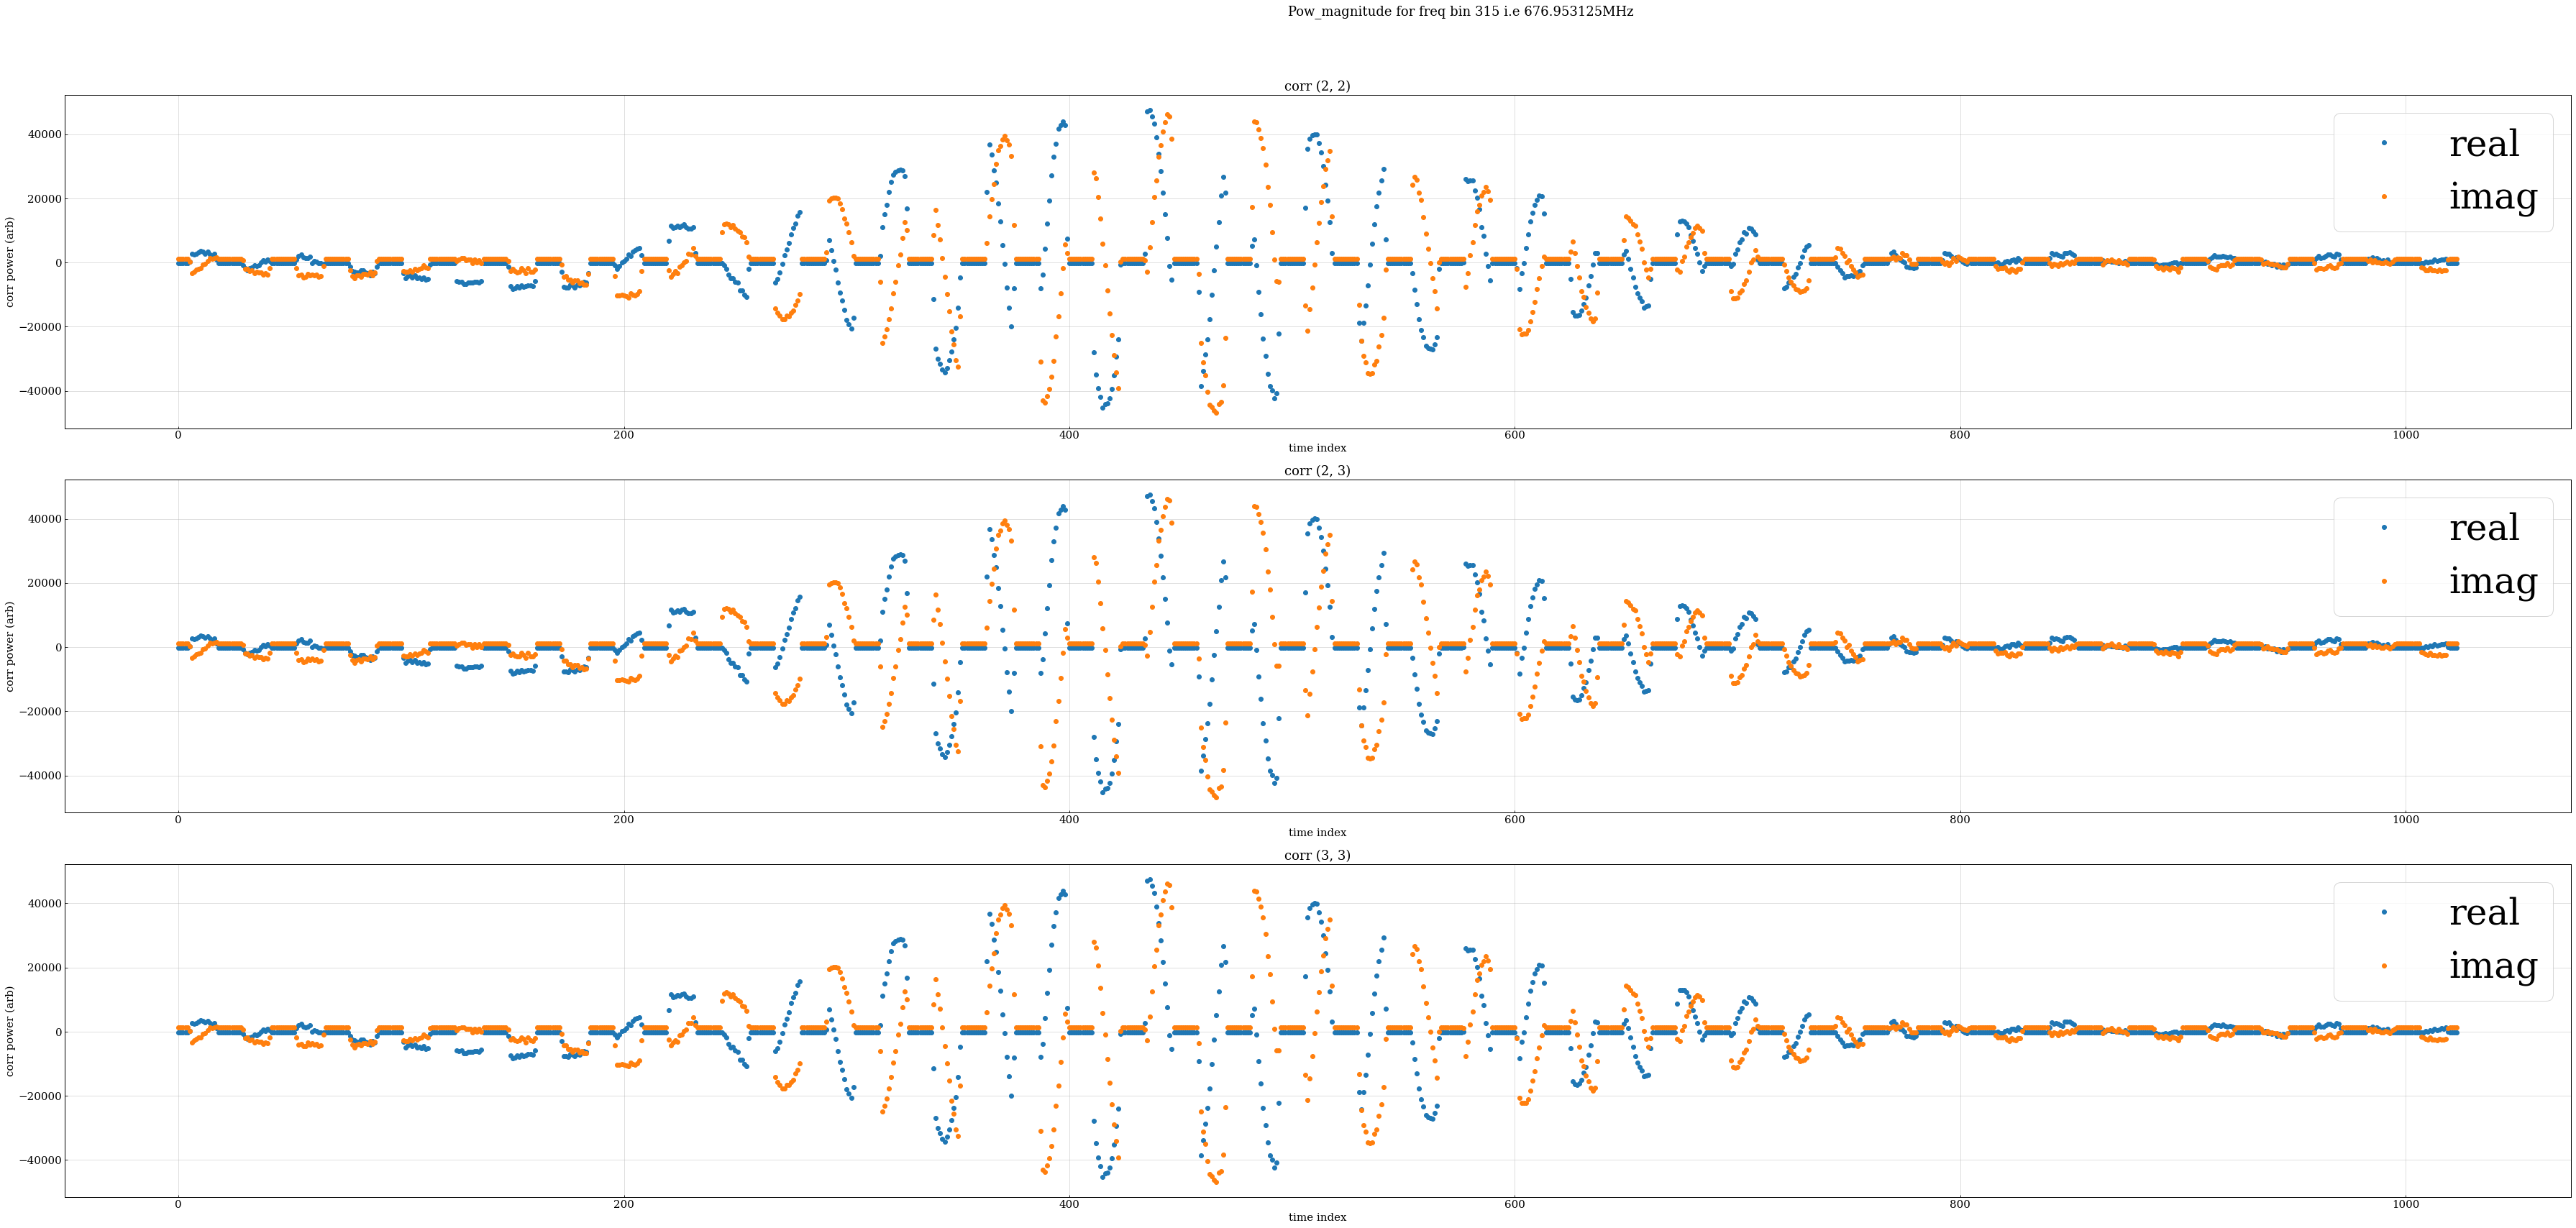

In [129]:
#Plotting real and imag correlation powers against time index for a given set of frequencies -- 
tmin,tmax=[0,corr_size[0]]
freq_arr=[315]
corr_indices=[7,8,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[50,25])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        ax.plot(corr_data_dc_IQ_corr.real,'o', label='real')
        ax.plot(corr_data_dc_IQ_corr.imag,'o', label='imag')
        #ax.plot(np.abs(corr_data_dc_IQ_corr),'.', c=colorsarr[700], label='abs')
        #plt.xlim(500,600)
        #plt.ylim(0,10000)
        ax.legend(fontsize=50)
        plt.title(f"corr {corr_data.prod[corr_index]}")
        plt.xlabel("time index")
        plt.ylabel("corr power (arb)")
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/phase_offset_investigate/real_imag_corr_powers_1ms_files61-65.pdf")

delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9 
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_data.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 

In [ ]:
### Plotting correlation powers against time index for a given set of frequencies -- 
tmin,tmax=[0,corr_size[0]]
freq_arr=[315,335]
corr_indices=[7,8,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[50,25])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        #ax=plt.subplots(dim2, dim1, layout="constrained")
        ax.plot(corr_data.vis.real[tmin:tmax,f_ind,corr_index],'.', c='red', label='real')
        ax.plot(corr_data.vis.imag[tmin:tmax,f_ind,corr_index],'.', c='green', label='imag')
        #ax.plot(pow_mag[tmin:tmax,f_ind,corr_index],'.', c=colorsarr[700], label='abs')
        #plt.axvline(1550, color='r', linestyle='--', linewidth=2)
        #plt.axhline(131000)
        #plt.xlim(500,600)
        #plt.ylim(0,10000)
        plt.title(f"corr {corr_data.prod[corr_index]}")
        plt.xlabel("time index")
        plt.ylabel("corr power (arb)")
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9 
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_data.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 

In [ ]:
"""
    Plotting correlation powers against time index for a given set of frequencies 
    (in log scale - without considering beam**2 factor in autos and beam for crosses) --
""" 

tmin,tmax=[0,corr_size[0]]
#tmin,tmax=[250,500]
freq_arr=[376,393,470,480]
corr_indices=[0,3,4,6,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[50,25])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        #ax.semilogy(pow_mag.real[tmin:tmax,f_ind,corr_index],'.', c=colorsarr[f_ind])
        ax.semilogy(pow_mag[tmin:tmax,f_ind,corr_index],'.', c=colorsarr[1500])
        #plt.axvline(1550, color='r', linestyle='--', linewidth=2)
        #plt.axhline(131000)
        #plt.xlim(500,600)
        #plt.ylim(0,10000)
        plt.title(f"corr {corr_data.prod[corr_index]}")
        plt.xlabel("time index")
        plt.ylabel("corr power (log)")
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9 
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_data.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 

In [ ]:
#Plotting waterfall --
#corr_indices=[0,4,7,9] # autos indices
#corr_indices=[3,6,8] #crosses indices
corr_indices = [7,8,9]
plot_waterfall_corr_data(pow_mag[:,:,:],corr_indices)

In [ ]:
#Phase for a set of time index as a function of frequency:
t_ind_arr= [1500,1510,1530,1540]
#corr_indices=[0,3,4,6,7,8,9]
corr_indices=[6]
plot_phase_corr_data(pow_phase[:,:512,:], corr_indices, t_ind_arr)

In [ ]:
#Phase for a set of time index as a function of frequency:
t_ind_arr= [2410,2420,2430,2440,2450]
#corr_indices=[0,3,4,6,7,8,9]
corr_indices=[8]
plot_phase_corr_data(pow_phase[:,:512,:], corr_indices, t_ind_arr)

In [ ]:
# plotting single time bin across the 400-800MHz band 

colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
plt.figure(figsize=[15,20])
k=0
tb_on=520
tb_off=535

#freq_arr=[468,470,478,480]
freq_arr=[470,480]
plt.subplot(6,1,1)
plt.plot(pow_mag[tb_on,:,0], c=colorsarr[k]) 
plt.plot(pow_mag[tb_off,:,0], c=colorsarr[k+500])
plt.xlim(300,500)
plt.title("time bin {} -- 0x0".format(tb_on))
plt.xlabel('frequency index')
plt.ylabel('corr powers (arb)')
for freq in freq_arr:
    plt.axvline(x=freq, color='r', linestyle='--', label=f"freq = {freq}")
plt.axhline(75000, color='g', linestyle='--', linewidth=2, label='75000')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

plt.subplot(6,1,2)
plt.plot(pow_mag[tb_on,:,4], c=colorsarr[k]) 
plt.plot(pow_mag[tb_off,:,4], c=colorsarr[k+500])
plt.xlim(200,500)
plt.ylim(70000,109000)
plt.title("time bin {}-- 1x1".format(tb_on))
plt.xlabel('frequency index')
plt.ylabel('corr powers (arb)')
for freq in freq_arr:
    plt.axvline(x=freq, color='r', linestyle='--', label=f"freq = {freq}")
plt.axhline(75000, color='g', linestyle='--', linewidth=2, label='75000')
#plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

plt.subplot(6,1,3)
plt.plot(pow_mag[tb_on,:,4], c=colorsarr[k])
plt.plot(pow_mag[tb_off,:,4], c=colorsarr[k+500])
#plt.xlim(0,500)
plt.title("time bin {} -- 1x1".format(tb_on))
plt.xlabel('frequency index')
plt.ylabel('corr powers (arb)')
for freq in freq_arr:
    plt.axvline(x=freq, color='r', linestyle='--', label=f"freq = {freq}")
#plt.axhline(50000, color='r', linestyle='--', linewidth=2, label='50000')
plt.axhline(75000, color='g', linestyle='--', linewidth=2, label='75000')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

plt.subplot(6,1,4)
plt.plot(pow_mag[tb_on,:,7], c=colorsarr[k])
plt.plot(pow_mag[tb_off,:,7], c=colorsarr[k+500])
#plt.xlim(200,400)
plt.title("time bin {} -- 2x2".format(tb_on))
plt.xlabel('frequency index')
plt.ylabel('corr powers (arb)')
for freq in freq_arr:
    plt.axvline(x=freq, color='r', linestyle='--', label=f"freq = {freq}")
#plt.axhline(50000, color='r', linestyle='--', linewidth=2, label='50000')
plt.axhline(75000, color='g', linestyle='--', linewidth=2, label='75000')
#plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

plt.subplot(6,1,5)
plt.plot(pow_mag[tb_on,:,8], c=colorsarr[k])
plt.plot(pow_mag[tb_off,:,8], c=colorsarr[k+500])
#plt.xlim(0,200)
plt.title("time bin {} -- 2x3".format(tb_on))
plt.xlabel('frequency index')
plt.ylabel('corr powers (arb)')
for freq in freq_arr:
    plt.axvline(x=freq, color='r', linestyle='--', label=f"freq = {freq}")
plt.axhline(70000, color='g', linestyle='--', linewidth=2, label='70000')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.subplot(6,1,6)
plt.plot(pow_mag[tb_on,:,9], c=colorsarr[k])
plt.plot(pow_mag[tb_off,:,9], c=colorsarr[k+500])
#plt.xlim(200,400)
plt.title("time bin {} -- 3x3".format(tb_on))
plt.xlabel('frequency index')
plt.ylabel('corr powers (arb)')
for freq in freq_arr:
    plt.axvline(x=freq, color='r', linestyle='--', label=f"freq = {freq}")
plt.axhline(70000, color='r', linestyle='--', linewidth=2, label='70000')
#plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.suptitle(f"freq_dependence of single time bin")
plt.tight_layout() 

In [ ]:
#What's the frequency corresponding to the given frequency index?
f_ind=484
print(f"Frequency corresponding to frequency index {f_ind} is {400+((1024-f_ind)*0.390625)}MHz")

In [ ]:
#What's the frequency index corresponding to the given frequency?
freq= 900 #in MHz 
print(f"Frequency index corresponding to given frequency {freq} MHz is {1024-((freq-400)/0.390625)}")

### Saving Statistics  ###

In [ ]:

## -- correlator data 
# reading the required only corr files for plotting beam pattern
file_path = '/Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/*/*'

# reading files for 0 degrees angle between rx and tx
corr_data0 = read_corr_mode_h5(file_path, f_start=400, f_stop=181)
pow_mag0, pow_phase0 = get_mag_phase(corr_data0.vis)
# reading files for negative 5 degrees angle between rx and tx
corr_data5n = read_corr_mode_h5(file_path, f_start=179, f_stop=180)
pow_mag5n, pow_phase5n = get_mag_phase(corr_data5n.vis)
# reading files for negative 10 degrees angle between rx and tx
corr_data10n = read_corr_mode_h5(file_path, f_start=178, f_stop=179)
pow_mag10n, pow_phase10n = get_mag_phase(corr_data10n.vis)
# reading files for negative 15 degrees angle between rx and tx
corr_data15n = read_corr_mode_h5(file_path, f_start=177, f_stop=178)
pow_mag15n, pow_phase15n = get_mag_phase(corr_data15n.vis)
# reading files for negative 20 degrees angle between rx and tx
corr_data20n = read_corr_mode_h5(file_path, f_start=176, f_stop=177)
pow_mag20n, pow_phase20n = get_mag_phase(corr_data20n.vis)
# reading files for negative 25 degrees angle between rx and tx
corr_data25n = read_corr_mode_h5(file_path, f_start=175, f_stop=176)
pow_mag25n, pow_phase25n = get_mag_phase(corr_data25n.vis)
# reading files for negative 30 degrees angle between rx and tx
corr_data30n = read_corr_mode_h5(file_path, f_start=174, f_stop=175)
pow_mag30n, pow_phase30n = get_mag_phase(corr_data30n.vis)
# reading files for negative 35 degrees angle between rx and tx
corr_data35n = read_corr_mode_h5(file_path, f_start=173, f_stop=174)
pow_mag35n, pow_phase35n = get_mag_phase(corr_data35n.vis)
# reading files for negative 40 degrees angle between rx and tx
corr_data40n = read_corr_mode_h5(file_path, f_start=172, f_stop=173)
pow_mag40n, pow_phase40n = get_mag_phase(corr_data40n.vis)
# reading files for negative 45 degrees angle between rx and tx
corr_data45n = read_corr_mode_h5(file_path, f_start=171, f_stop=172)
pow_mag45n, pow_phase45n = get_mag_phase(corr_data45n.vis)
# reading files for negative 50 degrees angle between rx and tx
corr_data50n = read_corr_mode_h5(file_path, f_start=170, f_stop=171)
pow_mag50n, pow_phase50n = get_mag_phase(corr_data50n.vis)
# reading files for negative 55 degrees angle between rx and tx
corr_data55n = read_corr_mode_h5(file_path, f_start=169, f_stop=170)
pow_mag55n, pow_phase55n = get_mag_phase(corr_data55n.vis)
# reading files for negative 60 degrees angle between rx and tx
corr_data60n = read_corr_mode_h5(file_path, f_start=168, f_stop=169)
pow_mag60n, pow_phase60n = get_mag_phase(corr_data60n.vis)
# reading files for negative 65 degrees angle between rx and tx
corr_data65n = read_corr_mode_h5(file_path, f_start=167, f_stop=168)
pow_mag65n, pow_phase65n = get_mag_phase(corr_data65n.vis)
# reading files for negative 70 degrees angle between rx and tx
corr_data70n = read_corr_mode_h5(file_path, f_start=166, f_stop=167)
pow_mag70n, pow_phase70n = get_mag_phase(corr_data70n.vis)
# reading files for negative 75 degrees angle between rx and tx
corr_data75n = read_corr_mode_h5(file_path, f_start=165, f_stop=166)
pow_mag75n, pow_phase75n = get_mag_phase(corr_data75n.vis)
# reading files for negative 80 degrees angle between rx and tx 
corr_data80n = read_corr_mode_h5(file_path, f_start=164, f_stop=165)
pow_mag80n, pow_phase80n = get_mag_phase(corr_data80n.vis)
# reading files for negative 85 degrees angle between rx and tx 
corr_data85n = read_corr_mode_h5(file_path, f_start=163, f_stop=164)
pow_mag85n, pow_phase85n = get_mag_phase(corr_data85n.vis)
# reading files for negative 90 degrees angle between rx and tx 
corr_data90n = read_corr_mode_h5(file_path, f_start=162, f_stop=163)
pow_mag90n, pow_phase90n = get_mag_phase(corr_data90n.vis)
# reading files for negative 95 degrees angle between rx and tx 
corr_data95n = read_corr_mode_h5(file_path, f_start=161, f_stop=162)
pow_mag95n, pow_phase95n = get_mag_phase(corr_data95n.vis)
# reading files for negative 100 degrees angle between rx and tx 
corr_data100n = read_corr_mode_h5(file_path, f_start=160, f_stop=161)
pow_mag100n, pow_phase100n = get_mag_phase(corr_data100n.vis)
# reading files for negative 105 degrees angle between rx and tx 
#corr_data105n = read_corr_mode_h5(file_path, f_start=78, f_stop=79)
#pow_mag105n, pow_phase105n = get_mag_phase(corr_data105n.vis)
# reading files for negative 110 degrees angle between rx and tx 
#corr_data110n = read_corr_mode_h5(file_path, f_start=77, f_stop=78)
#pow_mag110n, pow_phase110n = get_mag_phase(corr_data110n.vis)
# reading files for negative 115 degrees angle between rx and tx 
#corr_data115n = read_corr_mode_h5(file_path, f_start=76, f_stop=77)
#pow_mag115n, pow_phase115n = get_mag_phase(corr_data115n.vis)
# reading files for negative 120 degrees angle between rx and tx 
#corr_data120n = read_corr_mode_h5(file_path, f_start=75, f_stop=76)
#pow_mag120n, pow_phase120n = get_mag_phase(corr_data120n.vis)
# reading files for negative 125 degrees angle between rx and tx 
#corr_data125n = read_corr_mode_h5(file_path, f_start=74, f_stop=75)
#pow_mag125n, pow_phase125n = get_mag_phase(corr_data125n.vis)
# reading files for negative 130 degrees angle between rx and tx 
#corr_data130n = read_corr_mode_h5(file_path, f_start=73, f_stop=74)
#pow_mag130n, pow_phase130n = get_mag_phase(corr_data130n.vis)
# reading files for negative 135 degrees angle between rx and tx 
#corr_data135n = read_corr_mode_h5(file_path, f_start=72, f_stop=73)
#pow_mag135n, pow_phase135n = get_mag_phase(corr_data135n.vis)

# reading files for positive 5 degrees angle between rx and tx
corr_data5p = read_corr_mode_h5(file_path, f_start=181, f_stop=182)
pow_mag5p, pow_phase5p = get_mag_phase(corr_data5p.vis)
# reading files for positive 10 degrees angle between rx and tx
corr_data10p = read_corr_mode_h5(file_path, f_start=182, f_stop=183)
pow_mag10p, pow_phase10p = get_mag_phase(corr_data10p.vis)
# reading files for positive 15 degrees angle between rx and tx
corr_data15p = read_corr_mode_h5(file_path, f_start=183, f_stop=184)
pow_mag15p, pow_phase15p = get_mag_phase(corr_data15p.vis)
# reading files for positive 20 degrees angle between rx and tx 
corr_data20p = read_corr_mode_h5(file_path, f_start=184, f_stop=185)
pow_mag20p, pow_phase20p = get_mag_phase(corr_data20p.vis)
# reading files for positive 25 degrees angle between rx and tx 
corr_data25p = read_corr_mode_h5(file_path, f_start=185, f_stop=186)
pow_mag25p, pow_phase25p = get_mag_phase(corr_data25p.vis)
# reading files for positive 30 degrees angle between rx and tx
corr_data30p = read_corr_mode_h5(file_path, f_start=186, f_stop=187)
pow_mag30p, pow_phase30p = get_mag_phase(corr_data30p.vis)
# reading files for positive 35 degrees angle between rx and tx
corr_data35p = read_corr_mode_h5(file_path, f_start=187, f_stop=188)
pow_mag35p, pow_phase35p = get_mag_phase(corr_data35p.vis)
# reading files for positive 40 degrees angle between rx and tx 
corr_data40p = read_corr_mode_h5(file_path, f_start=188, f_stop=189)
pow_mag40p, pow_phase40p = get_mag_phase(corr_data40p.vis)
# reading files for positive 45 degrees angle between rx and tx 
corr_data45p = read_corr_mode_h5(file_path, f_start=189, f_stop=190)
pow_mag45p, pow_phase45p = get_mag_phase(corr_data45p.vis)
# reading files for positive 50 degrees angle between rx and tx
corr_data50p = read_corr_mode_h5(file_path, f_start=190, f_stop=191)
pow_mag50p, pow_phase50p = get_mag_phase(corr_data50p.vis)
# reading files for positive 55 degrees angle between rx and tx
corr_data55p = read_corr_mode_h5(file_path, f_start=191, f_stop=192)
pow_mag55p, pow_phase55p = get_mag_phase(corr_data55p.vis)
# reading files for positive 60 degrees angle between rx and tx 
corr_data60p = read_corr_mode_h5(file_path, f_start=192, f_stop=193)
pow_mag60p, pow_phase60p = get_mag_phase(corr_data60p.vis)
# reading files for positive 65 degrees angle between rx and tx 
corr_data65p = read_corr_mode_h5(file_path, f_start=193, f_stop=194)
pow_mag65p, pow_phase65p = get_mag_phase(corr_data65p.vis)
# reading files for positive 70 degrees angle between rx and tx
corr_data70p = read_corr_mode_h5(file_path, f_start=194, f_stop=195)
pow_mag70p, pow_phase70p = get_mag_phase(corr_data70p.vis)
# reading files for positive 75 degrees angle between rx and tx
corr_data75p = read_corr_mode_h5(file_path, f_start=195, f_stop=196)
pow_mag75p, pow_phase75p = get_mag_phase(corr_data75p.vis)
# reading files for positive 80 degrees angle between rx and tx 
corr_data80p = read_corr_mode_h5(file_path, f_start=196, f_stop=197)
pow_mag80p, pow_phase80p = get_mag_phase(corr_data80p.vis)
# reading files for positive 85 degrees angle between rx and tx 
corr_data85p = read_corr_mode_h5(file_path, f_start=197, f_stop=198)
pow_mag85p, pow_phase85p = get_mag_phase(corr_data85p.vis)
# reading files for positive 90 degrees angle between rx and tx 
corr_data90p = read_corr_mode_h5(file_path, f_start=198, f_stop=199)
pow_mag90p, pow_phase90p = get_mag_phase(corr_data90p.vis)
# reading files for positive 95 degrees angle between rx and tx 
corr_data95p = read_corr_mode_h5(file_path, f_start=199, f_stop=200)
pow_mag95p, pow_phase95p = get_mag_phase(corr_data95p.vis)
# reading files for positive 100 degrees angle between rx and tx 
corr_data100p = read_corr_mode_h5(file_path, f_start=200, f_stop=201)
pow_mag100p, pow_phase100p = get_mag_phase(corr_data100p.vis)
# reading files for positive 105 degrees angle between rx and tx 
#corr_data105p = read_corr_mode_h5(file_path, f_start=260, f_stop=263)
#pow_mag105p, pow_phase105p = get_mag_phase(corr_data105p.vis)
# reading files for positive 110 degrees angle between rx and tx 
#corr_data110p = read_corr_mode_h5(file_path, f_start=265, f_stop=268)
#pow_mag110p, pow_phase110p = get_mag_phase(corr_data110p.vis)
# reading files for positive 115 degrees angle between rx and tx 
#corr_data115p = read_corr_mode_h5(file_path, f_start=269, f_stop=272)
#pow_mag115p, pow_phase115p = get_mag_phase(corr_data115p.vis)
# reading files for positive 120 degrees angle between rx and tx 
#corr_data120p = read_corr_mode_h5(file_path, f_start=274, f_stop=277)
#pow_mag120p, pow_phase120p = get_mag_phase(corr_data120p.vis)
# reading files for positive 125 degrees angle between rx and tx 
#corr_data125p = read_corr_mode_h5(file_path, f_start=279, f_stop=282)
#pow_mag125p, pow_phase125p = get_mag_phase(corr_data125p.vis)
# reading files for positive 130 degrees angle between rx and tx 
#corr_data130p = read_corr_mode_h5(file_path, f_start=284, f_stop=287)
#pow_mag130p, pow_phase130p = get_mag_phase(corr_data130p.vis)
# reading files for positive 135 degrees angle between rx and tx 
#corr_data135p = read_corr_mode_h5(file_path, f_start=289, f_stop=292)
#pow_mag135p, pow_phase135p = get_mag_phase(corr_data135p.vis)

print("getting autocorrelation magnitudes and phase")
print("done getting pow_mag and pow_phase")

In [ ]:
"""
    WTyndall's function imported for fitting ON and OFF pulse points 
    and modified for computing stats for individual pulses - 41.9ms time bin
"""

def Extract_Source_Pulses(self,f_ind):
    #If we don't have any variables, then we haven't loaded a yaml yet... and must run the function:
        pow_mag, pow_phase = get_mag_phase(self.vis)
        Period=0.9998e6
        Dutycycle=0.5e6
        t_bounds=[0,-1]
        minmaxpercents=[0.0001,100]
        #Create Switch Signal:
        self.pulse_period=Period
        self.pulse_dutycycle=Dutycycle
        delta_time = np.diff(self.time["irigb_time"])[1]*1e-9
        concat_duration=int(np.ceil(delta_time*len((self.vis)))) #actual full time in seconds
        time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
        #Create t_offset range (1 period) and Pearson_r vars:
        t_offset_dist=np.arange(-1.0*self.pulse_period*1e-6,0.0,0.001)# 1ms steps 
        #n_channels = 10
        n_channels = 3
        #channel_indices = [0,1,2,3,4,5,6,7,8,9]
        channel_indices = [7,8,9]
        Pr_arr=np.NaN*np.ones((n_channels,t_offset_dist.shape[0]))
        Pr_max_ind_per_channel=np.NaN*np.ones(n_channels) 
        Pr_max_t_0_per_channel=np.NaN*np.ones(n_channels)
        #Given parameters:
        num_bins = len(pow_mag[:,f_ind,9])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_full = np.arange(num_bins) * time_bin_width

    
        ## Loop over channels to find/plot a time offset solution with some clever fitting:
        fig1,ax1=plt.subplots(nrows=1,ncols=1,figsize=(16,4))
        
        for i, ch_index in enumerate(channel_indices):
            ## Finding a baseline power level that’s almost the minimum, subtract it from the signal 
            ## so that ‘background’ power becomes zero before normalization.”
            minsubdata=self.vis[:,f_ind,ch_index]-np.percentile(self.vis[:,f_ind,ch_index],minmaxpercents[0])
            ## make all channels have the same range (0–1), so the Pearson correlation step later isn’t skewed by power differences.
            normminsubdata=minsubdata/np.percentile(minsubdata,minmaxpercents[1])
            ## clipping ensures baseline stays at 0 and maximum stays at 1 
            ## makes it directly comparable to our ideal square wave (0 = OFF, 1 = ON) 
            ## so Pearson correlation can find the best alignment.
            clipnormminsubdata=normminsubdata.clip(0,1)
            ## turns your cleaned signal into a function you can call at any time point,
            ## holding each sample’s value until the next one, so you can match it directly 
            ## to the ideal pulse pattern.
            stepped_func=interpolate.interp1d(t_full,clipnormminsubdata,kind='previous',fill_value='extrapolate')
            
            sniparr=np.where(time_s[np.where(time_s<=t_full[t_bounds[1]])[0]]>=t_full[t_bounds[0]])[0]
            t_restrict=np.intersect1d(np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],sniparr)

            ##Loop over all time offsets in t_offset_dist to find maximum correlation between squarewave and data:
            for j,t_offset in enumerate(t_offset_dist):
                shiftedswitch=np.interp(time_s,time_s+t_offset,switch)
                try:
                    Pr_arr[i,j]=pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]))[0]
                except ValueError:
                    Pr_arr[i,j]=np.NAN
                    print(str(j)+" failed: " +str(t_offset))
            
            ax1.plot(t_offset_dist,Pr_arr[i,:],'*',label=str(i))
           
            try:
                maxPrind=np.where(Pr_arr[i,:]==np.nanmax(Pr_arr[i,:]))[0][0]
                
                ax1.plot(t_offset_dist[maxPrind],Pr_arr[i,maxPrind],'ro')

                
                Pr_max_ind_per_channel[i]=maxPrind
                Pr_max_t_0_per_channel[i]=t_offset_dist[maxPrind]
            except IndexError:
                Pr_max_ind_per_channel[i]=np.NAN
                Pr_max_t_0_per_channel[i]=np.NAN
                
        # Always considering reference channel for fitting (time offset from ref) as anyways switching is in sync 
        # Always point this index to the ref channel 
        self.t_delta_pulse=Pr_max_t_0_per_channel[9]  
        #self.t_delta_pulse=Pr_max_t_0_per_channel[0]  
        ax1.axvline(self.t_delta_pulse,label="selected t_offset")
        ax1.legend(loc=1)
        plt.tight_layout()
        print("Maximum Pearson_R Correlations between data and square wave function:")
        print("  --> t_indices = {}".format(Pr_max_ind_per_channel))
        print("  --> t_deltas = {}".format(np.around(Pr_max_t_0_per_channel,decimals=3)))
        print("Selecting square wave function time offset:")
        print("  --> t_delta_pulse = {:.10f}".format(self.t_delta_pulse))

        
        
        t_arr_datetime = t_full 
        #Interpolate the switching function with the concat timestamps using either input or found t_delta_pulse:
        num_bins = len(pow_mag[:,f_ind,1])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_for_interp_out=np.arange(num_bins) * time_bin_width #defining same as t_full
        t_for_interp_in=np.array([m.total_seconds() for m in time_dt])
        switch_interp_f=np.interp(t_for_interp_out,t_for_interp_in+self.t_delta_pulse,switch)
        self.switch_signal=switch
        self.switch_time=t_for_interp_in
        self.switch_signal_interp=switch_interp_f
        #print(switch_interp_f)
        
        #Once we have our time offset, we must extract indices where the source is on/off/rising:
        self.inds_span=np.union1d(list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),\
                                  np.intersect1d(np.where(1>switch_interp_f),np.where(switch_interp_f>0))).tolist()
        self.inds_on=list(set(np.where(switch_interp_f==1)[0])-set(self.inds_span))
        self.inds_off=list(set(np.where(switch_interp_f==0)[0])-set(self.inds_span))
 
        ## Each of these lists of indices should also have no overlap. Let's print to see:
        print("Finding relevant pulsing indices and checking for overlaps:")
        print("  --> on/off ind intersection:",np.intersect1d(self.inds_on,self.inds_off))
        print("  --> on/span ind intersection:",np.intersect1d(self.inds_on,self.inds_span))
        print("  --> off/span ind intersection:",np.intersect1d(self.inds_off,self.inds_span))

        #Making subsets of on and off indices for individual ON/OFFs: 
        indon_list=list(chunk_lists_(self.inds_on))
        indoff_list=list(chunk_lists_(self.inds_off))
        #Calculating stats for individual ON/OFF pulses:
        channel_indices = [0,1,2,3,4,5,6,7,8,9]
        #channel_indices = [7,8,9]
        on_avgs=[]
        off_avgs=[]
        on_med=[]
        off_med=[]
        on_stds=[]
        on_iqr=[]
        on_var=[]
        off_var=[]
        
        
        fig3=plt.figure(figsize=(16,int(4*n_channels/2)))
        for i,channel_index in enumerate(channel_indices):
            
            all_data = pow_mag[:,f_ind,channel_index]
            avgs_on_i=[]
            avgs_off_i=[]
            med_on_i=[]
            med_off_i=[]
            stds_on_i=[]
            iqr_on_i=[]
            var_on_i=[]
            var_off_i=[]
            for on_list in indon_list:
                avgs_on_i.append(np.nanmean(all_data[on_list]))
                med_on_i.append(np.nanmedian(all_data[on_list]))
                stds_on_i.append(np.nanstd(all_data[on_list]))
                iqr_on_i.append(iqr(all_data[on_list]))
                var_on_i.append(np.nanvar(all_data[on_list]))
            for off_list in indoff_list:
                avgs_off_i.append(np.nanmean(all_data[off_list])) 
                med_off_i.append(np.nanmedian(all_data[off_list]))
                var_off_i.append(np.nanvar(all_data[off_list]))
                
            on_avgs.append(avgs_on_i)
            off_avgs.append(avgs_off_i)
            on_med.append(med_on_i) #newly added -- less influence by outliers than mean 
            off_med.append(med_off_i) #newly added -- less influence by outliers than mean
            on_stds.append(stds_on_i)
            on_iqr.append(iqr_on_i) #newly added -- less influenced by outliers than std dev
            on_var.append(var_on_i)
            off_var.append(var_off_i)

            
            ax=fig3.add_subplot(n_channels,1,i+1)
            ax.plot(t_arr_datetime[:],pow_mag[:,f_ind,channel_index],label='data')
            ax.scatter(t_arr_datetime[self.inds_on],all_data[self.inds_on],label='on',color='red',s=10)
            ax.scatter(t_arr_datetime[self.inds_off],all_data[self.inds_off],label='off',color='green',s=10)
            ax.scatter(t_arr_datetime[self.inds_span],all_data[self.inds_span],label='span',color='blue',s=10)
            ax.set_ylabel("Log Power Received [$ADU^2$]")
            ax.set_xlabel("Datetime")
            ax.legend(loc=3)
            #ax.set_xlim(t_arr_datetime[t_bounds[0]],t_arr_datetime[t_bounds[1]])
            
        # Visualize alignment of switch_interp_f with actual data
        fig_align, ax_align = plt.subplots(figsize=(12, 6))
        corr99_dat= pow_mag[:,f_ind,9]
        #corr33_dat= pow_mag[:,f_ind,3]
        ax_align.plot(t_arr_datetime, corr99_dat, label='Actual Data')
        #ax_align.plot(t_arr_datetime, corr33_dat, label='Actual Data')
        ax_align.plot(t_arr_datetime, switch_interp_f * np.nanmax(all_data), label='Interpolated Switch')
        ax_align.set_xlabel('Datetime')
        ax_align.set_ylabel('Data / Interpolated Switch')
        ax_align.set_title('Alignment of Interpolated Switch with Actual Data')
        ax_align.legend()
        plt.tight_layout()
        plt.show()
        
        print("Frequency bin: "+str(f_ind))

        return on_avgs, on_stds, off_avgs, on_var, off_var, on_med, off_med, on_iqr, self.inds_on, self.inds_off, self.inds_span

In [ ]:

"""
    Computing statistics for all angles for a given set of frequencies 
    and saving those in .npz files. 
    
    Statistics collected
    --------------------
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels 

"""
freq_arr=[464,468,470,478,480]

for index,f_ind in enumerate(freq_arr):
    avgs0,stds0,avgs_off0,var0,var_off0,med0,med_off0,iqr0,on_inds0,off_inds0,span0 = Extract_Source_Pulses(corr_data0,f_ind)
    
    avgs5n,stds5n,avgs_off5n,var5n,var_off5n,med5n,med_off5n,iqr5n,on_inds5n,off_inds5n,span5n = Extract_Source_Pulses(corr_data5n,f_ind)
    avgs10n,stds10n,avgs_off10n,var10n,var_off10n,med10n,med_off10n,iqr10n,on_inds10n,off_inds10n,span10n = Extract_Source_Pulses(corr_data10n,f_ind)
    avgs15n,stds15n,avgs_off15n,var15n,var_off15n,med15n,med_off15n,iqr15n,on_inds15n,off_inds15n,span15n = Extract_Source_Pulses(corr_data15n,f_ind)
    avgs20n,stds20n,avgs_off20n,var20n,var_off20n,med20n,med_off20n,iqr20n,on_inds20n,off_inds20n,span20n = Extract_Source_Pulses(corr_data20n,f_ind)
    avgs25n,stds25n,avgs_off25n,var25n,var_off25n,med25n,med_off25n,iqr25n,on_inds25n,off_inds25n,span25n = Extract_Source_Pulses(corr_data25n,f_ind)
    avgs30n,stds30n,avgs_off30n,var30n,var_off30n,med30n,med_off30n,iqr30n,on_inds30n,off_inds30n,span30n = Extract_Source_Pulses(corr_data30n,f_ind)
    avgs35n,stds35n,avgs_off35n,var35n,var_off35n,med35n,med_off35n,iqr35n,on_inds35n,off_inds35n,span35n = Extract_Source_Pulses(corr_data35n,f_ind)
    avgs40n,stds40n,avgs_off40n,var40n,var_off40n,med40n,med_off40n,iqr40n,on_inds40n,off_inds40n,span40n = Extract_Source_Pulses(corr_data40n,f_ind)
    avgs45n,stds45n,avgs_off45n,var45n,var_off45n,med45n,med_off45n,iqr45n,on_inds45n,off_inds45n,span45n = Extract_Source_Pulses(corr_data45n,f_ind)
    avgs50n,stds50n,avgs_off50n,var50n,var_off50n,med50n,med_off50n,iqr50n,on_inds50n,off_inds50n,span50n = Extract_Source_Pulses(corr_data50n,f_ind)
    avgs55n,stds55n,avgs_off55n,var55n,var_off55n,med55n,med_off55n,iqr55n,on_inds55n,off_inds55n,span55n = Extract_Source_Pulses(corr_data55n,f_ind)
    avgs60n,stds60n,avgs_off60n,var60n,var_off60n,med60n,med_off60n,iqr60n,on_inds60n,off_inds60n,span60n = Extract_Source_Pulses(corr_data60n,f_ind)
    avgs65n,stds65n,avgs_off65n,var65n,var_off65n,med65n,med_off65n,iqr65n,on_inds65n,off_inds65n,span65n = Extract_Source_Pulses(corr_data65n,f_ind)
    avgs70n,stds70n,avgs_off70n,var70n,var_off70n,med70n,med_off70n,iqr70n,on_inds70n,off_inds70n,span70n = Extract_Source_Pulses(corr_data70n,f_ind)
    avgs75n,stds75n,avgs_off75n,var75n,var_off75n,med75n,med_off75n,iqr75n,on_inds75n,off_inds75n,span75n = Extract_Source_Pulses(corr_data75n,f_ind)
    avgs80n,stds80n,avgs_off80n,var80n,var_off80n,med80n,med_off80n,iqr80n,on_inds80n,off_inds80n,span80n = Extract_Source_Pulses(corr_data80n,f_ind)
    avgs85n,stds85n,avgs_off85n,var85n,var_off85n,med85n,med_off85n,iqr85n,on_inds85n,off_inds85n,span85n = Extract_Source_Pulses(corr_data85n,f_ind)
    avgs90n,stds90n,avgs_off90n,var90n,var_off90n,med90n,med_off90n,iqr90n,on_inds90n,off_inds90n,span90n = Extract_Source_Pulses(corr_data90n,f_ind)
    avgs95n,stds95n,avgs_off95n,var95n,var_off95n,med95n,med_off95n,iqr95n,on_inds95n,off_inds95n,span95n = Extract_Source_Pulses(corr_data95n,f_ind)
    avgs100n,stds100n,avgs_off100n,var100n,var_off100n,med100n,med_off100n,iqr100n,on_inds100n,off_inds100n,span100n = Extract_Source_Pulses(corr_data100n,f_ind)
    #avgs105n,stds105n,avgs_off105n,var105n,var_off105n,on_inds105n,off_inds105n,span105n = Extract_Source_Pulses(corr_data105n,f_ind)
    #avgs110n,stds110n,avgs_off110n,var110n,var_off110n,on_inds110n,off_inds110n,span110n = Extract_Source_Pulses(corr_data110n,f_ind)
    #avgs115n,stds115n,avgs_off115n,var115n,var_off115n,on_inds115n,off_inds115n,span115n = Extract_Source_Pulses(corr_data115n,f_ind)
    #avgs120n,stds120n,avgs_off120n,var120n,var_off120n,on_inds120n,off_inds120n,span120n = Extract_Source_Pulses(corr_data120n,f_ind)
    #avgs125n,stds125n,avgs_off125n,var125n,var_off125n,on_inds125n,off_inds125n,span125n = Extract_Source_Pulses(corr_data125n,f_ind)
    #avgs130n,stds130n,avgs_off130n,var130n,var_off130n,on_inds130n,off_inds130n,span130n = Extract_Source_Pulses(corr_data130n,f_ind)
    #avgs135n,stds135n,avgs_off135n,var135n, var_off135n,on_inds135n,off_inds135n,span135n = Extract_Source_Pulses(corr_data140n,f_ind)

    avgs5p,stds5p,avgs_off5p,var5p,var_off5p,med5p,med_off5p,iqr5p,on_inds5p,off_inds5p,span5p = Extract_Source_Pulses(corr_data5p,f_ind)
    avgs10p,stds10p,avgs_off10p,var10p,var_off10p,med10p,med_off10p,iqr10p,on_inds10p,off_inds10p,span10p = Extract_Source_Pulses(corr_data10p,f_ind)
    avgs15p,stds15p,avgs_off15p,var15p,var_off15p,med15p,med_off15p,iqr15p,on_inds15p,off_inds15p,span15p = Extract_Source_Pulses(corr_data15p,f_ind)
    avgs20p,stds20p,avgs_off20p,var20p,var_off20p,med20p,med_off20p,iqr20p,on_inds20p,off_inds20p,span20p = Extract_Source_Pulses(corr_data20p,f_ind)
    avgs25p,stds25p,avgs_off25p,var25p,var_off25p,med25p,med_off25p,iqr25p,on_inds25p,off_inds25p,span25p = Extract_Source_Pulses(corr_data25p,f_ind)
    avgs30p,stds30p,avgs_off30p,var30p,var_off30p,med30p,med_off30p,iqr30p,on_inds30p,off_inds30p,span30p = Extract_Source_Pulses(corr_data30p,f_ind)
    avgs35p,stds35p,avgs_off35p,var35p,var_off35p,med35p,med_off35p,iqr35p,on_inds35p,off_inds35p,span35p = Extract_Source_Pulses(corr_data35p,f_ind)
    avgs40p,stds40p,avgs_off40p,var40p,var_off40p,med40p,med_off40p,iqr40p,on_inds40p,off_inds40p,span40p = Extract_Source_Pulses(corr_data40p,f_ind)
    avgs45p,stds45p,avgs_off45p,var45p,var_off45p,med45p,med_off45p,iqr45p,on_inds45p,off_inds45p,span45p = Extract_Source_Pulses(corr_data45p,f_ind)
    avgs50p,stds50p,avgs_off50p,var50p,var_off50p,med50p,med_off50p,iqr50p,on_inds50p,off_inds50p,span50p = Extract_Source_Pulses(corr_data50p,f_ind)
    avgs55p,stds55p,avgs_off55p,var55p,var_off55p,med55p,med_off55p,iqr55p,on_inds55p,off_inds55p,span55p = Extract_Source_Pulses(corr_data55p,f_ind)
    avgs60p,stds60p,avgs_off60p,var60p,var_off60p,med60p,med_off60p,iqr60p,on_inds60p,off_inds60p,span60p = Extract_Source_Pulses(corr_data60p,f_ind)
    avgs65p,stds65p,avgs_off65p,var65p,var_off65p,med65p,med_off65p,iqr65p,on_inds65p,off_inds65p,span65p = Extract_Source_Pulses(corr_data65p,f_ind)
    avgs70p,stds70p,avgs_off70p,var70p,var_off70p,med70p,med_off70p,iqr70p,on_inds70p,off_inds70p,span70p = Extract_Source_Pulses(corr_data70p,f_ind)
    avgs75p,stds75p,avgs_off75p,var75p,var_off75p,med75p,med_off75p,iqr75p,on_inds75p,off_inds75p,span75p = Extract_Source_Pulses(corr_data75p,f_ind)
    avgs80p,stds80p,avgs_off80p,var80p,var_off80p,med80p,med_off80p,iqr80p,on_inds80p,off_inds80p,span80p = Extract_Source_Pulses(corr_data80p,f_ind)
    avgs85p,stds85p,avgs_off85p,var85p,var_off85p,med85p,med_off85p,iqr85p,on_inds85p,off_inds85p,span85p = Extract_Source_Pulses(corr_data85p,f_ind)
    avgs90p,stds90p,avgs_off90p,var90p,var_off90p,med90p,med_off90p,iqr90p,on_inds90p,off_inds90p,span90p = Extract_Source_Pulses(corr_data90p,f_ind)
    avgs95p,stds95p,avgs_off95p,var95p,var_off95p,med95p,med_off95p,iqr95p,on_inds95p,off_inds95p,span95p = Extract_Source_Pulses(corr_data95p,f_ind)
    avgs100p,stds100p,avgs_off100p,var100p,var_off100p,med100p,med_off100p,iqr100p,on_inds100p,off_inds100p,span100p = Extract_Source_Pulses(corr_data100p,f_ind)
    #avgs105p,stds105p,avgs_off105p,var105p,var_off105p,on_inds105p,off_inds105p,span105p = Extract_Source_Pulses(corr_data105p,f_ind)
    #avgs110p,stds110p,avgs_off110p,var110p,var_off110p,on_inds110p,off_inds110p,span110p = Extract_Source_Pulses(corr_data110p,f_ind)
    #avgs115p,stds115p,avgs_off115p,var115p,var_off115p,on_inds115p,off_inds115p,span115p = Extract_Source_Pulses(corr_data115p,f_ind)
    #avgs120p,stds120p,avgs_off120p,var120p,var_off120p,on_inds120p,off_inds120p,span120p = Extract_Source_Pulses(corr_data120p,f_ind)
    #avgs125p,stds125p,avgs_off125p,var125p,var_off125p,on_inds125p,off_inds125p,span125p = Extract_Source_Pulses(corr_data125p,f_ind)
    #avgs130p,stds130p,avgs_off130p,var130p,var_off130p,on_inds130p,off_inds130p,span130p = Extract_Source_Pulses(corr_data130p,f_ind)
    #avgs135p,stds135p,avgs_off135p,var135p,var_off135p,on_inds135p,off_inds135p,span135p = Extract_Source_Pulses(corr_data135p,f_ind)
    #avgs140p,stds140p,avgs_off140p,var140p,var_off140p,on_inds140p,off_inds140p,span140p = Extract_Source_Pulses(corr_data140p)

    #Saving avgs, std dev and varinces into .npz file (steps of 5 degrees) (range -130 to +130 degrees)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/means_fbin{}.npz".format(f_ind),avgs0=avgs0,\
            avgs5n=avgs5n, avgs10n=avgs10n, avgs15n=avgs15n, avgs20n=avgs20n, avgs25n=avgs25n, avgs30n=avgs30n, avgs35n=avgs35n, \
            avgs40n=avgs40n, avgs45n=avgs45n, avgs50n=avgs50n, avgs55n=avgs55n, avgs60n=avgs60n, avgs65n=avgs65n, avgs70n=avgs70n, \
            avgs75n=avgs75n, avgs80n=avgs80n, avgs85n=avgs85n, avgs90n=avgs90n, avgs95n=avgs95n, avgs100n=avgs100n, \
            avgs5p=avgs5p, avgs10p=avgs10p, avgs15p=avgs15p, \
            avgs20p=avgs20p, avgs25p=avgs25p, avgs30p=avgs30p, avgs35p=avgs35p, avgs40p=avgs40p, avgs45p=avgs45p, avgs50p=avgs50p, \
            avgs55p=avgs55p, avgs60p=avgs60p, avgs65p=avgs65p, avgs70p=avgs70p, avgs75p=avgs75p, avgs80p=avgs80p, avgs85p=avgs85p, \
            avgs90p=avgs90p, avgs95p=avgs95p, avgs100p=avgs100p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/stds_fbin{}.npz".format(f_ind), stds0=stds0, \
            stds5n=stds5n, stds10n=stds10n, stds15n=stds15n, stds20n=stds20n, stds25n=stds25n, stds30n=stds30n, stds35n=stds35n, \
            stds40n=stds40n, stds45n=stds45n, stds50n=stds50n, stds55n=stds55n, stds60n=stds60n, stds65n=stds65n, stds70n=stds70n, \
            stds75n=stds75n, stds80n=stds80n, stds85n=stds85n, stds90n=stds90n, stds95n=stds95n, stds100n=stds100n, \
            stds5p=stds5p, stds10p=stds10p, \
            stds15p=stds15p, stds20p=stds20p, stds25p=stds25p, stds30p=stds30p, stds35p=stds35p, stds40p=stds40p, stds45p=stds45p, \
            stds50p=stds50p, stds55p=stds55p, stds60p=stds60p, stds65p=stds65p, stds70p=stds70p, stds75p=stds75p, stds80p=stds80p, \
            stds85p=stds85p, stds90p=stds90p, stds95p=stds95p, stds100p=stds100p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/means_off_fbin{}.npz".format(f_ind), \
            avgs_off0=avgs_off0, avgs_off5n=avgs_off5n, avgs_off10n=avgs_off10n, avgs_off15n=avgs_off15n, avgs_off20n=avgs_off20n, \
            avgs_off25n=avgs_off25n, avgs_off30n=avgs_off30n, avgs_off35n=avgs_off35n, avgs_off40n=avgs_off40n, avgs_off45n=avgs_off45n, \
            avgs_off50n=avgs_off50n, avgs_off55n=avgs_off55n, avgs_off60n=avgs_off60n, avgs_off65n=avgs_off65n, avgs_off70n=avgs_off70n, \
            avgs_off75n=avgs_off75n, avgs_off80n=avgs_off80n, avgs_off85n=avgs_off85n, avgs_off90n=avgs_off90n, avgs_off95n=avgs_off95n, \
            avgs_off100n=avgs_off100n, avgs_off5p=avgs_off5p, avgs_off10p=avgs_off10p, avgs_off15p=avgs_off15p, \
            avgs_off20p=avgs_off20p, avgs_off25p=avgs_off25p, avgs_off30p=avgs_off30p, avgs_off35p=avgs_off35p, avgs_off40p=avgs_off40p, \
            avgs_off45p=avgs_off45p, avgs_off50p=avgs_off50p, avgs_off55p=avgs_off55p, avgs_off60p=avgs_off60p, avgs_off65p=avgs_off65p, \
            avgs_off70p=avgs_off70p, avgs_off75p=avgs_off75p, avgs_off80p=avgs_off80p, avgs_off85p=avgs_off85p, avgs_off90p=avgs_off90p, \
            avgs_off95p=avgs_off95p, avgs_off100p=avgs_off100p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/var_fbin{}.npz".format(f_ind), var0=var0, \
            var5n=var5n, var10n=var10n,var15n=var15n, var20n=var20n, var25n=var25n, var30n=var30n, var35n=var35n, var40n=var40n, \
            var45n=var45n, var50n=var50n, var55n=var55n, var60n=var60n, var65n=var65n, var70n=var70n, var75n=var75n, var80n=var80n, \
            var85n=var85n, var90n=var90n, var95n=var95n, var100n=var100n, var5p=var5p, var10p=var10p, var15p=var15p, var20p=var20p, \
            var25p=var25p, var30p=var30p, var35p=var35p, var40p=var40p, var45p=var45p, var50p=var50p, var55p=var55p, var60p=var60p, \
            var65p=var65p, var70p=var70p, var75p=var75p, var80p=var80p, var85p=var85p, var90p=var90p, var95p=var95p, var100p=var100p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/var_off_fbin{}.npz".format(f_ind), \
            var_off0=var_off0, var_off5n=var_off5n, var_off10n=var_off10n, var_off15n=var_off15n, var_off20n=var_off20n, var_off25n=var_off25n, \
            var_off30n=var_off30n, var_off35n=var_off35n, var_off40n=var_off40n, var_off45n=var_off45n, var_off50n=var_off50n, \
            var_off55n=var_off55n, var_off60n=var_off60n, var_off65n=var_off65n, var_off70n=var_off70n, var_off75n=var_off75n, var_off80n=var_off80n, \
            var_off85n=var_off85n, var_off90n=var_off90n, var_off95n=var_off95n, var_off100n=var100n, \
            var_off5p=var_off5p, var_off10p=var_off10p, var_off15p=var_off15p, var_off20p=var_off20p, var_off25p=var_off25p, \
            var_off30p=var_off30p, var_off35p=var_off35p, var_off40p=var_off40p, var_off45p=var_off45p, var_off50p=var_off50p, \
            var_off55p=var_off55p, var_off60p=var_off60p, var_off65p=var_off65p, var_off70p=var_off70p, var_off75p=var_off75p, var_off80p=var_off80p, \
            var_off85p=var_off85p, var_off90p=var_off90p, var_off95p=var_off95p, var_off100p=var_off100p)


    #Saving on indices, off indices and span of indices into .npz file (steps of 5 degrees):

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/inds_on_fbin{}.npz".format(f_ind), \
            on_inds0=on_inds0, on_inds5n=on_inds5n, on_inds10n=on_inds10n, on_inds15n=on_inds15n, on_inds20n=on_inds20n, \
            on_inds25n=on_inds25n, on_inds30n=on_inds30n, on_inds35n=on_inds35n, on_inds40n=on_inds40n, on_inds45n=on_inds45n, \
            on_inds50n=on_inds50n, on_inds55n=on_inds55n, on_inds60n=on_inds60n, on_inds65n=on_inds65n, on_inds70n=on_inds70n, \
            on_inds75n=on_inds75n, on_inds80n=on_inds80n, on_inds85n=on_inds85n, on_inds90n=on_inds90n, on_inds95n=on_inds95n, \
            on_inds100n=on_inds100n, on_inds5p=on_inds5p, on_inds10p=on_inds10p, on_inds15p=on_inds15p, \
            on_inds20p=on_inds20p, on_inds25p=on_inds25p, on_inds30p=on_inds30p, on_inds35p=on_inds35p, on_inds40p=on_inds40p, \
            on_inds45p=on_inds45p, on_inds50p=on_inds50p, on_inds55p=on_inds55p, on_inds60p=on_inds60p, on_inds65p=on_inds65p, \
            on_inds70p=on_inds70p, on_inds75p=on_inds75p, on_inds80p=on_inds80p, on_inds85p=on_inds85p, on_inds90p=on_inds90p, \
            on_inds95p=on_inds95p, on_inds100p=on_inds100p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/inds_off_fbin{}.npz".format(f_ind), \
            off_inds0=off_inds0, off_inds5n=off_inds5n, off_inds10n=off_inds10n, off_inds15n=off_inds15n, off_inds20n=off_inds20n, \
            off_inds25n=off_inds25n, off_inds30n=off_inds30n, off_inds35n=off_inds35n, off_inds40n=off_inds40n, off_inds45n=off_inds45n, \
            off_inds50n=off_inds50n, off_inds55n=off_inds55n, off_inds60n=off_inds60n, off_inds65n=off_inds65n, off_inds70n=off_inds70n, \
            off_inds75n=off_inds75n, off_inds80n=off_inds80n, off_inds85n=off_inds85n, off_inds90n=off_inds90n, off_inds95n=off_inds95n, \
            off_inds100n=off_inds100n, \
            off_inds5p=off_inds5p, off_inds10p=off_inds10p, off_inds15p=off_inds15p, off_inds20p=off_inds20p, off_inds25p=off_inds25p, \
            off_inds30p=off_inds30p, off_inds35p=off_inds35p, off_inds40p=off_inds40p, off_inds45p=off_inds45p, off_inds50p=off_inds50p, \
            off_inds55p=off_inds55p, off_inds60p=off_inds60p, off_inds65p=off_inds65p, off_inds70p=off_inds70p, off_inds75p=off_inds75p, \
            off_inds80p=off_inds80p, off_inds85p=off_inds85p, off_inds90p=off_inds90p, off_inds95p=off_inds95p, off_inds100p=off_inds100p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/inds_span_fbin{}.npz".format(f_ind), \
            span0=span0, span5n=span5n, span10n=span10n, span15n=span15n, span20n=span20n, span25n=span25n, span30n=span30n, \
            span35n=span35n, span40n=span40n, span45n=span45n, span50n=span50n, span55n=span55n, span60n=span60n, span65n=span65n, \
            span70n=span70n, span75n=span75n, span80n=span80n, span85n=span85n, span90n=span90n, span95n=span95n, span100n=span100n, \
            span5p=span5p, span10p=span10p, span15p=span15p, span20p=span20p, span25p=span25p, span30p=span30p, span35p=span35p, \
            span40p=span40p, span45p=span45p, span50p=span50p, span55p=span55p, span60p=span60p, span65p=span65p, span70p=span70p, \
            span75p=span75p, span80p=span80p, span85p=span85p, span90p=span90p, span95p=span95p, span100p=span100p)
    
    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/med_fbin{}.npz".format(f_ind), med0=med0, \
            med5n=med5n, med10n=med10n, med15n=med15n, med20n=med20n, med25n=med25n, med30n=med30n, med35n=med35n,med40n=med40n, med45n=med45n, med50n=med50n, \
            med55n=med55n, med60n=med60n, med65n=med65n, med70n=med70n, med75n=med75n, med80n=med80n, med85n=med85n, med90n=med90n, med95n=med95n, med100n=med100n, \
            med5p=med5p, med10p=med10p, med15p=med15p, med20p=med20p, med25p=med25p, med30p=med30p, med35p=med35p, med40p=med40p, med45p=med45p, med50p=med50p, \
            med55p=med55p, med60p=med60p, med65p=med65p, med70p=med70p, med75p=med75p, med80p=med80p, med85p=med85p, med90p=med90p, med95p=med95p, med100p=med100p)
    
    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/med_off_fbin{}.npz".format(f_ind), med_off0=med_off0, \
            med_off5n=med_off5n, med_off10n=med_off10n, med_off15n=med_off15n, med_off20n=med_off20n, med_off25n=med_off25n, med_off30n=med_off30n, med_off35n=med_off35n, \
            med_off40n=med_off40n, med_off45n=med_off45n, med_off50n=med_off50n, med_off55n=med_off55n, med_off60n=med_off60n, med_off65n=med_off65n, med_off70n=med_off70n, \
            med_off75n=med_off75n, med_off80n=med_off80n, med_off85n=med_off85n, med_off90n=med_off90n, med_off95n=med_off95n, med_off100n=med_off100n, \
            med_off5p=med_off5p, med_off10p=med_off10p, med_off15p=med_off15p, med_off20p=med_off20p, med_off25p=med_off25p, med_off30p=med_off30p, med_off35p=med_off35p, \
            med_off40p=med_off40p, med_off45p=med_off45p, med_off50p=med_off50p, med_off55p=med_off55p, med_off60p=med_off60p, med_off65p=med_off65p, med_off70p=med_off70p, \
            med_off75p=med_off75p, med_off80p=med_off80p, med_off85p=med_off85p, med_off90p=med_off90p, med_off95p=med_off95p, med_off100p=med_off100p)
    
    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July18...125Z/EW-neg45/stats/iqr_fbin{}.npz".format(f_ind), iqr0=iqr0, \
            iqr5n=iqr5n, iqr10n=iqr10n, iqr15n=iqr15n, iqr20n=iqr20n, iqr25n=iqr25n, iqr30n=iqr30n, iqr35n=iqr35n, iqr40n=iqr40n, iqr45n=iqr45n, iqr50n=iqr50n, \
            iqr55n=iqr55n, iqr60n=iqr60n, iqr65n=iqr65n, iqr70n=iqr70n, iqr75n=iqr75n, iqr80n=iqr80n, iqr85n=iqr85n, iqr90n=iqr90n, iqr95n=iqr95n, iqr100n=iqr100n, \
            iqr5p=iqr5p, iqr10p=iqr10p, iqr15p=iqr15p, iqr20p=iqr20p, iqr25p=iqr25p, iqr30p=iqr30p, iqr35p=iqr35p, iqr40p=iqr40p, iqr45p=iqr45p, iqr50p=iqr50p, \
            iqr55p=iqr55p, iqr60p=iqr60p, iqr65p=iqr65p, iqr70p=iqr70p, iqr75p=iqr75p, iqr80p=iqr80p, iqr85p=iqr85p, iqr90p=iqr90p, iqr95p=iqr95p, iqr100p=iqr100p)
    

In [91]:
### Publication purpose 

## -- correlator data 
# reading the required only corr files for plotting beam pattern
file_path = '/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/*/*'

# reading files for main beam pass 
corr_data0 = read_corr_mode_h5(file_path, f_start=101, f_stop=104)
pow_mag0, pow_phase0 = get_mag_phase(corr_data0.vis)

Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0101
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0101
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0102
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0102
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0103
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_ra

In [92]:
### publication purpose 
"""
    WTyndall's function imported for fitting ON and OFF pulse points 
"""

def Extract_Source_Pulses_pub(self,f_ind):
    #If we don't have any variables, then we haven't loaded a yaml yet... and must run the function:
        pow_mag, pow_phase = get_mag_phase(self.vis)
        Period=0.9998e6
        Dutycycle=0.5e6
        t_bounds=[0,-1]
        minmaxpercents=[0.0001,100]
        #Create Switch Signal:
        self.pulse_period=Period
        self.pulse_dutycycle=Dutycycle
        delta_time = np.diff(self.time["irigb_time"])[1]*1e-9
        concat_duration=int(np.ceil(delta_time*len((self.vis)))) #actual full time in seconds
        time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
        #Create t_offset range (1 period) and Pearson_r vars:
        t_offset_dist=np.arange(-1.0*self.pulse_period*1e-6,0.0,0.001)# 1ms steps 
        #n_channels = 10
        n_channels = 3
        #channel_indices = [0,1,2,3,4,5,6,7,8,9]
        channel_indices = [7,8,9]
        Pr_arr=np.NaN*np.ones((n_channels,t_offset_dist.shape[0]))
        Pr_max_ind_per_channel=np.NaN*np.ones(n_channels) 
        Pr_max_t_0_per_channel=np.NaN*np.ones(n_channels)
        #Given parameters:
        num_bins = len(pow_mag[:,f_ind,9])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_full = np.arange(num_bins) * time_bin_width

    
        ## Loop over channels to find/plot a time offset solution with some clever fitting:
        fig1,ax1=plt.subplots(nrows=1,ncols=1,figsize=(16,4))
        
        for i, ch_index in enumerate(channel_indices):
            ## Finding a baseline power level that’s almost the minimum, subtract it from the signal 
            ## so that ‘background’ power becomes zero before normalization.”
            minsubdata=self.vis[:,f_ind,ch_index]-np.percentile(self.vis[:,f_ind,ch_index],minmaxpercents[0])
            ## make all channels have the same range (0–1), so the Pearson correlation step later isn’t skewed by power differences.
            normminsubdata=minsubdata/np.percentile(minsubdata,minmaxpercents[1])
            ## clipping ensures baseline stays at 0 and maximum stays at 1 
            ## makes it directly comparable to our ideal square wave (0 = OFF, 1 = ON) 
            ## so Pearson correlation can find the best alignment.
            clipnormminsubdata=normminsubdata.clip(0,1)
            ## turns your cleaned signal into a function you can call at any time point,
            ## holding each sample’s value until the next one, so you can match it directly 
            ## to the ideal pulse pattern.
            stepped_func=interpolate.interp1d(t_full,clipnormminsubdata,kind='previous',fill_value='extrapolate')
            
            sniparr=np.where(time_s[np.where(time_s<=t_full[t_bounds[1]])[0]]>=t_full[t_bounds[0]])[0]
            t_restrict=np.intersect1d(np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],sniparr)

            ##Loop over all time offsets in t_offset_dist to find maximum correlation between squarewave and data:
            for j,t_offset in enumerate(t_offset_dist):
                shiftedswitch=np.interp(time_s,time_s+t_offset,switch)
                try:
                    Pr_arr[i,j]=pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]))[0]
                except ValueError:
                    Pr_arr[i,j]=np.NAN
                    print(str(j)+" failed: " +str(t_offset))
            
            ax1.plot(t_offset_dist,Pr_arr[i,:],'*',label=str(i))
           
            try:
                maxPrind=np.where(Pr_arr[i,:]==np.nanmax(Pr_arr[i,:]))[0][0]
                
                ax1.plot(t_offset_dist[maxPrind],Pr_arr[i,maxPrind],'ro')

                
                Pr_max_ind_per_channel[i]=maxPrind
                Pr_max_t_0_per_channel[i]=t_offset_dist[maxPrind]
            except IndexError:
                Pr_max_ind_per_channel[i]=np.NAN
                Pr_max_t_0_per_channel[i]=np.NAN
                
        # Always considering reference channel for fitting (time offset from ref) as anyways switching is in sync 
        # Always point this index to the ref channel 
        #self.t_delta_pulse=Pr_max_t_0_per_channel[9]  
        self.t_delta_pulse=Pr_max_t_0_per_channel[2]  
        ax1.axvline(self.t_delta_pulse,label="selected t_offset")
        ax1.legend(loc=1)
        plt.tight_layout()
        print("Maximum Pearson_R Correlations between data and square wave function:")
        print("  --> t_indices = {}".format(Pr_max_ind_per_channel))
        print("  --> t_deltas = {}".format(np.around(Pr_max_t_0_per_channel,decimals=3)))
        print("Selecting square wave function time offset:")
        print("  --> t_delta_pulse = {:.10f}".format(self.t_delta_pulse))

        
        
        t_arr_datetime = t_full 
        #Interpolate the switching function with the concat timestamps using either input or found t_delta_pulse:
        num_bins = len(pow_mag[:,f_ind,1])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_for_interp_out=np.arange(num_bins) * time_bin_width #defining same as t_full
        t_for_interp_in=np.array([m.total_seconds() for m in time_dt])
        switch_interp_f=np.interp(t_for_interp_out,t_for_interp_in+self.t_delta_pulse,switch)
        self.switch_signal=switch
        self.switch_time=t_for_interp_in
        self.switch_signal_interp=switch_interp_f
        #print(switch_interp_f)
        
        #Once we have our time offset, we must extract indices where the source is on/off/rising:
        self.inds_span=np.union1d(list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),\
                                  np.intersect1d(np.where(1>switch_interp_f),np.where(switch_interp_f>0))).tolist()
        self.inds_on=list(set(np.where(switch_interp_f==1)[0])-set(self.inds_span))
        self.inds_off=list(set(np.where(switch_interp_f==0)[0])-set(self.inds_span))
 
        ## Each of these lists of indices should also have no overlap. Let's print to see:
        print("Finding relevant pulsing indices and checking for overlaps:")
        print("  --> on/off ind intersection:",np.intersect1d(self.inds_on,self.inds_off))
        print("  --> on/span ind intersection:",np.intersect1d(self.inds_on,self.inds_span))
        print("  --> off/span ind intersection:",np.intersect1d(self.inds_off,self.inds_span))

        #Making subsets of on and off indices for individual ON/OFFs: 
        indon_list=list(chunk_lists_(self.inds_on))
        indoff_list=list(chunk_lists_(self.inds_off))
        #Calculating stats for individual ON/OFF pulses:
        #channel_indices = [0,1,2,3,4,5,6,7,8,9]
        channel_indices = [7,8,9]
        
        fig3=plt.figure(figsize=(16,int(4*n_channels/2)))
        for i,channel_index in enumerate(channel_indices):
            print("Frequency bin: "+str(f_ind))
            all_data = pow_mag[:,f_ind,channel_index]
            
            ax=fig3.add_subplot(n_channels,1,i+1)
            ax.plot(t_arr_datetime[:],pow_mag[:,f_ind,channel_index],label='data')
            ax.scatter(t_arr_datetime[self.inds_on],all_data[self.inds_on],label='on',color='red',s=10)
            ax.scatter(t_arr_datetime[self.inds_off],all_data[self.inds_off],label='off',color='green',s=10)
            ax.scatter(t_arr_datetime[self.inds_span],all_data[self.inds_span],label='span',color='blue',s=10)
            ax.set_ylabel("Log Power Received [$ADU^2$]")
            ax.set_xlabel("Datetime")
            ax.legend(loc=3)
            #ax.set_xlim(t_arr_datetime[t_bounds[0]],t_arr_datetime[t_bounds[1]])
            
        # Visualize alignment of switch_interp_f with actual data
        fig_align, ax_align = plt.subplots(figsize=(12, 6))
        corr99_dat= pow_mag[:,f_ind,9]
        #corr33_dat= pow_mag[:,f_ind,3]
        ax_align.plot(t_arr_datetime, corr99_dat, label='Actual Data')
        #ax_align.plot(t_arr_datetime, corr33_dat, label='Actual Data')
        ax_align.plot(t_arr_datetime, switch_interp_f * np.nanmax(all_data), label='Interpolated Switch')
        ax_align.set_xlabel('Datetime')
        ax_align.set_ylabel('Data / Interpolated Switch')
        ax_align.set_title('Alignment of Interpolated Switch with Actual Data')
        ax_align.legend()
        plt.tight_layout()
        plt.show()
        
        return self.inds_on, self.inds_off, self.inds_span

Maximum Pearson_R Correlations between data and square wave function:
  --> t_indices = [750. 893. 750.]
  --> t_deltas = [-0.25  -0.107 -0.25 ]
Selecting square wave function time offset:
  --> t_delta_pulse = -0.2498000000
Finding relevant pulsing indices and checking for overlaps:
  --> on/off ind intersection: []
  --> on/span ind intersection: []
  --> off/span ind intersection: []
Frequency bin: 325
Frequency bin: 325
Frequency bin: 325


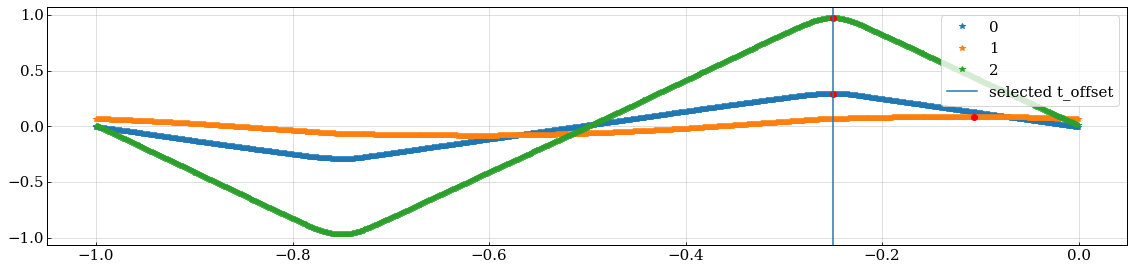

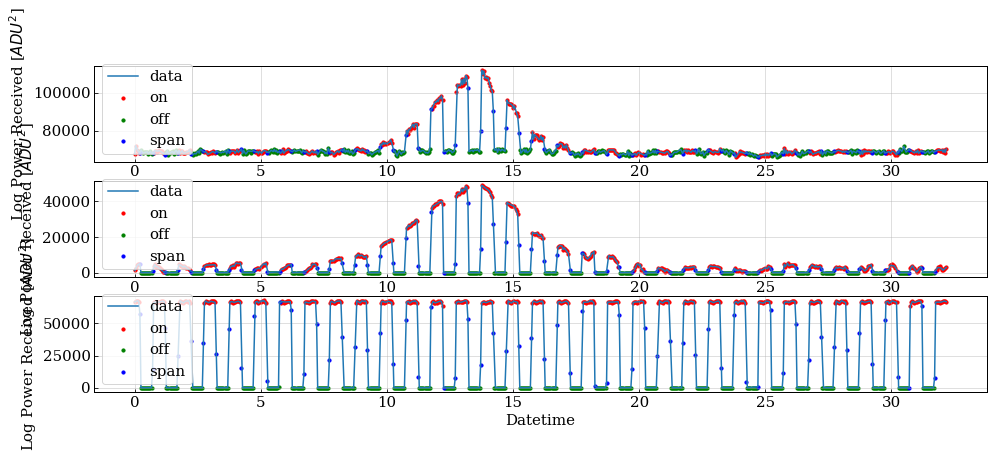

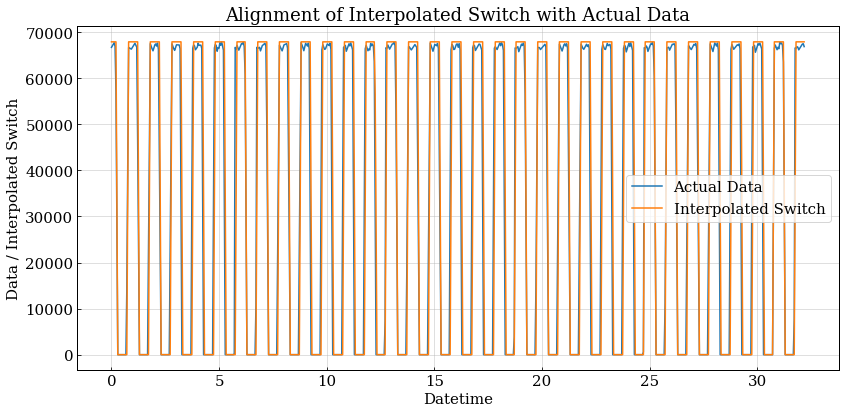

In [93]:
### publication purpose 
freq_arr=[325]
for index,f_ind in enumerate(freq_arr):
    inds_on0, inds_off0, inds_span0=Extract_Source_Pulses_pub(corr_data0,f_ind)


Each time bin is: 0.04194304 seconds
total time bins (considered for the plots) are 768
lowest time bin 0 and highest time bin 768
32.212254720000004 seconds of data (considered for the plots)


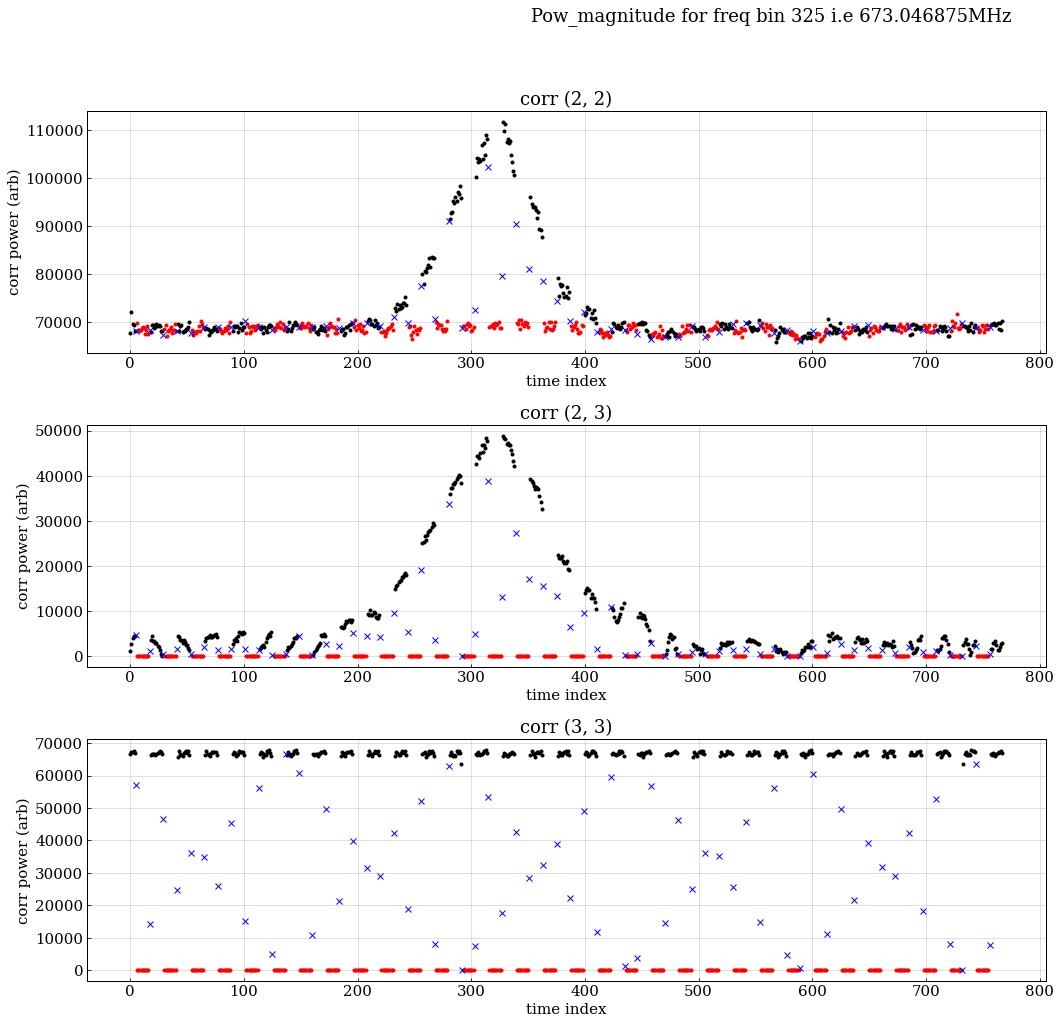

In [110]:
## publication purpose 

pow_mag0, pow_phase0 = get_mag_phase(corr_data0.vis)

tmin,tmax=[0,corr_size[0]]
freq_arr=[325]
corr_indices=[7,8,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[15,15])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        ax.plot(inds_on0,pow_mag0[inds_on0,f_ind,corr_index],'.', c='black', label='abs')
        ax.plot(inds_off0,pow_mag0[inds_off0,f_ind,corr_index],'.', c='red', label='abs')
        ax.plot(inds_span0,pow_mag0[inds_span0,f_ind,corr_index],'x', c='blue', label='abs')
        plt.title(f"corr {corr_data.prod[corr_index]}")
        plt.xlabel("time index")
        plt.ylabel("corr power (arb)")
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9 
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_data.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 

In [165]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def gaussian(x, amp, cen, wid):
    offset=np.median(ydata)
    return offset + amp * np.exp( -(x - cen)**2 / (2 * wid**2) )


In [137]:
p0

[48874.24771799562, 328, 1.0]

Amplitude: 42966.281 ± 331.159
Center: 317.839 ± 0.450
Width (σ): 50.319 ± 0.450


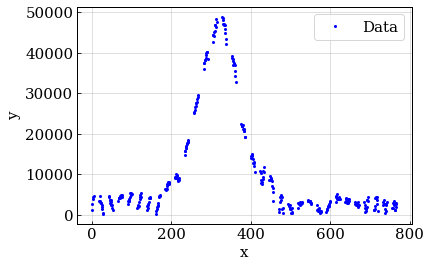

In [217]:
## fitting gaussian data to the data 
f_ind=325
corr_index=8
xdata = inds_on0
ydata=pow_mag0[inds_on0,f_ind,corr_index]

# Initial guess: [amplitude guess, center guess, width guess]
p0 = [max(ydata), xdata[np.argmax(ydata)], 1.0]

# Fit
popt, pcov = curve_fit(gaussian, xdata, ydata, p0=p0)

# Extract params with uncertainties
amp, cen, wid = popt
amp_err, cen_err, wid_err = np.sqrt(np.diag(pcov))

print(f"Amplitude: {amp:.3f} ± {amp_err:.3f}")
print(f"Center: {cen:.3f} ± {cen_err:.3f}")
print(f"Width (σ): {wid:.3f} ± {wid_err:.3f}")

# Plot
plt.plot(xdata, ydata, 'bo', label='Data', markersize=2)
#plt.plot(xdata, gaussian(xdata, *popt), 'r-', label='Fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()


Text(0.5, 0, 'time samples')

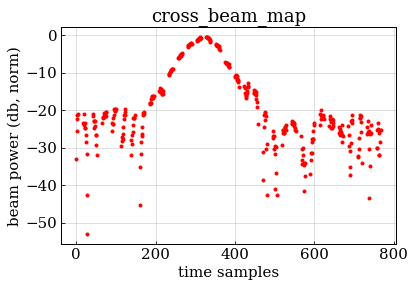

In [223]:
auto_ref=pow_mag0[inds_on0,f_ind,9]
crosslog=20*np.log10(ydata/np.sqrt(auto_ref)) - 46
plt.plot(xdata,crosslog, 'r.')
plt.title('cross_beam_map')
plt.ylabel('beam power (db, norm)')
plt.xlabel('time samples')

156


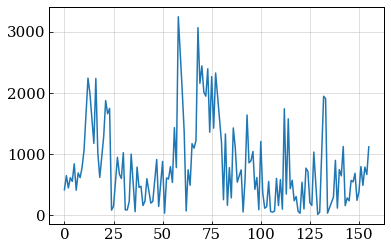

In [194]:
y_true=np.array(ydata)
y_model=np.array(gaussian(xdata, *popt))
residuals = y_true[200:400]-y_model[200:400]
print(len(residuals))
plt.plot(np.abs(residuals))

amp    = 32968.136 ± 603.524
x0     = 318.361 ± 0.779
width  = 80.274 ± 0.652
offset = 70151.293 ± 191.661


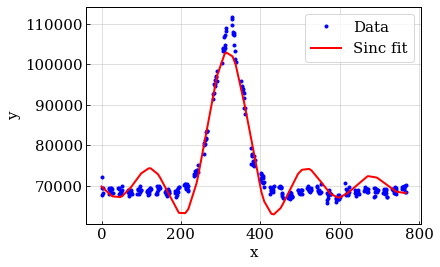

In [154]:
## fitting sinc function to the data 
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Sinc model (normalized NumPy sinc)
def sinc_model(x, amp, x0, width, offset):
    # (x - x0)/width rescales x so width controls main-lobe size
    return offset + amp * np.sinc((x - x0) / width)

# Example data (replace with your xdata, ydata)
f_ind=325
corr_index=7
xdata = np.array(inds_on0)
ydata=pow_mag0[inds_on0,f_ind,corr_index]

# Initial guesses (crucial!)
amp0   = ydata.max() - ydata.min()
x0_0   = xdata[np.argmax(ydata)]
width0 = (xdata.max() - xdata.min()) / 10.0  # rough main-lobe width guess
offset0 = np.median(ydata)

p0 = [amp0, x0_0, width0, offset0]

popt, pcov = curve_fit(sinc_model, xdata, ydata, p0=p0, maxfev=5000)
amp, x0, width, offset = popt
amp_err, x0_err, width_err, offset_err = np.sqrt(np.diag(pcov))

print(f"amp    = {amp:.3f} ± {amp_err:.3f}")
print(f"x0     = {x0:.3f} ± {x0_err:.3f}")
print(f"width  = {width:.3f} ± {width_err:.3f}")
print(f"offset = {offset:.3f} ± {offset_err:.3f}")

# Plot
plt.plot(xdata, ydata, 'bo', ms=3, label='Data')
plt.plot(xdata, sinc_model(xdata, *popt), 'r-', lw=2, label='Sinc fit')
plt.legend()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [ ]:
## do not run this now ##
"""
    Computing statistics for all angles for a given set of frequencies 
    and saving those in .npz files. 
    
    Statistics collected
    --------------------
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels 

"""

freq_arr=[109,]

for index,f_ind in enumerate(freq_arr):
    avgs0,stds0,avgs_off0,var0,var_off0,on_inds0,off_inds0,span0 = Extract_Source_Pulses(corr_data0,f_ind)
    
    avgs5n,stds5n,avgs_off5n,var5n,var_off5n,on_inds5n,off_inds5n,span5n = Extract_Source_Pulses(corr_data5n,f_ind)
    avgs10n,stds10n,avgs_off10n,var10n,var_off10n,on_inds10n,off_inds10n,span10n = Extract_Source_Pulses(corr_data10n,f_ind)
    avgs15n,stds15n,avgs_off15n,var15n,var_off15n,on_inds15n,off_inds15n,span15n = Extract_Source_Pulses(corr_data15n,f_ind)
    avgs20n,stds20n,avgs_off20n,var20n,var_off20n,on_inds20n,off_inds20n,span20n = Extract_Source_Pulses(corr_data20n,f_ind)
    avgs25n,stds25n,avgs_off25n,var25n,var_off25n,on_inds25n,off_inds25n,span25n = Extract_Source_Pulses(corr_data25n,f_ind)
    avgs30n,stds30n,avgs_off30n,var30n,var_off30n,on_inds30n,off_inds30n,span30n = Extract_Source_Pulses(corr_data30n,f_ind)
    avgs35n,stds35n,avgs_off35n,var35n,var_off35n,on_inds35n,off_inds35n,span35n = Extract_Source_Pulses(corr_data35n,f_ind)
    avgs40n,stds40n,avgs_off40n,var40n,var_off40n,on_inds40n,off_inds40n,span40n = Extract_Source_Pulses(corr_data40n,f_ind)
    avgs45n,stds45n,avgs_off45n,var45n,var_off45n,on_inds45n,off_inds45n,span45n = Extract_Source_Pulses(corr_data45n,f_ind)
    avgs50n,stds50n,avgs_off50n,var50n,var_off50n,on_inds50n,off_inds50n,span50n = Extract_Source_Pulses(corr_data50n,f_ind)
    avgs55n,stds55n,avgs_off55n,var55n,var_off55n,on_inds55n,off_inds55n,span55n = Extract_Source_Pulses(corr_data55n,f_ind)
    avgs60n,stds60n,avgs_off60n,var60n,var_off60n,on_inds60n,off_inds60n,span60n = Extract_Source_Pulses(corr_data60n,f_ind)
    avgs65n,stds65n,avgs_off65n,var65n,var_off65n,on_inds65n,off_inds65n,span65n = Extract_Source_Pulses(corr_data65n,f_ind)
    avgs70n,stds70n,avgs_off70n,var70n,var_off70n,on_inds70n,off_inds70n,span70n = Extract_Source_Pulses(corr_data70n,f_ind)
    avgs75n,stds75n,avgs_off75n,var75n,var_off75n,on_inds75n,off_inds75n,span75n = Extract_Source_Pulses(corr_data75n,f_ind)
    avgs80n,stds80n,avgs_off80n,var80n,var_off80n,on_inds80n,off_inds80n,span80n = Extract_Source_Pulses(corr_data80n,f_ind)
    avgs85n,stds85n,avgs_off85n,var85n,var_off85n,on_inds85n,off_inds85n,span85n = Extract_Source_Pulses(corr_data85n,f_ind)
    avgs90n,stds90n,avgs_off90n,var90n,var_off90n,on_inds90n,off_inds90n,span90n = Extract_Source_Pulses(corr_data90n,f_ind)
    avgs95n,stds95n,avgs_off95n,var95n,var_off95n,on_inds95n,off_inds95n,span95n = Extract_Source_Pulses(corr_data95n,f_ind)
    avgs100n,stds100n,avgs_off100n,var100n,var_off100n,on_inds100n,off_inds100n,span100n = Extract_Source_Pulses(corr_data100n,f_ind)
    avgs105n,stds105n,avgs_off105n,var105n,var_off105n,on_inds105n,off_inds105n,span105n = Extract_Source_Pulses(corr_data105n,f_ind)
    avgs110n,stds110n,avgs_off110n,var110n,var_off110n,on_inds110n,off_inds110n,span110n = Extract_Source_Pulses(corr_data110n,f_ind)
    avgs115n,stds115n,avgs_off115n,var115n,var_off115n,on_inds115n,off_inds115n,span115n = Extract_Source_Pulses(corr_data115n,f_ind)
    avgs120n,stds120n,avgs_off120n,var120n,var_off120n,on_inds120n,off_inds120n,span120n = Extract_Source_Pulses(corr_data120n,f_ind)
    avgs125n,stds125n,avgs_off125n,var125n,var_off125n,on_inds125n,off_inds125n,span125n = Extract_Source_Pulses(corr_data125n,f_ind)
    avgs130n,stds130n,avgs_off130n,var130n,var_off130n,on_inds130n,off_inds130n,span130n = Extract_Source_Pulses(corr_data130n,f_ind)
    avgs135n,stds135n,avgs_off135n,var135n, var_off135n,on_inds135n,off_inds135n,span135n = Extract_Source_Pulses(corr_data140n,f_ind)

    avgs5p,stds5p,avgs_off5p,var5p,var_off5p,on_inds5p,off_inds5p,span5p = Extract_Source_Pulses(corr_data5p,f_ind)
    avgs10p,stds10p,avgs_off10p,var10p,var_off10p,on_inds10p,off_inds10p,span10p = Extract_Source_Pulses(corr_data10p,f_ind)
    avgs15p,stds15p,avgs_off15p,var15p,var_off15p,on_inds15p,off_inds15p,span15p = Extract_Source_Pulses(corr_data15p,f_ind)
    avgs20p,stds20p,avgs_off20p,var20p,var_off20p,on_inds20p,off_inds20p,span20p = Extract_Source_Pulses(corr_data20p,f_ind)
    avgs25p,stds25p,avgs_off25p,var25p,var_off25p,on_inds25p,off_inds25p,span25p = Extract_Source_Pulses(corr_data25p,f_ind)
    avgs30p,stds30p,avgs_off30p,var30p,var_off30p,on_inds30p,off_inds30p,span30p = Extract_Source_Pulses(corr_data30p,f_ind)
    avgs35p,stds35p,avgs_off35p,var35p,var_off35p,on_inds35p,off_inds35p,span35p = Extract_Source_Pulses(corr_data35p,f_ind)
    avgs40p,stds40p,avgs_off40p,var40p,var_off40p,on_inds40p,off_inds40p,span40p = Extract_Source_Pulses(corr_data40p,f_ind)
    avgs45p,stds45p,avgs_off45p,var45p,var_off45p,on_inds45p,off_inds45p,span45p = Extract_Source_Pulses(corr_data45p,f_ind)
    avgs50p,stds50p,avgs_off50p,var50p,var_off50p,on_inds50p,off_inds50p,span50p = Extract_Source_Pulses(corr_data50p,f_ind)
    avgs55p,stds55p,avgs_off55p,var55p,var_off55p,on_inds55p,off_inds55p,span55p = Extract_Source_Pulses(corr_data55p,f_ind)
    avgs60p,stds60p,avgs_off60p,var60p,var_off60p,on_inds60p,off_inds60p,span60p = Extract_Source_Pulses(corr_data60p,f_ind)
    avgs65p,stds65p,avgs_off65p,var65p,var_off65p,on_inds65p,off_inds65p,span65p = Extract_Source_Pulses(corr_data65p,f_ind)
    avgs70p,stds70p,avgs_off70p,var70p,var_off70p,on_inds70p,off_inds70p,span70p = Extract_Source_Pulses(corr_data70p,f_ind)
    avgs75p,stds75p,avgs_off75p,var75p,var_off75p,on_inds75p,off_inds75p,span75p = Extract_Source_Pulses(corr_data75p,f_ind)
    avgs80p,stds80p,avgs_off80p,var80p,var_off80p,on_inds80p,off_inds80p,span80p = Extract_Source_Pulses(corr_data80p,f_ind)
    avgs85p,stds85p,avgs_off85p,var85p,var_off85p,on_inds85p,off_inds85p,span85p = Extract_Source_Pulses(corr_data85p,f_ind)
    avgs90p,stds90p,avgs_off90p,var90p,var_off90p,on_inds90p,off_inds90p,span90p = Extract_Source_Pulses(corr_data90p,f_ind)
    avgs95p,stds95p,avgs_off95p,var95p,var_off95p,on_inds95p,off_inds95p,span95p = Extract_Source_Pulses(corr_data95p,f_ind)
    avgs100p,stds100p,avgs_off100p,var100p,var_off100p,on_inds100p,off_inds100p,span100p = Extract_Source_Pulses(corr_data100p,f_ind)
    avgs105p,stds105p,avgs_off105p,var105p,var_off105p,on_inds105p,off_inds105p,span105p = Extract_Source_Pulses(corr_data105p,f_ind)
    avgs110p,stds110p,avgs_off110p,var110p,var_off110p,on_inds110p,off_inds110p,span110p = Extract_Source_Pulses(corr_data110p,f_ind)
    avgs115p,stds115p,avgs_off115p,var115p,var_off115p,on_inds115p,off_inds115p,span115p = Extract_Source_Pulses(corr_data115p,f_ind)
    avgs120p,stds120p,avgs_off120p,var120p,var_off120p,on_inds120p,off_inds120p,span120p = Extract_Source_Pulses(corr_data120p,f_ind)
    avgs125p,stds125p,avgs_off125p,var125p,var_off125p,on_inds125p,off_inds125p,span125p = Extract_Source_Pulses(corr_data125p,f_ind)
    avgs130p,stds130p,avgs_off130p,var130p,var_off130p,on_inds130p,off_inds130p,span130p = Extract_Source_Pulses(corr_data130p,f_ind)
    avgs135p,stds135p,avgs_off135p,var135p,var_off135p,on_inds135p,off_inds135p,span135p = Extract_Source_Pulses(corr_data135p,f_ind)
    #avgs140p,stds140p,avgs_off140p,var140p,var_off140p,on_inds140p,off_inds140p,span140p = Extract_Source_Pulses(corr_data140p)

    #Saving avgs, std dev and varinces into .npz file (steps of 5 degrees) (range -130 to +130 degrees)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats_individual_pulses/means_fbin{}.npz".format(f_ind),avgs0=avgs0,\
            avgs5n=avgs5n, avgs10n=avgs10n, avgs15n=avgs15n, avgs20n=avgs20n, avgs25n=avgs25n, avgs30n=avgs30n, avgs35n=avgs35n, \
            avgs40n=avgs40n, avgs45n=avgs45n, avgs50n=avgs50n, avgs55n=avgs55n, avgs60n=avgs60n, avgs65n=avgs65n, avgs70n=avgs70n, \
            avgs75n=avgs75n, avgs80n=avgs80n, avgs85n=avgs85n, avgs90n=avgs90n, avgs95n=avgs95n, avgs100n=avgs100n, avgs105n=avgs105n, \
            avgs110n=avgs110n, avgs115n=avgs115n, avgs120n=avgs120n, avgs125n=avgs125n, avgs130n=avgs130n, avgs5p=avgs5p, avgs10p=avgs10p, avgs15p=avgs15p, \
            avgs20p=avgs20p, avgs25p=avgs25p, avgs30p=avgs30p, avgs35p=avgs35p, avgs40p=avgs40p, avgs45p=avgs45p, avgs50p=avgs50p, \
            avgs55p=avgs55p, avgs60p=avgs60p, avgs65p=avgs65p, avgs70p=avgs70p, avgs75p=avgs75p, avgs80p=avgs80p, avgs85p=avgs85p, \
            avgs90p=avgs90p, avgs95p=avgs95p, avgs100p=avgs100p, avgs105p=avgs105p, avgs110p=avgs110p, avgs115p=avgs115p, avgs120p=avgs120p, \
            avgs125p=avgs125p, avgs130p=avgs130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats_individual_pulses/stds_fbin{}.npz".format(f_ind), stds0=stds0, \
            stds5n=stds5n, stds10n=stds10n, stds15n=stds15n, stds20n=stds20n, stds25n=stds25n, stds30n=stds30n, stds35n=stds35n, \
            stds40n=stds40n, stds45n=stds45n, stds50n=stds50n, stds55n=stds55n, stds60n=stds60n, stds65n=stds65n, stds70n=stds70n, \
            stds75n=stds75n, stds80n=stds80n, stds85n=stds85n, stds90n=stds90n, stds95n=stds95n, stds100n=stds100n, stds105n=stds105n, \
            stds110n=stds110n, stds115n=stds115n, stds120n=stds120n, stds125n=stds125n, stds130n=stds130n, stds5p=stds5p, stds10p=stds10p, \
            stds15p=stds15p, stds20p=stds20p, stds25p=stds25p, stds30p=stds30p, stds35p=stds35p, stds40p=stds40p, stds45p=stds45p, \
            stds50p=stds50p, stds55p=stds55p, stds60p=stds60p, stds65p=stds65p, stds70p=stds70p, stds75p=stds75p, stds80p=stds80p, \
            stds85p=stds85p, stds90p=stds90p, stds95p=stds95p, stds100p=stds100p, stds105p=stds105p, stds110p=stds110p, stds115p=stds115p, \
            stds120p=stds120p, stds125p=stds125p, stds130p=stds130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats_individual_pulses/means_off_fbin{}.npz".format(f_ind), \
            avgs_off0=avgs_off0, avgs_off5n=avgs_off5n, avgs_off10n=avgs_off10n, avgs_off15n=avgs_off15n, avgs_off20n=avgs_off20n, \
            avgs_off25n=avgs_off25n, avgs_off30n=avgs_off30n, avgs_off35n=avgs_off35n, avgs_off40n=avgs_off40n, avgs_off45n=avgs_off45n, \
            avgs_off50n=avgs_off50n, avgs_off55n=avgs_off55n, avgs_off60n=avgs_off60n, avgs_off65n=avgs_off65n, avgs_off70n=avgs_off70n, \
            avgs_off75n=avgs_off75n, avgs_off80n=avgs_off80n, avgs_off85n=avgs_off85n, avgs_off90n=avgs_off90n, avgs_off95n=avgs_off95n, \
            avgs_off100n=avgs_off100n, avgs_off105n=avgs_off105n, avgs_off110n=avgs_off110n, avgs_off115n=avgs_off115n, avgs_off120n=avgs_off120n, \
            avgs_off125n=avgs_off125n, avgs_off130n=avgs_off130n, avgs_off5p=avgs_off5p, avgs_off10p=avgs_off10p, avgs_off15p=avgs_off15p, \
            avgs_off20p=avgs_off20p, avgs_off25p=avgs_off25p, avgs_off30p=avgs_off30p, avgs_off35p=avgs_off35p, avgs_off40p=avgs_off40p, \
            avgs_off45p=avgs_off45p, avgs_off50p=avgs_off50p, avgs_off55p=avgs_off55p, avgs_off60p=avgs_off60p, avgs_off65p=avgs_off65p, \
            avgs_off70p=avgs_off70p, avgs_off75p=avgs_off75p, avgs_off80p=avgs_off80p, avgs_off85p=avgs_off85p, avgs_off90p=avgs_off90p, \
            avgs_off95p=avgs_off95p, avgs_off100p=avgs_off100p, avgs_off105p=avgs_off105p, avgs_off110p=avgs_off110p, avgs_off115p=avgs_off115p, \
            avgs_off120p=avgs_off120p, avgs_off125p=avgs_off125p, avgs_off130p=avgs_off130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats_individual_pulses/var_fbin{}.npz".format(f_ind), var0=var0, \
            var5n=var5n, var10n=var10n,var15n=var15n, var20n=var20n, var25n=var25n, var30n=var30n, var35n=var35n, var40n=var40n, \
            var45n=var45n, var50n=var50n, var55n=var55n, var60n=var60n, var65n=var65n, var70n=var70n, var75n=var75n, var80n=var80n, \
            var85n=var85n, var90n=var90n, var95n=var95n, var100n=var100n, var105n=var105n, var110n=var110n, var115n=var115n, \
            var120n=var120n, var125n=var125n, var130n=var130n, var5p=var5p, var10p=var10p, var15p=var15p, var20p=var20p, \
            var25p=var25p, var30p=var30p, var35p=var35p, var40p=var40p, var45p=var45p, var50p=var50p, var55p=var55p, var60p=var60p, \
            var65p=var65p, var70p=var70p, var75p=var75p, var80p=var80p, var85p=var85p, var90p=var90p, var95p=var95p, var100p=var100p, \
            var105p=var105p, var110p=var110p, var115p=var115p, var120p=var120p, var125p=var125p, var130p=var130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats_individual_pulses/var_off_fbin{}.npz".format(f_ind), \
            var_off0=var_off0, var_off5n=var_off5n, var_off10n=var_off10n, var_off15n=var_off15n, var_off20n=var_off20n, var_off25n=var_off25n, \
            var_off30n=var_off30n, var_off35n=var_off35n, var_off40n=var_off40n, var_off45n=var_off45n, var_off50n=var_off50n, \
            var_off55n=var_off55n, var_off60n=var_off60n, var_off65n=var_off65n, var_off70n=var_off70n, var_off75n=var_off75n, var_off80n=var_off80n, \
            var_off85n=var_off85n, var_off90n=var_off90n, var_off95n=var_off95n, var_off100n=var100n, var_off105n=var_off105n, \
            var_off110n=var_off110n, var_off115n=var_off115n, var_off120n=var_off120n, var_off125n=var_off125n, var_off130n=var_off130n, \
            var_off5p=var_off5p, var_off10p=var_off10p, var_off15p=var_off15p, var_off20p=var_off20p, var_off25p=var_off25p, \
            var_off30p=var_off30p, var_off35p=var_off35p, var_off40p=var_off40p, var_off45p=var_off45p, var_off50p=var_off50p, \
            var_off55p=var_off55p, var_off60p=var_off60p, var_off65p=var_off65p, var_off70p=var_off70p, var_off75p=var_off75p, var_off80p=var_off80p, \
            var_off85p=var_off85p, var_off90p=var_off90p, var_off95p=var_off95p, var_off100p=var_off100p, var_off105p=var_off105p, var_off110p=var_off110p, \
            var_off115p=var_off115p, var_off120p=var_off120p, var_off125p=var_off125p, var_off130p=var_off130p)


    #Saving on indices, off indices and span of indices into .npz file (steps of 5 degrees) (range -130 to +130p degrees):

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats_individual_pulses/inds_on_fbin{}.npz".format(f_ind), \
            on_inds0=on_inds0, on_inds5n=on_inds5n, on_inds10n=on_inds10n, on_inds15n=on_inds15n, on_inds20n=on_inds20n, \
            on_inds25n=on_inds25n, on_inds30n=on_inds30n, on_inds35n=on_inds35n, on_inds40n=on_inds40n, on_inds45n=on_inds45n, \
            on_inds50n=on_inds50n, on_inds55n=on_inds55n, on_inds60n=on_inds60n, on_inds65n=on_inds65n, on_inds70n=on_inds70n, \
            on_inds75n=on_inds75n, on_inds80n=on_inds80n, on_inds85n=on_inds85n, on_inds90n=on_inds90n, on_inds95n=on_inds95n, \
            on_inds100n=on_inds100n, on_inds105n=on_inds105n, on_inds110n=on_inds110n, on_inds115n=on_inds115n, on_inds120n=on_inds120n, \
            on_inds125n=on_inds125n, on_inds130n=on_inds130n, on_inds5p=on_inds5p, on_inds10p=on_inds10p, on_inds15p=on_inds15p, \
            on_inds20p=on_inds20p, on_inds25p=on_inds25p, on_inds30p=on_inds30p, on_inds35p=on_inds35p, on_inds40p=on_inds40p, \
            on_inds45p=on_inds45p, on_inds50p=on_inds50p, on_inds55p=on_inds55p, on_inds60p=on_inds60p, on_inds65p=on_inds65p, \
            on_inds70p=on_inds70p, on_inds75p=on_inds75p, on_inds80p=on_inds80p, on_inds85p=on_inds85p, on_inds90p=on_inds90p, \
            on_inds95p=on_inds95p, on_inds100p=on_inds100p, on_inds105p=on_inds105p, on_inds110p=on_inds110p, on_inds115p=on_inds115p, \
            on_inds120p=on_inds120p, on_inds125p=on_inds125p, on_inds130p=on_inds130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats_individual_pulses/inds_off_fbin{}.npz".format(f_ind), \
            off_inds0=off_inds0, off_inds5n=off_inds5n, off_inds10n=off_inds10n, off_inds15n=off_inds15n, off_inds20n=off_inds20n, \
            off_inds25n=off_inds25n, off_inds30n=off_inds30n, off_inds35n=off_inds35n, off_inds40n=off_inds40n, off_inds45n=off_inds45n, \
            off_inds50n=off_inds50n, off_inds55n=off_inds55n, off_inds60n=off_inds60n, off_inds65n=off_inds65n, off_inds70n=off_inds70n, \
            off_inds75n=off_inds75n, off_inds80n=off_inds80n, off_inds85n=off_inds85n, off_inds90n=off_inds90n, off_inds95n=off_inds95n, \
            off_inds100n=off_inds100n, off_inds105n=off_inds105n, off_inds110n=off_inds110n, off_inds115n=off_inds115n, \
            off_inds120n=off_inds120n, off_inds125n=off_inds125n, off_inds130n=off_inds130n, \
            off_inds5p=off_inds5p, off_inds10p=off_inds10p, off_inds15p=off_inds15p, off_inds20p=off_inds20p, off_inds25p=off_inds25p, \
            off_inds30p=off_inds30p, off_inds35p=off_inds35p, off_inds40p=off_inds40p, off_inds45p=off_inds45p, off_inds50p=off_inds50p, \
            off_inds55p=off_inds55p, off_inds60p=off_inds60p, off_inds65p=off_inds65p, off_inds70p=off_inds70p, off_inds75p=off_inds75p, \
            off_inds80p=off_inds80p, off_inds85p=off_inds85p, off_inds90p=off_inds90p, off_inds95p=off_inds95p, off_inds100p=off_inds100p, \
            off_inds105p=off_inds105p, off_inds110p=off_inds110p, off_inds115p=off_inds115p, off_inds120p=off_inds120p, \
            off_inds125p=off_inds125p, off_inds130p=off_inds130p)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats_individual_pulses/inds_span_fbin{}.npz".format(f_ind), \
            span0=span0, span5n=span5n, span10n=span10n, span15n=span15n, span20n=span20n, span25n=span25n, span30n=span30n, \
            span35n=span35n, span40n=span40n, span45n=span45n, span50n=span50n, span55n=span55n, span60n=span60n, span65n=span65n, \
            span70n=span70n, span75n=span75n, span80n=span80n, span85n=span85n, span90n=span90n, span95n=span95n, span100n=span100n, \
            span105n=span105n, span110n=span110n, span115n=span115n, span120n=span120n, span125n=span125n, span130n=span130n, \
            span5p=span5p, span10p=span10p, span15p=span15p, span20p=span20p, span25p=span25p, span30p=span30p, span35p=span35p, \
            span40p=span40p, span45p=span45p, span50p=span50p, span55p=span55p, span60p=span60p, span65p=span65p, span70p=span70p, \
            span75p=span75p, span80p=span80p, span85p=span85p, span90p=span90p, span95p=span95p, span100p=span100p, span105p=span105p, \
            span110p=span110p, span115p=span115p, span120p=span120p, span125p=span125p, span130p=span130p)

In [ ]:

"""
    Computing statistics for all angles manually and single frequency at a time
    and saving those in .npz files. 
    
    Statistics collected
    --------------------
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels 

"""
f_ind = 850
avgs0,stds0,avgs_off0,var0,var_off0,on_inds0,off_inds0,span0 = Extract_Source_Pulses(corr_data0,f_ind)
avgs5n,stds5n,avgs_off5n,var5n,var_off5n,on_inds5n,off_inds5n,span5n = Extract_Source_Pulses(corr_data5n,f_ind)
avgs10n,stds10n,avgs_off10n,var10n,var_off10n,on_inds10n,off_inds10n,span10n = Extract_Source_Pulses(corr_data10n,f_ind)
avgs15n,stds15n,avgs_off15n,var15n,var_off15n,on_inds15n,off_inds15n,span15n = Extract_Source_Pulses(corr_data15n,f_ind)
avgs20n,stds20n,avgs_off20n,var20n,var_off20n,on_inds20n,off_inds20n,span20n = Extract_Source_Pulses(corr_data20n,f_ind)
avgs25n,stds25n,avgs_off25n,var25n,var_off25n,on_inds25n,off_inds25n,span25n = Extract_Source_Pulses(corr_data25n,f_ind)
avgs30n,stds30n,avgs_off30n,var30n,var_off30n,on_inds30n,off_inds30n,span30n = Extract_Source_Pulses(corr_data30n,f_ind)
avgs35n,stds35n,avgs_off35n,var35n,var_off35n,on_inds35n,off_inds35n,span35n = Extract_Source_Pulses(corr_data35n,f_ind)
avgs40n,stds40n,avgs_off40n,var40n,var_off40n,on_inds40n,off_inds40n,span40n = Extract_Source_Pulses(corr_data40n,f_ind)
avgs45n,stds45n,avgs_off45n,var45n,var_off45n,on_inds45n,off_inds45n,span45n = Extract_Source_Pulses(corr_data45n,f_ind)
avgs50n,stds50n,avgs_off50n,var50n,var_off50n,on_inds50n,off_inds50n,span50n = Extract_Source_Pulses(corr_data50n,f_ind)
#avgs55n,stds55n,avgs_off55n,var55n,var_off55n,on_inds55n,off_inds55n,span55n = Extract_Source_Pulses(corr_data55n)
#avgs60n,stds60n,avgs_off60n,var60n,var_off60n,on_inds60n,off_inds60n,span60n = Extract_Source_Pulses(corr_data60n)
#avgs65n,stds65n,avgs_off65n,var65n,var_off65n,on_inds65n,off_inds65n,span65n = Extract_Source_Pulses(corr_data65n)
#avgs70n,stds70n,avgs_off70n,var70n,var_off70n,on_inds70n,off_inds70n,span70n = Extract_Source_Pulses(corr_data70n)
#avgs75n,stds75n,avgs_off75n,var75n,var_off75n,on_inds75n,off_inds75n,span75n = Extract_Source_Pulses(corr_data75n)
#avgs80n,stds80n,avgs_off80n,var80n,var_off80n,on_inds80n,off_inds80n,span80n = Extract_Source_Pulses(corr_data80n)
#avgs85n,stds85n,avgs_off85n,var85n,var_off85n,on_inds85n,off_inds85n,span85n = Extract_Source_Pulses(corr_data85n)
#avgs90n,stds90n,avgs_off90n,var90n,var_off90n,on_inds90n,off_inds90n,span90n = Extract_Source_Pulses(corr_data90n)
#avgs95n,stds95n,avgs_off95n,var95n,var_off95n,on_inds95n,off_inds95n,span95n = Extract_Source_Pulses(corr_data95n)
#avgs100n,stds100n,avgs_off100n,var100n,var_off100n,on_inds100n,off_inds100n,span100n = Extract_Source_Pulses(corr_data100n)
#avgs105n,stds105n,avgs_off105n,var105n,var_off105n,on_inds105n,off_inds105n,span105n = Extract_Source_Pulses(corr_data105n)
#avgs110n,stds110n,avgs_off110n,var110n,var_off110n,on_inds110n,off_inds110n,span110n = Extract_Source_Pulses(corr_data110n)
#avgs115n,stds115n,avgs_off115n,var115n,var_off115n,on_inds115n,off_inds115n,span115n = Extract_Source_Pulses(corr_data115n)
#avgs120n,stds120n,avgs_off120n,var120n,var_off120n,on_inds120n,off_inds120n,span120n = Extract_Source_Pulses(corr_data120n)
#avgs125n,stds125n,avgs_off125n,var125n,var_off125n,on_inds125n,off_inds125n,span125n = Extract_Source_Pulses(corr_data125n)
#avgs130n,stds130n,avgs_off130n,var130n,var_off130n,on_inds130n,off_inds130n,span130n = Extract_Source_Pulses(corr_data130n)
#avgs140n,stds140n,avgs_off140n,var140n, var_off140n,on_inds140n,off_inds140n,span140n = Extract_Source_Pulses(corr_data140n)

avgs5p,stds5p,avgs_off5p,var5p,var_off5p,on_inds5p,off_inds5p,span5p = Extract_Source_Pulses(corr_data5p,f_ind)
avgs10p,stds10p,avgs_off10p,var10p,var_off10p,on_inds10p,off_inds10p,span10p = Extract_Source_Pulses(corr_data10p,f_ind)
avgs15p,stds15p,avgs_off15p,var15p,var_off15p,on_inds15p,off_inds15p,span15p = Extract_Source_Pulses(corr_data15p,f_ind)
avgs20p,stds20p,avgs_off20p,var20p,var_off20p,on_inds20p,off_inds20p,span20p = Extract_Source_Pulses(corr_data20p,f_ind)
avgs25p,stds25p,avgs_off25p,var25p,var_off25p,on_inds25p,off_inds25p,span25p = Extract_Source_Pulses(corr_data25p,f_ind)
avgs30p,stds30p,avgs_off30p,var30p,var_off30p,on_inds30p,off_inds30p,span30p = Extract_Source_Pulses(corr_data30p,f_ind)
avgs35p,stds35p,avgs_off35p,var35p,var_off35p,on_inds35p,off_inds35p,span35p = Extract_Source_Pulses(corr_data35p,f_ind)
avgs40p,stds40p,avgs_off40p,var40p,var_off40p,on_inds40p,off_inds40p,span40p = Extract_Source_Pulses(corr_data40p,f_ind)
avgs45p,stds45p,avgs_off45p,var45p,var_off45p,on_inds45p,off_inds45p,span45p = Extract_Source_Pulses(corr_data45p,f_ind)
avgs50p,stds50p,avgs_off50p,var50p,var_off50p,on_inds50p,off_inds50p,span50p = Extract_Source_Pulses(corr_data50p,f_ind)
avgs55p,stds55p,avgs_off55p,var55p,var_off55p,on_inds55p,off_inds55p,span55p = Extract_Source_Pulses(corr_data55p,f_ind)
avgs60p,stds60p,avgs_off60p,var60p,var_off60p,on_inds60p,off_inds60p,span60p = Extract_Source_Pulses(corr_data60p,f_ind)
avgs65p,stds65p,avgs_off65p,var65p,var_off65p,on_inds65p,off_inds65p,span65p = Extract_Source_Pulses(corr_data65p,f_ind)
avgs70p,stds70p,avgs_off70p,var70p,var_off70p,on_inds70p,off_inds70p,span70p = Extract_Source_Pulses(corr_data70p,f_ind)
avgs75p,stds75p,avgs_off75p,var75p,var_off75p,on_inds75p,off_inds75p,span75p = Extract_Source_Pulses(corr_data75p,f_ind)
avgs80p,stds80p,avgs_off80p,var80p,var_off80p,on_inds80p,off_inds80p,span80p = Extract_Source_Pulses(corr_data80p,f_ind)
avgs85p,stds85p,avgs_off85p,var85p,var_off85p,on_inds85p,off_inds85p,span85p = Extract_Source_Pulses(corr_data85p,f_ind)
avgs90p,stds90p,avgs_off90p,var90p,var_off90p,on_inds90p,off_inds90p,span90p = Extract_Source_Pulses(corr_data90p,f_ind)
avgs95p,stds95p,avgs_off95p,var95p,var_off95p,on_inds95p,off_inds95p,span95p = Extract_Source_Pulses(corr_data95p,f_ind)
avgs100p,stds100p,avgs_off100p,var100p,var_off100p,on_inds100p,off_inds100p,span100p = Extract_Source_Pulses(corr_data100p,f_ind)
avgs105p,stds105p,avgs_off105p,var105p,var_off105p,on_inds105p,off_inds105p,span105p = Extract_Source_Pulses(corr_data105p,f_ind)
avgs110p,stds110p,avgs_off110p,var110p,var_off110p,on_inds110p,off_inds110p,span110p = Extract_Source_Pulses(corr_data110p,f_ind)
avgs115p,stds115p,avgs_off115p,var115p,var_off115p,on_inds115p,off_inds115p,span115p = Extract_Source_Pulses(corr_data115p,f_ind)
avgs120p,stds120p,avgs_off120p,var120p,var_off120p,on_inds120p,off_inds120p,span120p = Extract_Source_Pulses(corr_data120p,f_ind)
avgs125p,stds125p,avgs_off125p,var125p,var_off125p,on_inds125p,off_inds125p,span125p = Extract_Source_Pulses(corr_data125p,f_ind)
avgs130p,stds130p,avgs_off130p,var130p,var_off130p,on_inds130p,off_inds130p,span130p = Extract_Source_Pulses(corr_data130p,f_ind)
avgs135p,stds135p,avgs_off135p,var135p,var_off135p,on_inds135p,off_inds135p,span135p = Extract_Source_Pulses(corr_data135p,f_ind)
#avgs140p,stds140p,avgs_off140p,var140p,var_off140p,on_inds140p,off_inds140p,span140p = Extract_Source_Pulses(corr_data140p)


In [ ]:
#Saving avgs, std dev and varinces into .npz file (steps of 5 degrees)(range -50 to +135 degrees):

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_fbin850.npz",avgs0=avgs0,\
        avgs5n=avgs5n, avgs10n=avgs10n, avgs15n=avgs15n, avgs20n=avgs20n, avgs25n=avgs25n, avgs30n=avgs30n, avgs35n=avgs35n, \
        avgs40n=avgs40n, avgs45n=avgs45n, avgs50n=avgs50n, avgs5p=avgs5p, avgs10p=avgs10p, avgs15p=avgs15p, \
        avgs20p=avgs20p, avgs25p=avgs25p, avgs30p=avgs30p, avgs35p=avgs35p, avgs40p=avgs40p, avgs45p=avgs45p, avgs50p=avgs50p, \
        avgs55p=avgs55p, avgs60p=avgs60p, avgs65p=avgs65p, avgs70p=avgs70p, avgs75p=avgs75p, avgs80p=avgs80p, avgs85p=avgs85p, \
        avgs90p=avgs90p, avgs95p=avgs95p, avgs100p=avgs100p, avgs105p=avgs105p, avgs110p=avgs110p, avgs115p=avgs115p, avgs120p=avgs120p, \
        avgs125p=avgs125p, avgs130p=avgs130p, avgs135p=avgs135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/stds_fbin850.npz", stds0=stds0, \
        stds5n=stds5n, stds10n=stds10n, stds15n=stds15n, stds20n=stds20n, stds25n=stds25n, stds30n=stds30n, stds35n=stds35n, \
        stds40n=stds40n, stds45n=stds45n, stds50n=stds50n, stds5p=stds5p, stds10p=stds10p, \
        stds15p=stds15p, stds20p=stds20p, stds25p=stds25p, stds30p=stds30p, stds35p=stds35p, stds40p=stds40p, stds45p=stds45p, \
        stds50p=stds50p, stds55p=stds55p, stds60p=stds60p, stds65p=stds65p, stds70p=stds70p, stds75p=stds75p, stds80p=stds80p, \
        stds85p=stds85p, stds90p=stds90p, stds95p=stds95p, stds100p=stds100p, stds105p=stds105p, stds110p=stds110p, stds115p=stds115p, \
        stds120p=stds120p, stds125p=stds125p, stds130p=stds130p, stds135p=stds135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_off_fbin850.npz", \
        avgs_off0=avgs_off0, avgs_off5n=avgs_off5n, avgs_off10n=avgs_off10n, avgs_off15n=avgs_off15n, avgs_off20n=avgs_off20n, \
        avgs_off25n=avgs_off25n, avgs_off30n=avgs_off30n, avgs_off35n=avgs_off35n, avgs_off40n=avgs_off40n, avgs_off45n=avgs_off45n, \
        avgs_off50n=avgs_off50n, avgs_off5p=avgs_off5p, avgs_off10p=avgs_off10p, avgs_off15p=avgs_off15p, \
        avgs_off20p=avgs_off20p, avgs_off25p=avgs_off25p, avgs_off30p=avgs_off30p, avgs_off35p=avgs_off35p, avgs_off40p=avgs_off40p, \
        avgs_off45p=avgs_off45p, avgs_off50p=avgs_off50p, avgs_off55p=avgs_off55p, avgs_off60p=avgs_off60p, avgs_off65p=avgs_off65p, \
        avgs_off70p=avgs_off70p, avgs_off75p=avgs_off75p, avgs_off80p=avgs_off80p, avgs_off85p=avgs_off85p, avgs_off90p=avgs_off90p, \
        avgs_off95p=avgs_off95p, avgs_off100p=avgs_off100p, avgs_off105p=avgs_off105p, avgs_off110p=avgs_off110p, avgs_off115p=avgs_off115p, \
        avgs_off120p=avgs_off120p, avgs_off125p=avgs_off125p, avgs_off130p=avgs_off130p, avgs_off135p=avgs_off135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_fbin850.npz", var0=var0, \
        var5n=var5n, var10n=var10n,var15n=var15n, var20n=var20n, var25n=var25n, var30n=var30n, var35n=var35n, var40n=var40n, \
        var45n=var45n, var50n=var50n, var5p=var5p, var10p=var10p, var15p=var15p, var20p=var20p, \
        var25p=var25p, var30p=var30p, var35p=var35p, var40p=var40p, var45p=var45p, var50p=var50p, var55p=var55p, var60p=var60p, \
        var65p=var65p, var70p=var70p, var75p=var75p, var80p=var80p, var85p=var85p, var90p=var90p, var95p=var95p, var100p=var100p, \
        var105p=var105p, var110p=var110p, var115p=var115p, var120p=var120p, var125p=var125p, var130p=var130p, var135p=var135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_off_fbin850.npz", \
        var_off0=var_off0, var_off5n=var_off5n, var_off10n=var_off10n, var_off15n=var_off15n, var_off20n=var_off20n, var_off25n=var_off25n, \
        var_off30n=var_off30n, var_off35n=var_off35n, var_off40n=var_off40n, var_off45n=var_off45n, var_off50n=var_off50n, \
        var_off5p=var_off5p, var_off10p=var_off10p, var_off15p=var_off15p, var_off20p=var_off20p, var_off25p=var_off25p, \
        var_off30p=var_off30p, var_off35p=var_off35p, var_off40p=var_off40p, var_off45p=var_off45p, var_off50p=var_off50p, \
        var_off55p=var_off55p, var_off60p=var_off60p, var_off65p=var_off65p, var_off70p=var_off70p, var_off75p=var_off75p, var_off80p=var_off80p, \
        var_off85p=var_off85p, var_off90p=var_off90p, var_off95p=var_off95p, var_off100p=var_off100p, var_off105p=var_off105p, var_off110p=var_off110p, \
        var_off115p=var_off115p, var_off120p=var_off120p, var_off125p=var_off125p, var_off130p=var_off130p, var_off135p=var_off135p)

#Saving on indices, off indices and span of indices into .npz file (steps of 5 degrees) (range -50 to +135 degrees):

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_on_fbin850.npz",\
        on_inds0=on_inds0, on_inds5n=on_inds5n, on_inds10n=on_inds10n, on_inds15n=on_inds15n, on_inds20n=on_inds20n, \
        on_inds25n=on_inds25n, on_inds30n=on_inds30n, on_inds35n=on_inds35n, on_inds40n=on_inds40n, on_inds45n=on_inds45n, \
        on_inds50n=on_inds50n, on_inds5p=on_inds5p, on_inds10p=on_inds10p, on_inds15p=on_inds15p, \
        on_inds20p=on_inds20p, on_inds25p=on_inds25p, on_inds30p=on_inds30p, on_inds35p=on_inds35p, on_inds40p=on_inds40p, \
        on_inds45p=on_inds45p, on_inds50p=on_inds50p, on_inds55p=on_inds55p, on_inds60p=on_inds60p, on_inds65p=on_inds65p, \
        on_inds70p=on_inds70p, on_inds75p=on_inds75p, on_inds80p=on_inds80p, on_inds85p=on_inds85p, on_inds90p=on_inds90p, \
        on_inds95p=on_inds95p, on_inds100p=on_inds100p, on_inds105p=on_inds105p, on_inds110p=on_inds110p, on_inds115p=on_inds115p, \
        on_inds120p=on_inds120p, on_inds125p=on_inds125p, on_inds130p=on_inds130p, on_inds135p=on_inds135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_off_fbin850.npz", \
        off_inds0=off_inds0, off_inds5n=off_inds5n, off_inds10n=off_inds10n, off_inds15n=off_inds15n, off_inds20n=off_inds20n, \
        off_inds25n=off_inds25n, off_inds30n=off_inds30n, off_inds35n=off_inds35n, off_inds40n=off_inds40n, off_inds45n=off_inds45n, \
        off_inds50n=off_inds50n, \
        off_inds5p=off_inds5p, off_inds10p=off_inds10p, off_inds15p=off_inds15p, off_inds20p=off_inds20p, off_inds25p=off_inds25p, \
        off_inds30p=off_inds30p, off_inds35p=off_inds35p, off_inds40p=off_inds40p, off_inds45p=off_inds45p, off_inds50p=off_inds50p, \
        off_inds55p=off_inds55p, off_inds60p=off_inds60p, off_inds65p=off_inds65p, off_inds70p=off_inds70p, off_inds75p=off_inds75p, \
        off_inds80p=off_inds80p, off_inds85p=off_inds85p, off_inds90p=off_inds90p, off_inds95p=off_inds95p, off_inds100p=off_inds100p, \
        off_inds105p=off_inds105p, off_inds110p=off_inds110p, off_inds115p=off_inds115p, off_inds120p=off_inds120p, \
        off_inds125p=off_inds125p, off_inds130p=off_inds130p, off_inds135p=off_inds135p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/inds_span_fbin850.npz", \
        span0=span0, span5n=span5n, span10n=span10n, span15n=span15n, span20n=span20n, span25n=span25n, span30n=span30n, \
        span35n=span35n, span40n=span40n, span45n=span45n, span50n=span50n, \
        span5p=span5p, span10p=span10p, span15p=span15p, span20p=span20p, span25p=span25p, span30p=span30p, span35p=span35p, \
        span40p=span40p, span45p=span45p, span50p=span50p, span55p=span55p, span60p=span60p, span65p=span65p, span70p=span70p, \
        span75p=span75p, span80p=span80p, span85p=span85p, span90p=span90p, span95p=span95p, span100p=span100p, span105p=span105p, \
        span110p=span110p, span115p=span115p, span120p=span120p, span125p=span125p, span130p=span130p, span135p=span135p)


In [ ]:
#Saving avgs, std dev and varinces into .npz file (steps of 5 degrees) (range -130 to +130 degrees)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/means_fbin670.npz",avgs0=avgs0,\
        avgs5n=avgs5n, avgs10n=avgs10n, avgs15n=avgs15n, avgs20n=avgs20n, avgs25n=avgs25n, avgs30n=avgs30n, avgs35n=avgs35n, \
        avgs40n=avgs40n, avgs45n=avgs45n, avgs50n=avgs50n, avgs55n=avgs55n, avgs60n=avgs60n, avgs65n=avgs65n, avgs70n=avgs70n, \
        avgs75n=avgs75n, avgs80n=avgs80n, avgs85n=avgs85n, avgs90n=avgs90n, avgs95n=avgs95n, avgs100n=avgs100n, avgs105n=avgs105n, \
        avgs110n=avgs110n, avgs115n=avgs115n, avgs120n=avgs120n, avgs125n=avgs125n, avgs130n=avgs130n, avgs5p=avgs5p, avgs10p=avgs10p, avgs15p=avgs15p, \
        avgs20p=avgs20p, avgs25p=avgs25p, avgs30p=avgs30p, avgs35p=avgs35p, avgs40p=avgs40p, avgs45p=avgs45p, avgs50p=avgs50p, \
        avgs55p=avgs55p, avgs60p=avgs60p, avgs65p=avgs65p, avgs70p=avgs70p, avgs75p=avgs75p, avgs80p=avgs80p, avgs85p=avgs85p, \
        avgs90p=avgs90p, avgs95p=avgs95p, avgs100p=avgs100p, avgs105p=avgs105p, avgs110p=avgs110p, avgs115p=avgs115p, avgs120p=avgs120p, \
        avgs125p=avgs125p, avgs130p=avgs130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/stds_fbin670.npz", stds0=stds0, \
        stds5n=stds5n, stds10n=stds10n, stds15n=stds15n, stds20n=stds20n, stds25n=stds25n, stds30n=stds30n, stds35n=stds35n, \
        stds40n=stds40n, stds45n=stds45n, stds50n=stds50n, stds55n=stds55n, stds60n=stds60n, stds65n=stds65n, stds70n=stds70n, \
        stds75n=stds75n, stds80n=stds80n, stds85n=stds85n, stds90n=stds90n, stds95n=stds95n, stds100n=stds100n, stds105n=stds105n, \
        stds110n=stds110n, stds115n=stds115n, stds120n=stds120n, stds125n=stds125n, stds130n=stds130n, stds5p=stds5p, stds10p=stds10p, \
        stds15p=stds15p, stds20p=stds20p, stds25p=stds25p, stds30p=stds30p, stds35p=stds35p, stds40p=stds40p, stds45p=stds45p, \
        stds50p=stds50p, stds55p=stds55p, stds60p=stds60p, stds65p=stds65p, stds70p=stds70p, stds75p=stds75p, stds80p=stds80p, \
        stds85p=stds85p, stds90p=stds90p, stds95p=stds95p, stds100p=stds100p, stds105p=stds105p, stds110p=stds110p, stds115p=stds115p, \
        stds120p=stds120p, stds125p=stds125p, stds130p=stds130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/means_off_fbin635.npz", \
        avgs_off0=avgs_off0, avgs_off5n=avgs_off5n, avgs_off10n=avgs_off10n, avgs_off15n=avgs_off15n, avgs_off20n=avgs_off20n, \
        avgs_off25n=avgs_off25n, avgs_off30n=avgs_off30n, avgs_off35n=avgs_off35n, avgs_off40n=avgs_off40n, avgs_off45n=avgs_off45n, \
        avgs_off50n=avgs_off50n, avgs_off55n=avgs_off55n, avgs_off60n=avgs_off60n, avgs_off65n=avgs_off65n, avgs_off70n=avgs_off70n, \
        avgs_off75n=avgs_off75n, avgs_off80n=avgs_off80n, avgs_off85n=avgs_off85n, avgs_off90n=avgs_off90n, avgs_off95n=avgs_off95n, \
        avgs_off100n=avgs_off100n, avgs_off105n=avgs_off105n, avgs_off110n=avgs_off110n, avgs_off115n=avgs_off115n, avgs_off120n=avgs_off120n, \
        avgs_off125n=avgs_off125n, avgs_off130n=avgs_off130n, avgs_off5p=avgs_off5p, avgs_off10p=avgs_off10p, avgs_off15p=avgs_off15p, \
        avgs_off20p=avgs_off20p, avgs_off25p=avgs_off25p, avgs_off30p=avgs_off30p, avgs_off35p=avgs_off35p, avgs_off40p=avgs_off40p, \
        avgs_off45p=avgs_off45p, avgs_off50p=avgs_off50p, avgs_off55p=avgs_off55p, avgs_off60p=avgs_off60p, avgs_off65p=avgs_off65p, \
        avgs_off70p=avgs_off70p, avgs_off75p=avgs_off75p, avgs_off80p=avgs_off80p, avgs_off85p=avgs_off85p, avgs_off90p=avgs_off90p, \
        avgs_off95p=avgs_off95p, avgs_off100p=avgs_off100p, avgs_off105p=avgs_off105p, avgs_off110p=avgs_off110p, avgs_off115p=avgs_off115p, \
        avgs_off120p=avgs_off120p, avgs_off125p=avgs_off125p, avgs_off130p=avgs_off130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/var_fbin635.npz", var0=var0, \
        var5n=var5n, var10n=var10n,var15n=var15n, var20n=var20n, var25n=var25n, var30n=var30n, var35n=var35n, var40n=var40n, \
        var45n=var45n, var50n=var50n, var55n=var55n, var60n=var60n, var65n=var65n, var70n=var70n, var75n=var75n, var80n=var80n, \
        var85n=var85n, var90n=var90n, var95n=var95n, var100n=var100n, var105n=var105n, var110n=var110n, var115n=var115n, \
        var120n=var120n, var125n=var125n, var130n=var130n, var5p=var5p, var10p=var10p, var15p=var15p, var20p=var20p, \
        var25p=var25p, var30p=var30p, var35p=var35p, var40p=var40p, var45p=var45p, var50p=var50p, var55p=var55p, var60p=var60p, \
        var65p=var65p, var70p=var70p, var75p=var75p, var80p=var80p, var85p=var85p, var90p=var90p, var95p=var95p, var100p=var100p, \
        var105p=var105p, var110p=var110p, var115p=var115p, var120p=var120p, var125p=var125p, var130p=var130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/var_off_fbin635.npz", \
        var_off0=var_off0, var_off5n=var_off5n, var_off10n=var_off10n, var_off15n=var_off15n, var_off20n=var_off20n, var_off25n=var_off25n, \
        var_off30n=var_off30n, var_off35n=var_off35n, var_off40n=var_off40n, var_off45n=var_off45n, var_off50n=var_off50n, \
        var_off55n=var_off55n, var_off60n=var_off60n, var_off65n=var_off65n, var_off70n=var_off70n, var_off75n=var_off75n, var_off80n=var_off80n, \
        var_off85n=var_off85n, var_off90n=var_off90n, var_off95n=var_off95n, var_off100n=var100n, var_off105n=var_off105n, \
        var_off110n=var_off110n, var_off115n=var_off115n, var_off120n=var_off120n, var_off125n=var_off125n, var_off130n=var_off130n, \
        var_off5p=var_off5p, var_off10p=var_off10p, var_off15p=var_off15p, var_off20p=var_off20p, var_off25p=var_off25p, \
        var_off30p=var_off30p, var_off35p=var_off35p, var_off40p=var_off40p, var_off45p=var_off45p, var_off50p=var_off50p, \
        var_off55p=var_off55p, var_off60p=var_off60p, var_off65p=var_off65p, var_off70p=var_off70p, var_off75p=var_off75p, var_off80p=var_off80p, \
        var_off85p=var_off85p, var_off90p=var_off90p, var_off95p=var_off95p, var_off100p=var_off100p, var_off105p=var_off105p, var_off110p=var_off110p, \
        var_off115p=var_off115p, var_off120p=var_off120p, var_off125p=var_off125p, var_off130p=var_off130p)


#Saving on indices, off indices and span of indices into .npz file (steps of 5 degrees) (range -130 to +130p degrees):

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/inds_on_fbin635.npz",\
        on_inds0=on_inds0, on_inds5n=on_inds5n, on_inds10n=on_inds10n, on_inds15n=on_inds15n, on_inds20n=on_inds20n, \
        on_inds25n=on_inds25n, on_inds30n=on_inds30n, on_inds35n=on_inds35n, on_inds40n=on_inds40n, on_inds45n=on_inds45n, \
        on_inds50n=on_inds50n, on_inds55n=on_inds55n, on_inds60n=on_inds60n, on_inds65n=on_inds65n, on_inds70n=on_inds70n, \
        on_inds75n=on_inds75n, on_inds80n=on_inds80n, on_inds85n=on_inds85n, on_inds90n=on_inds90n, on_inds95n=on_inds95n, \
        on_inds100n=on_inds100n, on_inds105n=on_inds105n, on_inds110n=on_inds110n, on_inds115n=on_inds115n, on_inds120n=on_inds120n, \
        on_inds125n=on_inds125n, on_inds130n=on_inds130n, on_inds5p=on_inds5p, on_inds10p=on_inds10p, on_inds15p=on_inds15p, \
        on_inds20p=on_inds20p, on_inds25p=on_inds25p, on_inds30p=on_inds30p, on_inds35p=on_inds35p, on_inds40p=on_inds40p, \
        on_inds45p=on_inds45p, on_inds50p=on_inds50p, on_inds55p=on_inds55p, on_inds60p=on_inds60p, on_inds65p=on_inds65p, \
        on_inds70p=on_inds70p, on_inds75p=on_inds75p, on_inds80p=on_inds80p, on_inds85p=on_inds85p, on_inds90p=on_inds90p, \
        on_inds95p=on_inds95p, on_inds100p=on_inds100p, on_inds105p=on_inds105p, on_inds110p=on_inds110p, on_inds115p=on_inds115p, \
        on_inds120p=on_inds120p, on_inds125p=on_inds125p, on_inds130p=on_inds130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/inds_off_fbin635.npz", \
        off_inds0=off_inds0, off_inds5n=off_inds5n, off_inds10n=off_inds10n, off_inds15n=off_inds15n, off_inds20n=off_inds20n, \
        off_inds25n=off_inds25n, off_inds30n=off_inds30n, off_inds35n=off_inds35n, off_inds40n=off_inds40n, off_inds45n=off_inds45n, \
        off_inds50n=off_inds50n, off_inds55n=off_inds55n, off_inds60n=off_inds60n, off_inds65n=off_inds65n, off_inds70n=off_inds70n, \
        off_inds75n=off_inds75n, off_inds80n=off_inds80n, off_inds85n=off_inds85n, off_inds90n=off_inds90n, off_inds95n=off_inds95n, \
        off_inds100n=off_inds100n, off_inds105n=off_inds105n, off_inds110n=off_inds110n, off_inds115n=off_inds115n, \
        off_inds120n=off_inds120n, off_inds125n=off_inds125n, off_inds130n=off_inds130n, \
        off_inds5p=off_inds5p, off_inds10p=off_inds10p, off_inds15p=off_inds15p, off_inds20p=off_inds20p, off_inds25p=off_inds25p, \
        off_inds30p=off_inds30p, off_inds35p=off_inds35p, off_inds40p=off_inds40p, off_inds45p=off_inds45p, off_inds50p=off_inds50p, \
        off_inds55p=off_inds55p, off_inds60p=off_inds60p, off_inds65p=off_inds65p, off_inds70p=off_inds70p, off_inds75p=off_inds75p, \
        off_inds80p=off_inds80p, off_inds85p=off_inds85p, off_inds90p=off_inds90p, off_inds95p=off_inds95p, off_inds100p=off_inds100p, \
        off_inds105p=off_inds105p, off_inds110p=off_inds110p, off_inds115p=off_inds115p, off_inds120p=off_inds120p, \
        off_inds125p=off_inds125p, off_inds130p=off_inds130p)

np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/443Z...Mar172025/stats/inds_span_fbin635.npz", \
        span0=span0, span5n=span5n, span10n=span10n, span15n=span15n, span20n=span20n, span25n=span25n, span30n=span30n, \
        span35n=span35n, span40n=span40n, span45n=span45n, span50n=span50n, span55n=span55n, span60n=span60n, span65n=span65n, \
        span70n=span70n, span75n=span75n, span80n=span80n, span85n=span85n, span90n=span90n, span95n=span95n, span100n=span100n, \
        span105n=span105n, span110n=span110n, span115n=span115n, span120n=span120n, span125n=span125n, span130n=span130n, \
        span5p=span5p, span10p=span10p, span15p=span15p, span20p=span20p, span25p=span25p, span30p=span30p, span35p=span35p, \
        span40p=span40p, span45p=span45p, span50p=span50p, span55p=span55p, span60p=span60p, span65p=span65p, span70p=span70p, \
        span75p=span75p, span80p=span80p, span85p=span85p, span90p=span90p, span95p=span95p, span100p=span100p, span105p=span105p, \
        span110p=span110p, span115p=span115p, span120p=span120p, span125p=span125p, span130p=span130p)


### Plotting beam maps for set of few frequencies chosen from broadband range ###

In [ ]:
#Loading stats from saved files:
avgs=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July19...740Z/stats/means_fbin265.npz")
avgs_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July19...740Z/stats/means_off_fbin265.npz")
stds=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July19...740Z/stats/stds_fbin265.npz")
var=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July19...740Z/stats/var_fbin265.npz")
var_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July19...740Z/stats/var_off_fbin265.npz")


In [ ]:
#What's the frequency corresponding to the given frequency index?
f_ind=265
print(f"Frequency corresponding to frequncy index {f_ind} is {400+((1024-f_ind)*0.390625)}MHz")

In [ ]:
"""
    Stats from saved files --- N 65536 (steps of 5 degrees) (range 85n to 85p)
    autos and crosses means, std dev and variances lists-- correlator data 

    When
    autos_0x0 -- <VV*>t,ON
    autos_0x0_off -- <VV*>t,OFF
    crosses_0x1 -- <VtVref*>ON
    autos_1x1 -- <VV*>ref,ON 
    autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case) 
"""

#autos00 = [avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0], avgs['avgs135p'][0]]
#autos11 = [avgs['avgs50n'][2], avgs['avgs45n'][2], avgs['avgs40n'][2], avgs['avgs35n'][2], avgs['avgs30n'][2], avgs['avgs25n'][2], avgs['avgs20n'][2], avgs['avgs15n'][2], avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2], avgs['avgs15p'][2], avgs['avgs20p'][2], avgs['avgs25p'][2], avgs['avgs30p'][2], avgs['avgs35p'][2], avgs['avgs40p'][2], avgs['avgs45p'][2], avgs['avgs50p'][2], avgs['avgs55p'][2], avgs['avgs60p'][2], avgs['avgs65p'][2], avgs['avgs70p'][2], avgs['avgs75p'][2], avgs['avgs80p'][2], avgs['avgs85p'][2], avgs['avgs90p'][2], avgs['avgs95p'][2], avgs['avgs100p'][2], avgs['avgs105p'][2], avgs['avgs110p'][2], avgs['avgs115p'][2], avgs['avgs120p'][2], avgs['avgs125p'][2], avgs['avgs130p'][2], avgs['avgs135p'][2]]
#crosses01 = [avgs['avgs50n'][1], avgs['avgs45n'][1], avgs['avgs40n'][1], avgs['avgs35n'][1], avgs['avgs30n'][1], avgs['avgs25n'][1], avgs['avgs20n'][1], avgs['avgs15n'][1], avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1], avgs['avgs15p'][1], avgs['avgs20p'][1], avgs['avgs25p'][1], avgs['avgs30p'][1], avgs['avgs35p'][1], avgs['avgs40p'][1], avgs['avgs45p'][1], avgs['avgs50p'][1], avgs['avgs55p'][1], avgs['avgs60p'][1], avgs['avgs65p'][1], avgs['avgs70p'][1], avgs['avgs75p'][1], avgs['avgs80p'][1], avgs['avgs85p'][1], avgs['avgs90p'][1], avgs['avgs95p'][1], avgs['avgs100p'][1], avgs['avgs105p'][1], avgs['avgs110p'][1], avgs['avgs115p'][1], avgs['avgs120p'][1], avgs['avgs125p'][1], avgs['avgs130p'][1], avgs['avgs135p'][1]]
#var_auto00 = [var['var50n'][0], var['var45n'][0], var['var40n'][0], var['var35n'][0], var['var30n'][0], var['var25n'][0], var['var20n'][0], var['var15n'][0], var['var10n'][0], var['var5n'][0], var['var0'][0], var['var5p'][0], var['var10p'][0], var['var15p'][0], var['var20p'][0], var['var25p'][0], var['var30p'][0], var['var35p'][0], var['var40p'][0], var['var45p'][0], var['var50p'][0], var['var55p'][0], var['var60p'][0], var['var65p'][0], var['var70p'][0], var['var75p'][0], var['var80p'][0], var['var85p'][0], var['var90p'][0], var['var95p'][0], var['var100p'][0], var['var105p'][0], var['var110p'][0], var['var115p'][0], var['var120p'][0], var['var125p'][0], var['var130p'][0], var['var135p'][0]]
#var_auto11 = [var['var50n'][2], var['var45n'][2], var['var40n'][2], var['var35n'][2], var['var30n'][2], var['var25n'][2], var['var20n'][2], var['var15n'][2], var['var10n'][2], var['var5n'][2], var['var0'][2], var['var5p'][2], var['var10p'][2], var['var15p'][2], var['var20p'][2], var['var25p'][2], var['var30p'][2], var['var35p'][2], var['var40p'][2], var['var45p'][2], var['var50p'][2], var['var55p'][2], var['var60p'][2], var['var65p'][2], var['var70p'][2], var['var75p'][2], var['var80p'][2], var['var85p'][2], var['var90p'][2], var['var95p'][2], var['var100p'][2], var['var105p'][2], var['var110p'][2], var['var115p'][2], var['var120p'][2], var['var125p'][2], var['var130p'][2], var['var135p'][2]]
#stddev_cross01 = [stds['stds50n'][1], stds['stds45n'][1], stds['stds40n'][1], stds['stds35n'][1], stds['stds30n'][1], stds['stds25n'][1], stds['stds20n'][1], stds['stds15n'][1], stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1], stds['stds15p'][1], stds['stds20p'][1], stds['stds25p'][1], stds['stds30p'][1], stds['stds35p'][1], stds['stds40p'][1], stds['stds45p'][1], stds['stds50p'][1], stds['stds55p'][1], stds['stds60p'][1], stds['stds65p'][1], stds['stds70p'][1], stds['stds75p'][1], stds['stds80p'][1], stds['stds85p'][1], stds['stds90p'][1], stds['stds95p'][1], stds['stds100p'][1], stds['stds105p'][1], stds['stds110p'][1], stds['stds115p'][1], stds['stds120p'][1], stds['stds125p'][1], stds['stds130p'][1],stds['stds135p'][1]]

""" NS-NS configuration --
    Channel 3 -- cross-pol
    Channel 6 -- co-pol
    Channel 8 -- co-pol 
"""
#autos44 = [avgs['avgs85n'][4], avgs['avgs80n'][4], avgs['avgs75n'][4], avgs['avgs70n'][4], avgs['avgs65n'][4], avgs['avgs60n'][4], avgs['avgs55n'][4], avgs['avgs50n'][4], avgs['avgs45n'][4], avgs['avgs40n'][4], avgs['avgs35n'][4], avgs['avgs30n'][4], avgs['avgs25n'][4], avgs['avgs20n'][4], avgs['avgs15n'][4], avgs['avgs10n'][4], avgs['avgs5n'][4], avgs['avgs0'][4], avgs['avgs5p'][4], avgs['avgs10p'][4], avgs['avgs15p'][4], avgs['avgs20p'][4], avgs['avgs25p'][4], avgs['avgs30p'][4], avgs['avgs35p'][4], avgs['avgs40p'][4], avgs['avgs45p'][4], avgs['avgs50p'][4], avgs['avgs55p'][4], avgs['avgs60p'][4], avgs['avgs65p'][4], avgs['avgs70p'][4], avgs['avgs75p'][4], avgs['avgs80p'][4], avgs['avgs85p'][4]]
#autos99 = [avgs['avgs85n'][9], avgs['avgs80n'][9], avgs['avgs75n'][9], avgs['avgs70n'][9], avgs['avgs65n'][9], avgs['avgs60n'][9], avgs['avgs55n'][9], avgs['avgs50n'][9], avgs['avgs45n'][9], avgs['avgs40n'][9], avgs['avgs35n'][9], avgs['avgs30n'][9], avgs['avgs25n'][9], avgs['avgs20n'][9], avgs['avgs15n'][9], avgs['avgs10n'][9], avgs['avgs5n'][9], avgs['avgs0'][9], avgs['avgs5p'][9], avgs['avgs10p'][9], avgs['avgs15p'][9], avgs['avgs20p'][9], avgs['avgs25p'][9], avgs['avgs30p'][9], avgs['avgs35p'][9], avgs['avgs40p'][9], avgs['avgs45p'][9], avgs['avgs50p'][9], avgs['avgs55p'][9], avgs['avgs60p'][9], avgs['avgs65p'][9], avgs['avgs70p'][9], avgs['avgs75p'][9], avgs['avgs80p'][9], avgs['avgs85p'][9]]
#crosses49 = [avgs['avgs85n'][6], avgs['avgs80n'][6], avgs['avgs75n'][6], avgs['avgs70n'][6], avgs['avgs65n'][6], avgs['avgs60n'][6], avgs['avgs55n'][6], avgs['avgs50n'][6], avgs['avgs45n'][6], avgs['avgs40n'][6], avgs['avgs35n'][6], avgs['avgs30n'][6], avgs['avgs25n'][6], avgs['avgs20n'][6], avgs['avgs15n'][6], avgs['avgs10n'][6], avgs['avgs5n'][6], avgs['avgs0'][6], avgs['avgs5p'][6], avgs['avgs10p'][6], avgs['avgs15p'][6], avgs['avgs20p'][6], avgs['avgs25p'][6], avgs['avgs30p'][6], avgs['avgs35p'][6], avgs['avgs40p'][6], avgs['avgs45p'][6], avgs['avgs50p'][6], avgs['avgs55p'][6], avgs['avgs60p'][6], avgs['avgs65p'][6], avgs['avgs70p'][6], avgs['avgs75p'][6], avgs['avgs80p'][6], avgs['avgs85p'][6]]
#var_auto44 = [var['var85n'][4], var['var80n'][4], var['var75n'][4], var['var70n'][4], var['var65n'][4], var['var60n'][4], var['var55n'][4], var['var50n'][4], var['var45n'][4], var['var40n'][4], var['var35n'][4], var['var30n'][4], var['var25n'][4], var['var20n'][4], var['var15n'][4], var['var10n'][4], var['var5n'][4], var['var0'][4], var['var5p'][4], var['var10p'][4], var['var15p'][4], var['var20p'][4], var['var25p'][4], var['var30p'][4], var['var35p'][4], var['var40p'][4], var['var45p'][4], var['var50p'][4], var['var55p'][4], var['var60p'][4], var['var65p'][4], var['var70p'][4], var['var75p'][4], var['var80p'][4], var['var85p'][4]]
#var_auto99 = [var['var85n'][9], var['var80n'][9], var['var75n'][9], var['var70n'][9], var['var65n'][9], var['var60n'][9], var['var55n'][9], var['var50n'][9], var['var45n'][9], var['var40n'][9], var['var35n'][9], var['var30n'][9], var['var25n'][9], var['var20n'][9], var['var15n'][9], var['var10n'][9], var['var5n'][9], var['var0'][9], var['var5p'][9], var['var10p'][9], var['var15p'][9], var['var20p'][9], var['var25p'][9], var['var30p'][9], var['var35p'][9], var['var40p'][9], var['var45p'][9], var['var50p'][9], var['var55p'][9], var['var60p'][9], var['var65p'][9], var['var70p'][9], var['var75p'][9], var['var80p'][9], var['var85p'][9]]
#stddev_cross49 = [stds['stds85n'][6], stds['stds80n'][6], stds['stds75n'][6], stds['stds70n'][6], stds['stds65n'][6], stds['stds60n'][6], stds['stds55n'][6], stds['stds50n'][6], stds['stds45n'][6], stds['stds40n'][6], stds['stds35n'][6], stds['stds30n'][6], stds['stds25n'][6], stds['stds20n'][6], stds['stds15n'][6], stds['stds10n'][6], stds['stds5n'][6], stds['stds0'][6], stds['stds5p'][6], stds['stds10p'][6], stds['stds15p'][6], stds['stds20p'][6], stds['stds25p'][6], stds['stds30p'][6], stds['stds35p'][6], stds['stds40p'][6], stds['stds45p'][6], stds['stds50p'][6], stds['stds55p'][6], stds['stds60p'][6], stds['stds65p'][6], stds['stds70p'][6], stds['stds75p'][6], stds['stds80p'][6], stds['stds85p'][6]]

autos44 = [avgs['avgs15n'][4], avgs['avgs10n'][4], avgs['avgs5n'][4], avgs['avgs0'][4], avgs['avgs5p'][4], avgs['avgs10p'][4], avgs['avgs15p'][4]]
autos99 = [avgs['avgs15n'][9], avgs['avgs10n'][9], avgs['avgs5n'][9], avgs['avgs0'][9], avgs['avgs5p'][9], avgs['avgs10p'][9], avgs['avgs15p'][9]]
crosses49 = [avgs['avgs15n'][6], avgs['avgs10n'][6], avgs['avgs5n'][6], avgs['avgs0'][6], avgs['avgs5p'][6], avgs['avgs10p'][6], avgs['avgs15p'][6]]
var_auto44 = [var['var15n'][4], var['var10n'][4], var['var5n'][4], var['var0'][4], var['var5p'][4], var['var10p'][4], var['var15p'][4]]
var_auto99 = [var['var15n'][9], var['var10n'][9], var['var5n'][9], var['var0'][9], var['var5p'][9], var['var10p'][9], var['var15p'][9]]
stddev_cross49 = [stds['stds15n'][6], stds['stds10n'][6], stds['stds5n'][6], stds['stds0'][6], stds['stds5p'][6], stds['stds10p'][6], stds['stds15p'][6]]


autos_4x4 = []
autos_9x9 = []
crosses_4x9 = []
var_auto4x4 = []
var_auto9x9 = []
stddev_cross = []

for i, array in enumerate(autos44):
    for j in range(len(autos44[i])):
        autos_4x4.append(autos44[i][j])
        autos_9x9.append(autos99[i][j])
        crosses_4x9.append(crosses49[i][j])
        var_auto4x4.append(var_auto44[i][j])
        var_auto9x9.append(var_auto99[i][j])
        stddev_cross.append(stddev_cross49[i][j])

print('length of the averages for test ON autos:',len(autos_4x4))
plt.plot(np.arange(0,len(autos_4x4)),autos_4x4,'x',label='autos_test_on', color='g')
print('length of the averages for ref ON autos:',len(autos_9x9))
plt.plot(np.arange(0,len(autos_9x9)),autos_9x9,'s',label='autos_ref_on', color='r')
print('length of the averages for cross ON autos:',len(crosses_4x9))
plt.plot(np.arange(0,len(crosses_4x9)),crosses_4x9,'+',label='crosses_on', color='b')
print('length of the variances for test ON autos:',len(var_auto4x4))
#plt.plot(np.arange(0,len(var_auto0x0)),var_auto0x0,'+',label='var_test_on', color='violet')
print('length of the variances for ref ON autos:',len(var_auto9x9))
#plt.plot(np.arange(0,len(var_auto1x1)),var_auto1x1,'+',label='var_ref_on', color='violet')
print('length of the std dev for crosses:',len(stddev_cross))
plt.plot(np.arange(0,len(stddev_cross)),stddev_cross,'+',label='std_crosses_on', color='violet')
plt.xlabel('number of samples')
plt.ylabel('correlation power (arb)')
plt.legend()


#autos44_off = [avgs_off['avgs_off85n'][4], avgs_off['avgs_off80n'][4], avgs_off['avgs_off75n'][4], avgs_off['avgs_off70n'][4], avgs_off['avgs_off65n'][4], avgs_off['avgs_off60n'][4], avgs_off['avgs_off55n'][4], avgs_off['avgs_off50n'][4], avgs_off['avgs_off45n'][4], avgs_off['avgs_off40n'][4], avgs_off['avgs_off35n'][4], avgs_off['avgs_off30n'][4], avgs_off['avgs_off25n'][4], avgs_off['avgs_off20n'][4], avgs_off['avgs_off15n'][4], avgs_off['avgs_off10n'][4], avgs_off['avgs_off5n'][4], avgs_off['avgs_off0'][4], avgs_off['avgs_off5p'][4], avgs_off['avgs_off10p'][4], avgs_off['avgs_off15p'][4], avgs_off['avgs_off20p'][4], avgs_off['avgs_off25p'][4], avgs_off['avgs_off30p'][4], avgs_off['avgs_off35p'][4], avgs_off['avgs_off40p'][4], avgs_off['avgs_off45p'][4], avgs_off['avgs_off50p'][4], avgs_off['avgs_off55p'][4], avgs_off['avgs_off60p'][4], avgs_off['avgs_off65p'][4], avgs_off['avgs_off70p'][4], avgs_off['avgs_off75p'][4], avgs_off['avgs_off80p'][4], avgs_off['avgs_off85p'][4]]
autos44_off = [avgs_off['avgs_off15n'][4], avgs_off['avgs_off10n'][4], avgs_off['avgs_off5n'][4], avgs_off['avgs_off0'][4], avgs_off['avgs_off5p'][4], avgs_off['avgs_off10p'][4], avgs_off['avgs_off15p'][4]]
autos_4x4_off = []

for i, array in enumerate(autos44_off):
    for j in range(len(autos44_off[i])):
        autos_4x4_off.append(autos44_off[i][j])
        
print('length of the averages for test OFF autos:',len(autos_4x4_off))
plt.plot(np.arange(0,len(autos_4x4_off)),autos_4x4_off,'o',label='autos_test_off', color='yellow')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

#var_auto44_off = [var_off['var_off85n'][4], var_off['var_off80n'][4], var_off['var_off75n'][4], var_off['var_off70n'][4], var_off['var_off65n'][4], var_off['var_off60n'][4], var_off['var_off55n'][4], var_off['var_off50n'][4], var_off['var_off45n'][4], var_off['var_off40n'][4], var_off['var_off35n'][4], var_off['var_off30n'][4], var_off['var_off25n'][4], var_off['var_off20n'][4], var_off['var_off15n'][4], var_off['var_off10n'][4], var_off['var_off5n'][4], var_off['var_off0'][4], var_off['var_off5p'][4], var_off['var_off10p'][4], var_off['var_off15p'][4], var_off['var_off20p'][4], var_off['var_off25p'][4], var_off['var_off30p'][4], var_off['var_off35p'][4], var_off['var_off40p'][4], var_off['var_off45p'][4], var_off['var_off50p'][4], var_off['var_off55p'][4], var_off['var_off60p'][4], var_off['var_off65p'][4], var_off['var_off70p'][4], var_off['var_off75p'][4], var_off['var_off80p'][4], var_off['var_off85p'][4]]
var_auto44_off = [var_off['var_off15n'][4], var_off['var_off10n'][4], var_off['var_off5n'][4], var_off['var_off0'][4], var_off['var_off5p'][4], var_off['var_off10p'][4], var_off['var_off15p'][4]]
var_auto4x4_off = []

for i, array in enumerate(var_auto44_off):
    for j in range(len(var_auto44_off[i])):
        var_auto4x4_off.append(var_auto44_off[i][j])
#making all "off" stats arrays equal length: 
var_auto4x4_off=var_auto4x4_off[:len(autos_4x4_off)]
        
print('length of the variances for test OFF autos:',len(var_auto4x4_off))


In [ ]:
## DO NOT RUN THIS NOW ##
"""
    Stats from saved files --- N 65536 (steps of 5 degrees) (range 130n to 135p)
    autos and crosses means, std dev and variances lists-- correlator data 

    When
    autos_0x0 -- <VV*>t,ON
    autos_0x0_off -- <VV*>t,OFF
    crosses_0x1 -- <VtVref*>ON
    autos_1x1 -- <VV*>ref,ON 
    autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case) 
"""

autos00 = [avgs['avgs130n'][0], avgs['avgs125n'][0], avgs['avgs120n'][0], avgs['avgs115n'][0], avgs['avgs110n'][0], avgs['avgs105n'][0], avgs['avgs100n'][0], avgs['avgs95n'][0], avgs['avgs90n'][0], avgs['avgs85n'][0], avgs['avgs80n'][0], avgs['avgs75n'][0], avgs['avgs70n'][0], avgs['avgs65n'][0], avgs['avgs60n'][0], avgs['avgs55n'][0], avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0]]
autos11 = [avgs['avgs130n'][2], avgs['avgs125n'][2], avgs['avgs120n'][2], avgs['avgs115n'][2], avgs['avgs110n'][2], avgs['avgs105n'][2], avgs['avgs100n'][2], avgs['avgs95n'][2], avgs['avgs90n'][2], avgs['avgs85n'][2], avgs['avgs80n'][2], avgs['avgs75n'][2], avgs['avgs70n'][2], avgs['avgs65n'][2], avgs['avgs60n'][2], avgs['avgs55n'][2], avgs['avgs50n'][2], avgs['avgs45n'][2], avgs['avgs40n'][2], avgs['avgs35n'][2], avgs['avgs30n'][2], avgs['avgs25n'][2], avgs['avgs20n'][2], avgs['avgs15n'][2], avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2], avgs['avgs15p'][2], avgs['avgs20p'][2], avgs['avgs25p'][2], avgs['avgs30p'][2], avgs['avgs35p'][2], avgs['avgs40p'][2], avgs['avgs45p'][2], avgs['avgs50p'][2], avgs['avgs55p'][2], avgs['avgs60p'][2], avgs['avgs65p'][2], avgs['avgs70p'][2], avgs['avgs75p'][2], avgs['avgs80p'][2], avgs['avgs85p'][2], avgs['avgs90p'][2], avgs['avgs95p'][2], avgs['avgs100p'][2], avgs['avgs105p'][2], avgs['avgs110p'][2], avgs['avgs115p'][2], avgs['avgs120p'][2], avgs['avgs125p'][2], avgs['avgs130p'][2]]
crosses01 = [avgs['avgs130n'][1], avgs['avgs125n'][1], avgs['avgs120n'][1], avgs['avgs115n'][1], avgs['avgs110n'][1], avgs['avgs105n'][1], avgs['avgs100n'][1], avgs['avgs95n'][1], avgs['avgs90n'][1], avgs['avgs85n'][1], avgs['avgs80n'][1], avgs['avgs75n'][1], avgs['avgs70n'][1], avgs['avgs65n'][1], avgs['avgs60n'][1], avgs['avgs55n'][1], avgs['avgs50n'][1], avgs['avgs45n'][1], avgs['avgs40n'][1], avgs['avgs35n'][1], avgs['avgs30n'][1], avgs['avgs25n'][1], avgs['avgs20n'][1], avgs['avgs15n'][1], avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1], avgs['avgs15p'][1], avgs['avgs20p'][1], avgs['avgs25p'][1], avgs['avgs30p'][1], avgs['avgs35p'][1], avgs['avgs40p'][1], avgs['avgs45p'][1], avgs['avgs50p'][1], avgs['avgs55p'][1], avgs['avgs60p'][1], avgs['avgs65p'][1], avgs['avgs70p'][1], avgs['avgs75p'][1], avgs['avgs80p'][1], avgs['avgs85p'][1], avgs['avgs90p'][1], avgs['avgs95p'][1], avgs['avgs100p'][1], avgs['avgs105p'][1], avgs['avgs110p'][1], avgs['avgs115p'][1], avgs['avgs120p'][1], avgs['avgs125p'][1], avgs['avgs130p'][1]]
var_auto00 = [var['var130n'][0], var['var125n'][0], var['var120n'][0], var['var115n'][0], var['var110n'][0], var['var105n'][0], var['var100n'][0], var['var95n'][0], var['var90n'][0], var['var85n'][0], var['var80n'][0], var['var75n'][0], var['var70n'][0], var['var65n'][0], var['var60n'][0], var['var55n'][0], var['var50n'][0], var['var45n'][0], var['var40n'][0], var['var35n'][0], var['var30n'][0], var['var25n'][0], var['var20n'][0], var['var15n'][0], var['var10n'][0], var['var5n'][0], var['var0'][0], var['var5p'][0], var['var10p'][0], var['var15p'][0], var['var20p'][0], var['var25p'][0], var['var30p'][0], var['var35p'][0], var['var40p'][0], var['var45p'][0], var['var50p'][0], var['var55p'][0], var['var60p'][0], var['var65p'][0], var['var70p'][0], var['var75p'][0], var['var80p'][0], var['var85p'][0], var['var90p'][0], var['var95p'][0], var['var100p'][0], var['var105p'][0], var['var110p'][0], var['var115p'][0], var['var120p'][0], var['var125p'][0], var['var130p'][0]]
var_auto11 = [var['var130n'][2], var['var125n'][2], var['var120n'][2], var['var115n'][2], var['var110n'][2], var['var105n'][2], var['var100n'][2], var['var95n'][2], var['var90n'][2], var['var85n'][2], var['var80n'][2], var['var75n'][2], var['var70n'][2], var['var65n'][2], var['var60n'][2], var['var55n'][2], var['var50n'][2], var['var45n'][2], var['var40n'][2], var['var35n'][2], var['var30n'][2], var['var25n'][2], var['var20n'][2], var['var15n'][2], var['var10n'][2], var['var5n'][2], var['var0'][2], var['var5p'][2], var['var10p'][2], var['var15p'][2], var['var20p'][2], var['var25p'][2], var['var30p'][2], var['var35p'][2], var['var40p'][2], var['var45p'][2], var['var50p'][2], var['var55p'][2], var['var60p'][2], var['var65p'][2], var['var70p'][2], var['var75p'][2], var['var80p'][2], var['var85p'][2], var['var90p'][2], var['var95p'][2], var['var100p'][2], var['var105p'][2], var['var110p'][2], var['var115p'][2], var['var120p'][2], var['var125p'][2], var['var130p'][2]]
stddev_cross01 = [stds['stds130n'][1], stds['stds125n'][1], stds['stds120n'][1], stds['stds115n'][1], stds['stds110n'][1], stds['stds105n'][1], stds['stds100n'][1], stds['stds95n'][1], stds['stds90n'][1], stds['stds85n'][1], stds['stds80n'][1], stds['stds75n'][1], stds['stds70n'][1], stds['stds65n'][1], stds['stds60n'][1], stds['stds55n'][1], stds['stds50n'][1], stds['stds45n'][1], stds['stds40n'][1], stds['stds35n'][1], stds['stds30n'][1], stds['stds25n'][1], stds['stds20n'][1], stds['stds15n'][1], stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1], stds['stds15p'][1], stds['stds20p'][1], stds['stds25p'][1], stds['stds30p'][1], stds['stds35p'][1], stds['stds40p'][1], stds['stds45p'][1], stds['stds50p'][1], stds['stds55p'][1], stds['stds60p'][1], stds['stds65p'][1], stds['stds70p'][1], stds['stds75p'][1], stds['stds80p'][1], stds['stds85p'][1], stds['stds90p'][1], stds['stds95p'][1], stds['stds100p'][1], stds['stds105p'][1], stds['stds110p'][1], stds['stds115p'][1], stds['stds120p'][1], stds['stds125p'][1], stds['stds130p'][1]]

autos_0x0 = []
autos_1x1 = []
crosses_0x1 = []
var_auto0x0 = []
var_auto1x1 = []
stddev_cross = []

for i, array in enumerate(autos00):
    for j in range(len(autos00[i])):
        autos_0x0.append(autos00[i][j])
        autos_1x1.append(autos11[i][j])
        crosses_0x1.append(crosses01[i][j])
        var_auto0x0.append(var_auto00[i][j])
        var_auto1x1.append(var_auto11[i][j])
        stddev_cross.append(stddev_cross01[i][j])

print('length of the averages for test ON autos:',len(autos_0x0))
plt.plot(np.arange(0,len(autos_0x0)),autos_0x0,'x',label='autos_test_on', color='g')
print('length of the averages for ref ON autos:',len(autos_1x1))
plt.plot(np.arange(0,len(autos_1x1)),autos_1x1,'s',label='autos_ref_on', color='r')
print('length of the averages for cross ON autos:',len(crosses_0x1))
plt.plot(np.arange(0,len(crosses_0x1)),crosses_0x1,'+',label='crosses_on', color='b')
print('length of the variances for test ON autos:',len(var_auto0x0))
#plt.plot(np.arange(0,len(var_auto0x0)),var_auto0x0,'+',label='var_test_on', color='violet')
print('length of the variances for ref ON autos:',len(var_auto1x1))
#plt.plot(np.arange(0,len(var_auto1x1)),var_auto1x1,'+',label='var_ref_on', color='violet')
print('length of the std dev for crosses:',len(stddev_cross))
plt.plot(np.arange(0,len(stddev_cross)),stddev_cross,'+',label='std_crosses_on', color='violet')
plt.legend()


autos00_off = [avgs_off['avgs_off130n'][0], avgs_off['avgs_off125n'][0], avgs_off['avgs_off120n'][0], avgs_off['avgs_off115n'][0], avgs_off['avgs_off110n'][0], avgs_off['avgs_off105n'][0], avgs_off['avgs_off100n'][0], avgs_off['avgs_off95n'][0], avgs_off['avgs_off90n'][0], avgs_off['avgs_off85n'][0], avgs_off['avgs_off80n'][0], avgs_off['avgs_off75n'][0], avgs_off['avgs_off70n'][0], avgs_off['avgs_off65n'][0], avgs_off['avgs_off60n'][0], avgs_off['avgs_off55n'][0], avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0]]
autos_0x0_off = []

for i, array in enumerate(autos00_off):
    for j in range(len(autos00_off[i])):
        autos_0x0_off.append(autos00_off[i][j])
        
print('length of the averages for test OFF autos:',len(autos_0x0_off))
plt.plot(np.arange(0,len(autos_0x0_off)),autos_0x0_off,'o',label='autos_test_off', color='yellow')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

var_auto00_off = [var_off['var_off130n'][0], var_off['var_off125n'][0], var_off['var_off120n'][0], var_off['var_off115n'][0], var_off['var_off110n'][0], var_off['var_off105n'][0], var_off['var_off100n'][0], var_off['var_off95n'][0], var_off['var_off90n'][0], var_off['var_off85n'][0], var_off['var_off80n'][0], var_off['var_off75n'][0], var_off['var_off70n'][0], var_off['var_off65n'][0], var_off['var_off60n'][0], var_off['var_off55n'][0], var_off['var_off50n'][0], var_off['var_off45n'][0], var_off['var_off40n'][0], var_off['var_off35n'][0], var_off['var_off30n'][0], var_off['var_off25n'][0], var_off['var_off20n'][0], var_off['var_off15n'][0], var_off['var_off10n'][0], var_off['var_off5n'][0], var_off['var_off0'][0], var_off['var_off5p'][0], var_off['var_off10p'][0], var_off['var_off15p'][0], var_off['var_off20p'][0], var_off['var_off25p'][0], var_off['var_off30p'][0], var_off['var_off35p'][0], var_off['var_off40p'][0], var_off['var_off45p'][0], var_off['var_off50p'][0], var_off['var_off55p'][0], var_off['var_off60p'][0], var_off['var_off65p'][0], var_off['var_off70p'][0], var_off['var_off75p'][0], var_off['var_off80p'][0], var_off['var_off85p'][0], var_off['var_off90p'][0], var_off['var_off95p'][0], var_off['var_off100p'][0], var_off['var_off105p'][0], var_off['var_off110p'][0], var_off['var_off115p'][0], var_off['var_off120p'][0], var_off['var_off125p'][0], var_off['var_off130p'][0]]
var_auto0x0_off = []

for i, array in enumerate(var_auto00_off):
    for j in range(len(var_auto00_off[i])):
        var_auto0x0_off.append(var_auto00_off[i][j])
#making all "off" stats arrays equal length: 
var_auto0x0_off=var_auto0x0_off[:len(autos_0x0_off)]
        
print('length of the variances for test OFF autos:',len(var_auto0x0_off))


In [ ]:
#Computing std dev for single point and compensated for sims where 4*41.9xxms is int time 
stddev_cross4x9 =[]
for i in np.arange(0,np.size(stddev_cross)):
    temp=stddev_cross[i]/2
    stddev_cross4x9.append(temp)

In [ ]:
"""autos0x0 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF
"""
g_autos_4x4 = []
[g_autos_4x4.append((autos_4x4[i] - autos_4x4_off[i]) / autos_9x9[i]) for i in np.arange(0, np.size(autos_4x4_off))]
#np.asarray(g_autos_0x0)

In [ ]:
"""std dev using error propagation equation -- 
"""
#Computing std dev for single point and compensated for sims where 4*41.9xxms is int time
t11 = []
t21 = []
t31 = []

for i in np.arange(0,np.size(autos_4x4_off)):
    temp1=np.square(1/autos_9x9[i])
    temp2=np.square((autos_4x4[i]-autos_4x4_off[i])/np.square(autos_9x9[i]))
    t11.append(temp1)
    t21.append(temp1)
    t31.append(temp2)
    
t12=var_auto4x4
t22=var_auto4x4_off 
t32=var_auto4x4

t1 = []
t2 = []
t3 = []
for i in np.arange(0,np.size(var_auto4x4_off)):
    temp_t1=t11[i]*t12[i]
    t1.append(temp_t1)
    temp_t2=t21[i]*t22[i]
    t2.append(temp_t2)
    temp_t3=t31[i]*t32[i]
    t3.append(temp_t3)

var_gauto4x4=np.add(np.array(t1),np.array(t2),np.array(t3))
#std dev for single point and compensated for sims where 4*41.9xxms is int time
stddev_gauto4x4=np.sqrt(var_gauto4x4)/2

In [ ]:
#Calculating 1-sigma error bars on crosses0x1
yerr_cross_low = []
yerr_cross_high = []
[yerr_cross_low.append(crosses_4x9[i] - (1*stddev_cross4x9[i])) for i in np.arange(0,np.size(stddev_cross4x9))]
[yerr_cross_high.append(crosses_4x9[i] + (1*stddev_cross4x9[i])) for i in np.arange(0,np.size(stddev_cross4x9))]
    
#Calculating 2-sigma error bars on crosses0x1
yerr_cross_low2 = []
yerr_cross_high2 = []
[yerr_cross_low2.append(crosses_4x9[i] - (2*stddev_cross4x9[i])) for i in np.arange(0,np.size(stddev_cross4x9))]
[yerr_cross_high2.append(crosses_4x9[i] + (2*stddev_cross4x9[i])) for i in np.arange(0,np.size(stddev_cross4x9))]

#Calculating 1-sigma error bars on autos0x0 
yerr_gauto_low = []
yerr_gauto_high = []
[yerr_gauto_low.append(g_autos_4x4[i] - (1*stddev_gauto4x4[i])) for i in np.arange(0,np.size(stddev_gauto4x4))]
[yerr_gauto_high.append(g_autos_4x4[i] + (1*stddev_gauto4x4[i])) for i in np.arange(0,np.size(stddev_gauto4x4))]

#Calculating 2-sigma error bars on autos0x0 
yerr_gauto_low2 = []
yerr_gauto_high2 = []
[yerr_gauto_low2.append(g_autos_4x4[i] - (2*stddev_gauto4x4[i])) for i in np.arange(0,np.size(stddev_gauto4x4))]
[yerr_gauto_high2.append(g_autos_4x4[i] + (2*stddev_gauto4x4[i])) for i in np.arange(0,np.size(stddev_gauto4x4))]

In [ ]:
## conversion to log scale -- {with normalization}
# dividing factor -- np.sqrt(autos_1x1) 

autolog_9x9=10*np.log10(autos_9x9)- 48.5 # giving offset to match the range of VNA plots ## ref ch\
crosslog_4x9=20*np.log10(crosses_4x9/np.sqrt(autos_9x9)) - 30.7 # giving offset to match the range of VNA plots \
autolog_4x4=10*np.log10(autos_4x4) - 50.4 # giving offset to match the range of VNA plots ## test ch\
g_autolog_4x4=10*np.log10(g_autos_4x4) + 12.4
autolog_4x4_off=10*np.log10(autos_4x4_off) - 50.4 # offset is same as that of autolog0x0 - giving offset to match the range of VNA plots\

## error bars on crosses in log scale 
yerr_cross_lo=20*np.log10(yerr_cross_low/np.sqrt(autos_9x9)) - 30.7
yerr_cross_hi=20*np.log10(yerr_cross_high/np.sqrt(autos_9x9)) - 30.7
yerr_cross_lo2=20*np.log10(yerr_cross_low2/np.sqrt(autos_9x9)) - 30.7
yerr_cross_hi2=20*np.log10(yerr_cross_high2/np.sqrt(autos_9x9)) - 30.7

## error bars on autos0x0 in log scale
yerr_gauto_lo=10*np.log10(yerr_gauto_low) + 2.4
yerr_gauto_hi=10*np.log10(yerr_gauto_high) + 2.4
yerr_gauto_lo2=10*np.log10(yerr_gauto_low2) + 2.4
yerr_gauto_hi2=10*np.log10(yerr_gauto_high2) + 2.4


In [ ]:
yerr_gauto_hi2

In [ ]:
"""Reading all s2p files and saving them in dictionary "dataframes" first with keys and \
   extracting every file in list "s12f" using key
"""

directory = os.getcwd()
data_folder = os.path.join(directory, "/Volumes/EXTRSSD/7_1_AnechoicChamber/7_1_Anechoic_Chamber_SecondTest/s2p_files/")
s2p_files = os.listdir(data_folder)

prefix_ext=len('.s2p')
sorteds2p_files=sorted(s2p_files, key = lambda x: float(x[:-prefix_ext])) # sorting files from -135 to +135 deg
dataframes = {}

s2pf = []
for file in sorteds2p_files:
    # Get the name of the file without the extension
    dataframe_name = file.split(".")[0]  
    dataframes[dataframe_name] = Network(os.path.join(data_folder, file))
    s2pf.append(dataframes[dataframe_name]) 
    
#Extracting s12 parameter for frequency bin of a choice using plotting functions of Network class from skrf
s12mag_arr = [] 
s12mags = []
for i in np.arange(1, len(s2pf), 2, dtype=int):
    s12=s2pf[i]["658.59375MHz"].s12.s_db
    s12mag_arr.append(s12)

for j in np.arange(0, np.floor(len(s2pf)/2), dtype=int):
    s12mags.append(s12mag_arr[j][0][0][0] + 17.7)

In [ ]:
""" Plotting beam pattern with correlator data: """ 

colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
fig = plt.figure(figsize=[10,8])
ax = plt.subplot(111)

#Logarithmic scale -- 
#angles1=np.arange(-130,140,10) ## x-range for VNA data 
angles = np.arange(0,78,1)
angles_off=np.arange(0,76,1)
## adjusted for now -- make change while saving autolog to be og length -- make sure all lengths are perfe
angles1 = np.arange(0,76,1)
#ax.plot(angles1, list(reversed(s12mags)), ".", c=colorsarr[f_ind-100], label='S12 from VNA')
ax.plot(angles, autolog_4x4, "v", c=colorsarr[f_ind-200], label='Corr: (4,4)') 
ax.plot(angles, crosslog_4x9, ".",  c=colorsarr[f_ind+400],label='$\hat{g}$_cross') 
ax.plot(angles, autolog_9x9, "x", c=colorsarr[f_ind+700],label='Corr: (9,9)') 
#ax.plot(angles1, g_autolog_4x4[:], ".", c=colorsarr[f_ind-1000],label='$\hat{g}$_autos') 
ax.plot(angles_off, autolog_4x4_off[:], ".--", c=colorsarr[f_ind+900], label='noise floor') 

ax.fill_between(angles, yerr_cross_lo, yerr_cross_hi, alpha=0.25, color='tab:blue', label='1$\sigma$ error $\hat{g}$_cross')
ax.fill_between(angles, yerr_cross_lo2, yerr_cross_hi2, alpha=0.15, color='tab:pink', label='2$\sigma$ error $\hat{g}$_cross')
#ax.fill_between(angles_off, yerr_gauto_lo, yerr_gauto_hi, alpha=0.25, color='tab:cyan', label='1$\sigma$ error $\hat{g}$_auto')
#ax.fill_between(angles_off, yerr_gauto_lo2, yerr_gauto_hi2, alpha=0.15, color='tab:red', label='2$\sigma$ error $\hat{g}$_auto')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
freq=400+((1024-f_ind)*0.390625) 
#plt.xlim(0,200) 
plt.title("Beam map at freq bin {} i.e. {}MHZ".format(f_ind, freq))
plt.xlabel(" #samples")
plt.ylabel("beam power (dB)") 
plt.show()

In [ ]:
""" Gaussian fit to the beam map """
from scipy.optimize import curve_fit

#bounds = ([0,0], [np.inf, np.inf])
initial_params_crosses= [0.9, 0.1, 1.2]
popt_cross, pcov_cross = curve_fit(gaussian, angles,crosslog_0x1, p0=initial_params_crosses, nan_policy='omit')

a_fit_cross, mean_fit_cross, sigma_fit_cross = popt_cross
print(f"Fitted parameters for crosses: a = {a_fit_cross:.3f}, mean = {mean_fit_cross:.3f}, sigma = {sigma_fit_cross:.3f}")
x_fit = angles_off[:]
y_fit = gaussian(x_fit, *popt_cross)
plt.plot(angles, crosslog_0x1, "x",  c=colorsarr[f_ind+400],label='$\hat{g}$_cross')
plt.plot(x_fit,y_fit,'*',c=colorsarr[100], label="Fitted curve for crosses")


In [ ]:
def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

### Drone flight grid animation ###

In [ ]:
#importing flight files

maindir = '/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/'
dronedir = maindir+'drone_flight_records/'
flyfile='Jul-19th-2025-11-41AM-Flight-Airdata.csv'

dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=flyfile,site_class=gbosite,tlb=0,tub=-1)

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz  # for timezone conversion

def animate_drone_flight(
    dronedata, gbosite,
    step=10,
    manual_north_shift_m=0,
    manual_east_shift_m=0,
    start_time_est=None,
    end_time_est=None,
    start_percent=0.0,
    end_percent=1.0,
    interval=50
):
    """
    Animate drone flight path with optional time range and percentage selection.

    Parameters
    ----------
    dronedata : object
        Must have attributes latitude, longitude, altitude, t_arr_timestamp.
    gbosite : object
        Must have attribute origin (lat, lon, alt).
    step : int
        Downsampling factor.
    manual_north_shift_m : float
        Northward shift of dish center (m).
    manual_east_shift_m : float
        Eastward shift of dish center (m).
    start_time_est, end_time_est : str or None
        Time strings in format "HH:MM:SS" (EST). If None, use full dataset.
    start_percent, end_percent : float
        Fraction of the selected time chunk to animate (0.0–1.0).
    interval : int
        Animation interval in ms.
    """

    # === Load and downsample drone data ===
    lat = dronedata.latitude[::step]
    lon = dronedata.longitude[::step]
    alt = dronedata.altitude[::step]
    timestamps = dronedata.t_arr_timestamp[::step]  # assumed datetime64 or datetime

    # === Dish origin and manual shift ===
    lat0, lon0, alt0 = gbosite.origin
    R = 6371000
    lat_rad = np.radians(lat0)
    delta_lat_deg = manual_north_shift_m / R * (180 / np.pi)
    delta_lon_deg = manual_east_shift_m / (R * np.cos(lat_rad)) * (180 / np.pi)
    lat0_shifted = lat0 + delta_lat_deg
    lon0_shifted = lon0 + delta_lon_deg

    # === Convert user time inputs (EST → UTC) ===
    if start_time_est or end_time_est:
        est = pytz.timezone("US/Eastern")
        utc = pytz.utc

        # Grab date from first timestamp
        flight_date = timestamps[0].date()

        if start_time_est:
            dt_est = est.localize(datetime.combine(flight_date, datetime.strptime(start_time_est, "%H:%M:%S").time()))
            start_time = dt_est.astimezone(utc)
        else:
            start_time = timestamps[0]

        if end_time_est:
            dt_est = est.localize(datetime.combine(flight_date, datetime.strptime(end_time_est, "%H:%M:%S").time()))
            end_time = dt_est.astimezone(utc)
        else:
            end_time = timestamps[-1]

        # Apply filtering
        mask = (timestamps >= start_time) & (timestamps <= end_time)
        lat, lon, alt, timestamps = lat[mask], lon[mask], alt[mask], timestamps[mask]

    # === Apply percent selection ===
    start_idx = int(len(lat) * start_percent)
    end_idx = int(len(lat) * end_percent)
    lat, lon, alt, timestamps = lat[start_idx:end_idx], lon[start_idx:end_idx], alt[start_idx:end_idx], timestamps[start_idx:end_idx]

    # === Set up figure ===
    fig, ax = plt.subplots(figsize=(8, 6))
    line, = ax.plot([], [], lw=2, color='blue')
    point, = ax.plot([], [], 'ro')
    alt_label = ax.text(0, 0, '', fontsize=12, ha='left', va='bottom')
    title = ax.set_title("")

    margin = 0.00005
    ax.set_xlim(min(lon) - margin, max(lon) + margin)
    ax.set_ylim(min(lat) - margin, max(lat) + margin)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True)

    # === Dish marker ===
    ax.plot(lon0_shifted, lat0_shifted, 'r*', markersize=10, label='Dish Center')
    ax.legend()

    # === Secondary axes ===
    ax2 = ax.secondary_xaxis('top', functions=(
        lambda lon_: (lon_ - lon0_shifted) * (np.pi / 180) * R * np.cos(np.radians(lat0_shifted)),
        lambda x: lon0_shifted + x / (R * np.cos(np.radians(lat0_shifted))) * (180 / np.pi)
    ))
    ax2.set_xlabel("East Offset from Dish [m]")

    ax3 = ax.secondary_yaxis('right', functions=(
        lambda lat_: (lat_ - lat0_shifted) * (np.pi / 180) * R,
        lambda y: lat0_shifted + y / R * (180 / np.pi)
    ))
    ax3.set_ylabel("North Offset from Dish [m]")

    # === Init/update functions ===
    def init():
        line.set_data([], [])
        point.set_data([], [])
        alt_label.set_text('')
        title.set_text('')
        return line, point, alt_label, title

    def update(frame):
        line.set_data(lon[:frame+1], lat[:frame+1])
        point.set_data([lon[frame]], [lat[frame]])
        alt_label.set_position((lon[frame], lat[frame]))
        alt_label.set_text(f"{alt[frame]:.1f} ft")
        title.set_text(f"Time: {timestamps[frame].strftime('%H:%M:%S')}")
        return line, point, alt_label, title

    # === Animate ===
    ani = animation.FuncAnimation(
        fig, update, frames=range(len(lat)), init_func=init, blit=True, interval=interval
    )
    return HTML(ani.to_jshtml())

In [ ]:
animate_drone_flight(
    dronedata, gbosite,
    step=50,
    manual_north_shift_m=0,
    manual_east_shift_m=0,
    start_time_est="12:16:00",  # optional, EST
    end_time_est="12:40:00",    # optional, EST
    start_percent=0.0,          # start at 20% into the chosen time chunk
    end_percent=1,            # end at 80% into the chosen time chunk
    interval=50
)

## Trial of saving data all at once -- failed ofcourse 

In [17]:
## -- correlator data 
# reading the required only corr files for plotting beam pattern
file_path = '/Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/*/*'

# reading files for 0 degrees angle between rx and tx
corr_data_ = read_corr_mode_h5(file_path, f_start=395, f_stop=405)
pow_mag_, pow_phase_ = get_mag_phase(corr_data_.vis)

print("getting autocorrelation magnitudes and phase")
print("done getting pow_mag and pow_phase")

Reading File: /Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/20250717T234623Z/0395
Appended vis data and time stream from /Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/20250717T234623Z/0395
Reading File: /Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/20250717T234623Z/0396
Appended vis data and time stream from /Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/20250717T234623Z/0396
Reading File: /Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/20250717T234623Z/0397
Appended vis data and time stream from /Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/20250717T234623Z/0397
Reading File: /Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/20250717T234623Z/0398
Appended vis data and time stream from /Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/20250717T234623Z/0398
Reading File: /Volumes/X10 Pro/GBO_acq/corr_data/20250717T234526Z_WVUc52/corr/20250717T234623Z/0399


In [24]:
"""
    WTyndall's function imported for fitting ON and OFF pulse points 
    and modified for computing stats for individual pulses - 41.9ms time bin
"""

def Extract_Source_Pulses(self,f_ind):
    #If we don't have any variables, then we haven't loaded a yaml yet... and must run the function:
        pow_mag, pow_phase = get_mag_phase(self.vis)
        Period=0.9998e6
        Dutycycle=0.5e6
        t_bounds=[0,-1]
        minmaxpercents=[0.0001,100]
        #Create Switch Signal:
        self.pulse_period=Period
        self.pulse_dutycycle=Dutycycle
        delta_time = np.diff(self.time["irigb_time"])[1]*1e-9
        concat_duration=int(np.ceil(delta_time*len((self.vis)))) #actual full time in seconds
        time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
        #Create t_offset range (1 period) and Pearson_r vars:
        t_offset_dist=np.arange(-1.0*self.pulse_period*1e-6,0.0,0.001)
        n_channels = 10
        #n_channels = 3
        channel_indices = [0,1,2,3,4,5,6,7,8,9]
        #channel_indices = [7,8,9]
        Pr_arr=np.NaN*np.ones((n_channels,t_offset_dist.shape[0]))
        Pr_max_ind_per_channel=np.NaN*np.ones(n_channels) 
        Pr_max_t_0_per_channel=np.NaN*np.ones(n_channels)
        #Given parameters:
        num_bins = len(pow_mag[:,f_ind,9])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_full = np.arange(num_bins) * time_bin_width

    
        ## Loop over channels to find/plot a time offset solution with some clever fitting:
        fig1,ax1=plt.subplots(nrows=1,ncols=1,figsize=(16,4))
        
        for i, ch_index in enumerate(channel_indices):
            ## Finding a baseline power level that’s almost the minimum, subtract it from the signal 
            ## so that ‘background’ power becomes zero before normalization.”
            minsubdata=self.vis[:,f_ind,ch_index]-np.percentile(self.vis[:,f_ind,ch_index],minmaxpercents[0])
            ## make all channels have the same range (0–1), so the Pearson correlation step later isn’t skewed by power differences.
            normminsubdata=minsubdata/np.percentile(minsubdata,minmaxpercents[1])
            ## clipping ensures baseline stays at 0 and maximum stays at 1 
            ## makes it directly comparable to our ideal square wave (0 = OFF, 1 = ON) 
            ## so Pearson correlation can find the best alignment.
            clipnormminsubdata=normminsubdata.clip(0,1)
            ## turns your cleaned signal into a function you can call at any time point,
            ## holding each sample’s value until the next one, so you can match it directly 
            ## to the ideal pulse pattern.
            stepped_func=interpolate.interp1d(t_full,clipnormminsubdata,kind='previous',fill_value='extrapolate')
            
            sniparr=np.where(time_s[np.where(time_s<=t_full[t_bounds[1]])[0]]>=t_full[t_bounds[0]])[0]
            t_restrict=np.intersect1d(np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],sniparr)

            ##Loop over all time offsets in t_offset_dist to find maximum correlation between squarewave and data:
            for j,t_offset in enumerate(t_offset_dist):
                shiftedswitch=np.interp(time_s,time_s+t_offset,switch)
                try:
                    Pr_arr[i,j]=pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]))[0]
                except ValueError:
                    Pr_arr[i,j]=np.NAN
                    print(str(j)+" failed: " +str(t_offset))
            
            ax1.plot(t_offset_dist,Pr_arr[i,:],'*',label=str(i))
           
            try:
                maxPrind=np.where(Pr_arr[i,:]==np.nanmax(Pr_arr[i,:]))[0][0]
                
                ax1.plot(t_offset_dist[maxPrind],Pr_arr[i,maxPrind],'ro')

                
                Pr_max_ind_per_channel[i]=maxPrind
                Pr_max_t_0_per_channel[i]=t_offset_dist[maxPrind]
            except IndexError:
                Pr_max_ind_per_channel[i]=np.NAN
                Pr_max_t_0_per_channel[i]=np.NAN
                
        # Always considering reference channel for fitting (time offset from ref) as anyways switching is in sync 
        # Always point this index to the ref channel 
        self.t_delta_pulse=Pr_max_t_0_per_channel[9]  
        #self.t_delta_pulse=Pr_max_t_0_per_channel[0]  
        ax1.axvline(self.t_delta_pulse,label="selected t_offset")
        ax1.legend(loc=1)
        plt.tight_layout()
        print("Maximum Pearson_R Correlations between data and square wave function:")
        print("  --> t_indices = {}".format(Pr_max_ind_per_channel))
        print("  --> t_deltas = {}".format(np.around(Pr_max_t_0_per_channel,decimals=3)))
        print("Selecting square wave function time offset:")
        print("  --> t_delta_pulse = {:.10f}".format(self.t_delta_pulse))

        
        
        t_arr_datetime = t_full 
        #Interpolate the switching function with the concat timestamps using either input or found t_delta_pulse:
        num_bins = len(pow_mag[:,f_ind,1])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_for_interp_out=np.arange(num_bins) * time_bin_width #defining same as t_full
        t_for_interp_in=np.array([m.total_seconds() for m in time_dt])
        switch_interp_f=np.interp(t_for_interp_out,t_for_interp_in+self.t_delta_pulse,switch)
        self.switch_signal=switch
        self.switch_time=t_for_interp_in
        self.switch_signal_interp=switch_interp_f
        #print(switch_interp_f)
        
        #Once we have our time offset, we must extract indices where the source is on/off/rising:
        self.inds_span=np.union1d(list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),\
                                  np.intersect1d(np.where(1>switch_interp_f),np.where(switch_interp_f>0))).tolist()
        self.inds_on=list(set(np.where(switch_interp_f==1)[0])-set(self.inds_span))
        self.inds_off=list(set(np.where(switch_interp_f==0)[0])-set(self.inds_span))
 
        ## Each of these lists of indices should also have no overlap. Let's print to see:
        print("Finding relevant pulsing indices and checking for overlaps:")
        print("  --> on/off ind intersection:",np.intersect1d(self.inds_on,self.inds_off))
        print("  --> on/span ind intersection:",np.intersect1d(self.inds_on,self.inds_span))
        print("  --> off/span ind intersection:",np.intersect1d(self.inds_off,self.inds_span))

        #Making subsets of on and off indices for individual ON/OFFs: 
        indon_list=list(chunk_lists_(self.inds_on))
        indoff_list=list(chunk_lists_(self.inds_off))
        #Calculating stats for individual ON/OFF pulses:
        channel_indices = [0,1,2,3,4,5,6,7,8,9]
        #channel_indices = [7,8,9]
        on_avgs=[]
        off_avgs=[]
        on_med=[]
        off_med=[]
        on_stds=[]
        on_iqr=[]
        on_var=[]
        off_var=[]
        
        
        fig3=plt.figure(figsize=(16,int(4*n_channels/2)))
        for i,channel_index in enumerate(channel_indices):
            
            all_data = pow_mag[:,f_ind,channel_index]
            avgs_on_i=[]
            avgs_off_i=[]
            med_on_i=[]
            med_off_i=[]
            stds_on_i=[]
            iqr_on_i=[]
            var_on_i=[]
            var_off_i=[]
            for on_list in indon_list:
                avgs_on_i.append(np.nanmean(all_data[on_list]))
                med_on_i.append(np.nanmedian(all_data[on_list]))
                stds_on_i.append(np.nanstd(all_data[on_list]))
                iqr_on_i.append(iqr(all_data[on_list]))
                var_on_i.append(np.nanvar(all_data[on_list]))
            for off_list in indoff_list:
                avgs_off_i.append(np.nanmean(all_data[off_list])) 
                med_off_i.append(np.nanmedian(all_data[off_list]))
                var_off_i.append(np.nanvar(all_data[off_list]))
                
            on_avgs.append(avgs_on_i)
            off_avgs.append(avgs_off_i)
            on_med.append(med_on_i) #newly added -- less influence by outliers than mean 
            off_med.append(med_off_i) #newly added -- less influence by outliers than mean
            on_stds.append(stds_on_i)
            on_iqr.append(iqr_on_i) #newly added -- less influenced by outliers than std dev
            on_var.append(var_on_i)
            off_var.append(var_off_i)

            
            ax=fig3.add_subplot(n_channels,1,i+1)
            ax.plot(t_arr_datetime[:],pow_mag[:,f_ind,channel_index],label='data')
            ax.scatter(t_arr_datetime[self.inds_on],all_data[self.inds_on],label='on',color='red',s=10)
            ax.scatter(t_arr_datetime[self.inds_off],all_data[self.inds_off],label='off',color='green',s=10)
            ax.scatter(t_arr_datetime[self.inds_span],all_data[self.inds_span],label='span',color='blue',s=10)
            ax.set_ylabel("Log Power Received [$ADU^2$]")
            ax.set_xlabel("Datetime")
            ax.legend(loc=3)
            #ax.set_xlim(t_arr_datetime[t_bounds[0]],t_arr_datetime[t_bounds[1]])
            
        # Visualize alignment of switch_interp_f with actual data
        fig_align, ax_align = plt.subplots(figsize=(12, 6))
        corr99_dat= pow_mag[:,f_ind,9]
        #corr33_dat= pow_mag[:,f_ind,3]
        ax_align.plot(t_arr_datetime, corr99_dat, label='Actual Data')
        #ax_align.plot(t_arr_datetime, corr33_dat, label='Actual Data')
        ax_align.plot(t_arr_datetime, switch_interp_f * np.nanmax(all_data), label='Interpolated Switch')
        ax_align.set_xlabel('Datetime')
        ax_align.set_ylabel('Data / Interpolated Switch')
        ax_align.set_title('Alignment of Interpolated Switch with Actual Data')
        ax_align.legend()
        plt.tight_layout()
        plt.show()
        
        print("Frequency bin: "+str(f_ind))

        return on_avgs, on_stds, off_avgs, on_var, off_var, self.inds_on, self.inds_off, self.inds_span

Maximum Pearson_R Correlations between data and square wave function:
  --> t_indices = [804. 306. 294. 309. 801. 835. 301. 797. 308. 808.]
  --> t_deltas = [-0.196 -0.694 -0.706 -0.691 -0.199 -0.165 -0.699 -0.203 -0.692 -0.192]
Selecting square wave function time offset:
  --> t_delta_pulse = -0.1918000000
Finding relevant pulsing indices and checking for overlaps:
  --> on/off ind intersection: []
  --> on/span ind intersection: []
  --> off/span ind intersection: []


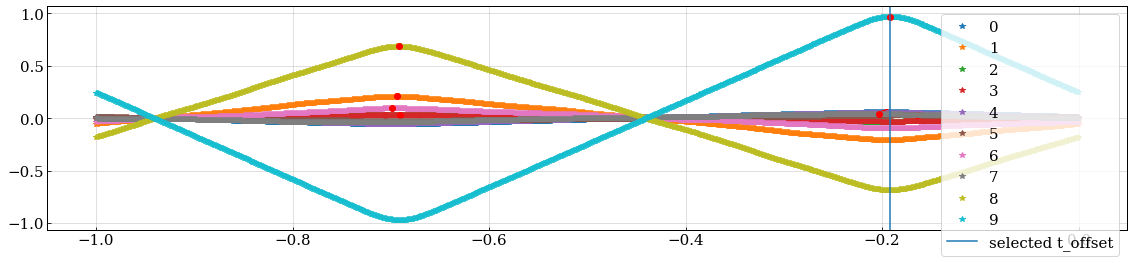

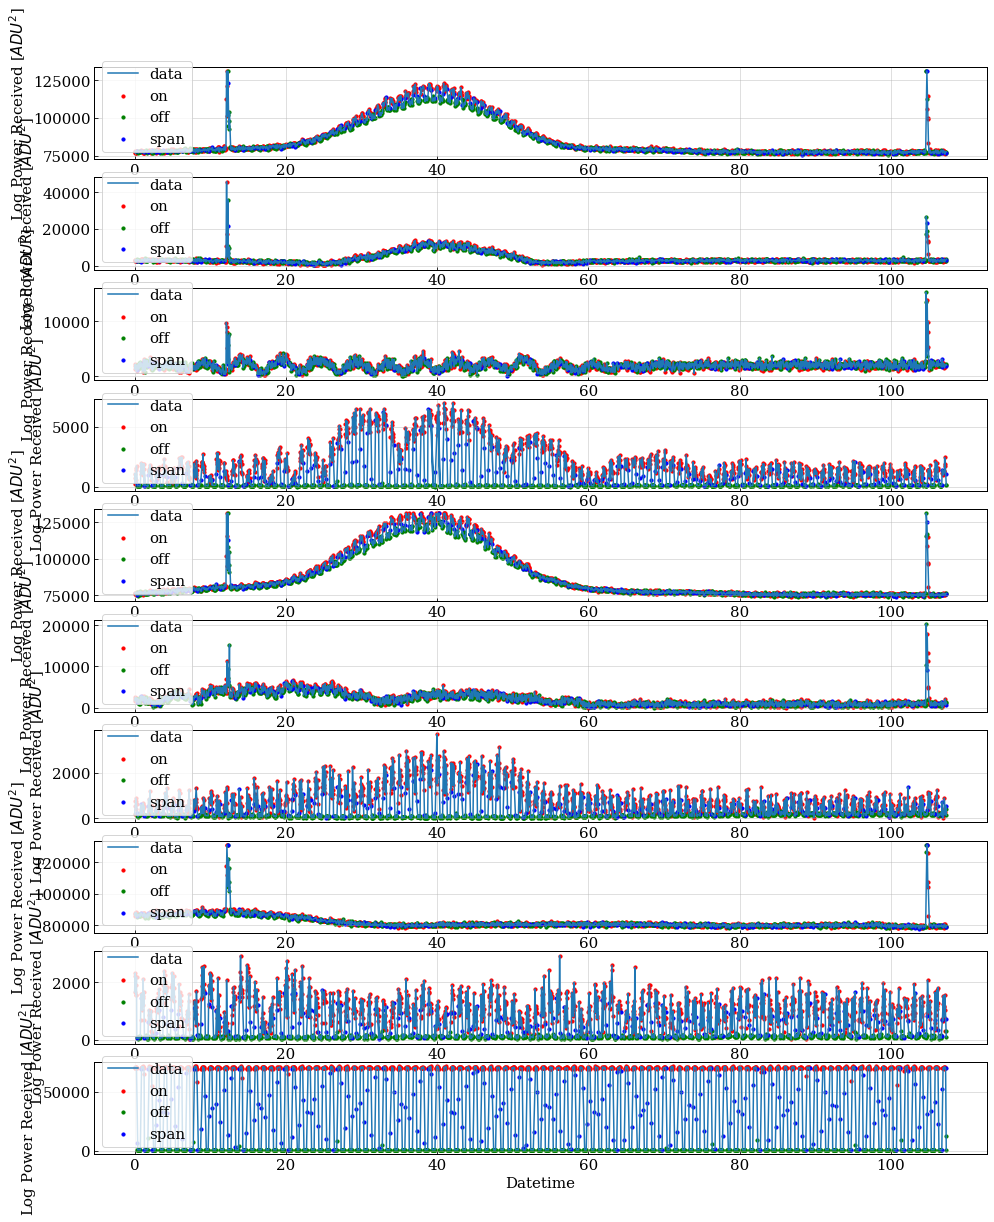

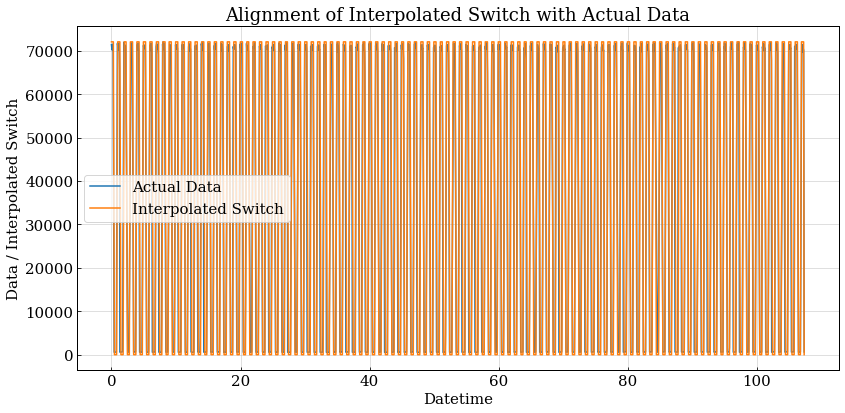

Frequency bin: 470


ValueError: too many values to unpack (expected 8)

In [19]:

"""
    Computing statistics for all angles for a given set of frequencies 
    and saving those in .npz files. 
    
    Statistics collected
    --------------------
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels 

"""
freq_arr = [470] 

for index,f_ind in enumerate(freq_arr):
    avgs,stds,avgs_off,var,var_off,on_inds,off_inds,span = Extract_Source_Pulses(corr_data_,f_ind)
    
    #Saving avgs, std dev and varinces into .npz file (steps of 5 degrees) (range -130 to +130 degrees)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July17...526Z/NS+45/stats_file395_405/means_fbin{}.npz".format(f_ind),avgs=avgs)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July17...526Z/NS+45/stats_file395_405/stds_fbin{}.npz".format(f_ind), stds=stds)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July17...526Z/NS+45/stats_file395_405/means_off_fbin{}.npz".format(f_ind), \
            avgs_off=avgs_off)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July17...526Z/NS+45/stats_file395_405/var_fbin{}.npz".format(f_ind), var=var)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July17...526Z/NS+45/stats_file395_405/var_off_fbin{}.npz".format(f_ind), \
            var_off=var_off)

    #Saving on indices, off indices and span of indices into .npz file (steps of 5 degrees):

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July17...526Z/NS+45/stats_file395_405/inds_on_fbin{}.npz".format(f_ind), \
            on_inds=on_inds)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July17...526Z/NS+45/stats_file395_405/inds_off_fbin{}.npz".format(f_ind), \
            off_inds=off_inds)

    np.savez("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/July17...526Z/NS+45/stats_file395_405/inds_span_fbin{}.npz".format(f_ind), \
            span=span)
    


Maximum Pearson_R Correlations between data and square wave function:
  --> t_indices = [803. 305. 293. 310. 800. 834. 301. 796. 307. 808.]
  --> t_deltas = [-0.197 -0.695 -0.707 -0.69  -0.2   -0.166 -0.699 -0.204 -0.693 -0.192]
Selecting square wave function time offset:
  --> t_delta_pulse = -0.1918000000
Finding relevant pulsing indices and checking for overlaps:
  --> on/off ind intersection: []
  --> on/span ind intersection: []
  --> off/span ind intersection: []


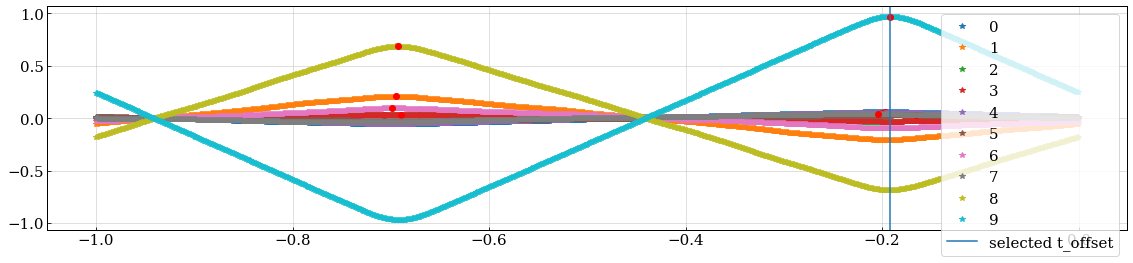

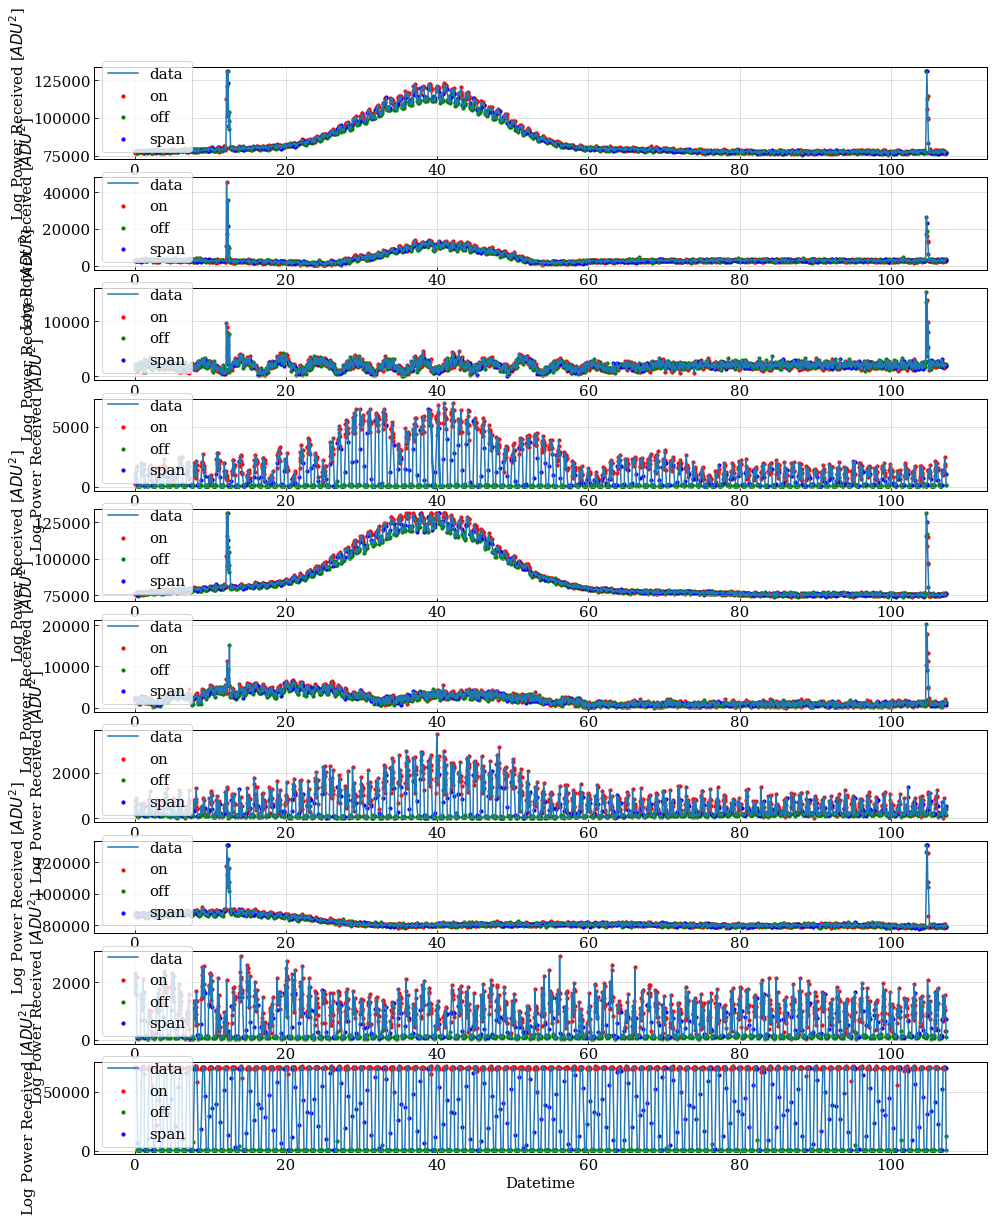

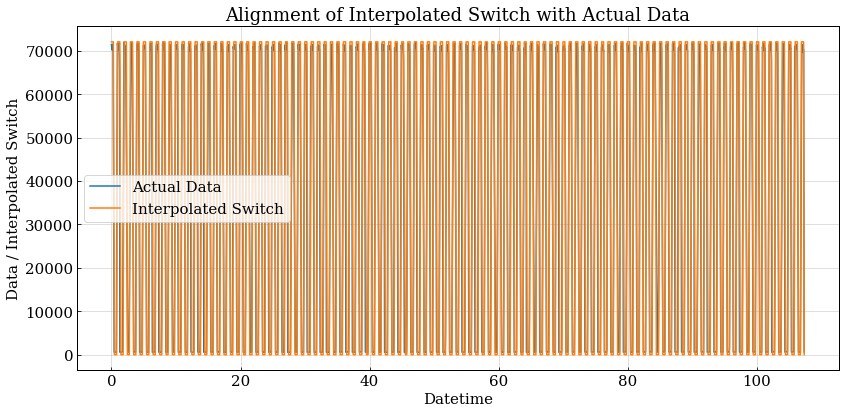

Frequency bin: 470


In [25]:

"""
    Computing statistics for all angles for a given set of frequencies 
    and saving those in .npz files. 
    
    Statistics collected
    --------------------
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels 

"""
f_ind = 470

avgs,stds,avgs_off,var,var_off,on_inds,off_inds,span = Extract_Source_Pulses(corr_data_,f_ind)

In [43]:
print(avgs[0])
print(avgs[3])
print(avgs[9])

[77530.57142857143, 77677.45454545454, 77914.0, 78207.90909090909, 77587.45454545454, 78429.27272727272, 78767.27272727272, 78344.81818181818, 78709.0, 78847.18181818182, 79220.09090909091, 79378.54545454546, 93312.45454545454, 79671.81818181818, 80013.90909090909, 79929.45454545454, 80562.09090909091, 80694.54545454546, 81038.54545454546, 81286.0, 81802.27272727272, 82878.2, 84187.36363636363, 85035.90909090909, 86879.18181818182, 88490.09090909091, 90774.72727272728, 93187.6, 95816.63636363637, 98614.27272727272, 101281.45454545454, 103604.09090909091, 106386.45454545454, 110464.0, 111140.54545454546, 113262.0, 115548.27272727272, 118922.63636363637, 119626.90909090909, 120676.63636363637, 119710.18181818182, 120378.63636363637, 117458.63636363637, 116671.90909090909, 114826.63636363637, 111265.81818181818, 109176.90909090909, 106326.63636363637, 104038.45454545454, 101147.45454545454, 97195.90909090909, 94200.45454545454, 91665.90909090909, 88938.18181818182, 86731.45454545454, 8480

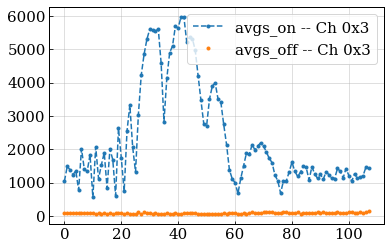

In [69]:
plt.plot(avgs[3], '.--', label="avgs_on -- Ch 0x3")
plt.plot(avgs_off[3], '.', label="avgs_off -- Ch 0x3")
plt.legend()
#plt.plot(avgs[9], '--')

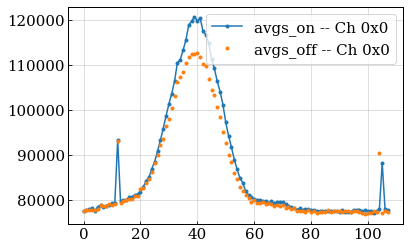

In [72]:
plt.plot(avgs[0],'.-', label="avgs_on -- Ch 0x0")
plt.plot(avgs_off[0],'.', label="avgs_off -- Ch 0x0")
plt.legend()

In [73]:
#What's the frequency corresponding to the given frequency index?
f_ind=470
print(f"Frequency corresponding to frequncy index {f_ind} is {400+((1024-f_ind)*0.390625)}MHz")

Frequency corresponding to frequncy index 470 is 616.40625MHz


In [86]:
print(f"lengths : avgs+ch0x0={len(avgs[0])}, avgs+ch0x3={len(avgs[3])}, avgs+ch3x3={len(avgs[9])}")
print(f"lengths : stds+ch0x0={len(stds[0])}, stds+ch0x3={len(stds[3])}, stds+ch3x3={len(stds[9])}")
print(f"lengths : avgs_off+ch0x0={len(avgs_off[0])}, avgs_off+ch0x3={len(avgs_off[3])}, avgs_off+ch3x3={len(avgs_off[9])}")
print(f"lengths : var+ch0x0={len(var[0])}, var+ch0x3={len(var[3])}, var+ch3x3={len(var[9])}")
print(f"lengths : var_off+ch0x0={len(var_off[0])}, var_off+ch0x3={len(var_off[3])}, var_off+ch3x3={len(var_off[9])}")


lengths : avgs+ch0x0=108, avgs+ch0x3=108, avgs+ch3x3=108
lengths : stds+ch0x0=108, stds+ch0x3=108, stds+ch3x3=108
lengths : avgs_off+ch0x0=108, avgs_off+ch0x3=108, avgs_off+ch3x3=108
lengths : var+ch0x0=108, var+ch0x3=108, var+ch3x3=108
lengths : var_off+ch0x0=108, var_off+ch0x3=108, var_off+ch3x3=108


In [89]:
print(len(off_inds))

1165


In [91]:
print(off_inds)

[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 461, 462, 463,

In [92]:

""" NS-NS configuration --
    Channel 3 -- cross-pol
    Channel 6 -- co-pol
    Channel 8 -- co-pol 
"""

autos_0x0 = avgs[0]
autos_9x9 = avgs[9]
crosses_0x9 = avgs[3]
var_auto0x0 =  var[0]
var_auto9x9 = var[9]
stddev_cross = stds[3]

autos_0x0_off = avgs_off[0]
var_auto0x0_off = var_off[0]

In [99]:
#Computing std dev for single point and compensated for sims where 4*41.9xxms is int time 
stddev_cross4x9 = np.array(stddev_cross)/2
print(stddev_cross4x9)

[256.66138458 177.86964643 159.24156913 140.03046494 244.53532567
 202.76472838 164.59823549 253.93998721 227.03572806 190.26401793
 140.65179163 218.0549995  235.38317084 207.52520515 267.48440382
 163.07621375 172.14422609 283.24006425 160.46886909 239.56619022
 227.69885874 162.83074879 249.0219531  195.79862617 268.76727819
 232.89306527 262.78842146 284.34578432 236.3697475  361.54630705
 213.52257017 270.63978653 220.65931131 234.54293302 242.04365367
 248.6609984  234.69110646 301.46879763 266.72686097 200.96539116
 316.95606497 309.13024237 266.58262306 270.64921296 357.2962886
 135.13556922 201.52015564 290.07006302 185.81547024 292.42555373
 233.12599415 189.16899546 150.7455066  169.2570055  192.63124923
 161.16994245 286.24166925 260.53992713 220.80838194 158.78452373
 148.96559934 114.42238884 172.75027405 235.76914482 227.24265291
 150.4678238  104.04730485 129.3888297  187.19325697 247.56301947
 265.14454339 170.03054587 139.05059618 216.18865791 205.61149879
 160.308914

In [96]:
"""autos0x0 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF
"""
g_autos_0x0 = []
[g_autos_0x0.append((autos_0x0[i] - autos_0x0_off[i]) / autos_9x9[i]) for i in np.arange(0, np.size(autos_0x0_off))]

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [101]:
g_autos_0x0

[-0.00031304555895514516,
 -0.0008508426316122198,
 0.0011039128218869186,
 0.006057134766743604,
 -0.0025547600263069307,
 0.006250562447772706,
 -0.0014933103039696655,
 -0.004971734529984494,
 0.0014470072931675286,
 -0.0021329395071081852,
 0.00688528341374302,
 0.0032678815033283675,
 0.003997332541833147,
 0.004723231267069866,
 0.003981867412273328,
 0.0005139209463357401,
 0.0052503269387210024,
 0.00818794482584875,
 0.0040009214087259,
 0.005875812246524471,
 -0.007156370058929685,
 0.004376131960452274,
 0.00793097325548176,
 0.005549493816168069,
 0.011315226400909826,
 0.005002487104971385,
 0.011517334684975877,
 0.015389428231338645,
 0.032740244676427464,
 0.03278724370294811,
 0.048396876742315756,
 0.04570819309919594,
 0.04618884100270745,
 0.06192662349695742,
 0.05591521850489469,
 0.0688584928865886,
 0.07157285672956375,
 0.10194170383385157,
 0.1031315175657639,
 0.11777881867033463,
 0.10071169753947924,
 0.12202928692590247,
 0.10427780651437127,
 0.0981931685

In [142]:
## conversion to log scale  -- correlator data
# dividing factor -- np.sqrt(autos_1x1)

autolog_9x9=10*np.log10(autos_9x9)- 48.5 # giving offset to match the range of VNA plots ## ref ch\
crosslog_0x9=20*np.log10(crosses_0x9/np.sqrt(autos_9x9)) - 27.0 # giving offset to match the range of VNA plots \
autolog_0x0=10*np.log10(autos_0x0) - 50.8 # giving offset to match the range of VNA plots ## test ch\
g_autolog_0x0=10*np.log10(g_autos_0x0) + 9.5
autolog_0x0_off=10*np.log10(autos_0x0_off) - 50.8 # offset is same as that of autolog0x0 - giving offset to match the range of VNA plots\


/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_73884/1784630404.py:7: RuntimeWarning: invalid value encountered in log10
  g_autolog_0x0=10*np.log10(g_autos_0x0) + 9.5


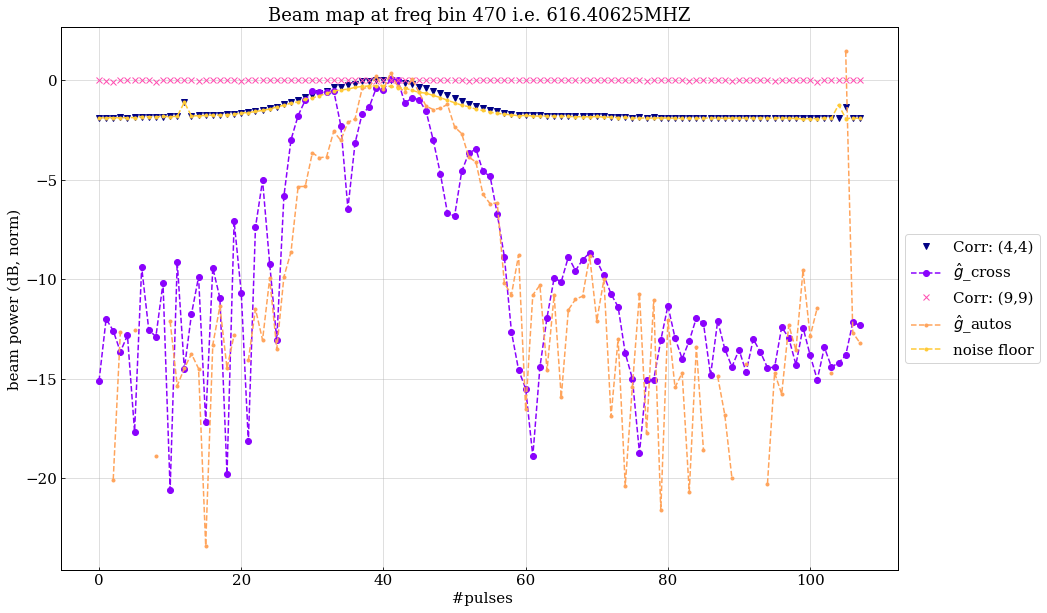

In [167]:
""" Plotting beam pattern with correlator data: """ 

colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
fig = plt.figure(figsize=[15,10])
ax = plt.subplot(111)

#Logarithmic scale -- 
angles = np.arange(0,108,1)
angles_off=np.arange(0,108,1)
angles1 = np.arange(0,108,1)

ax.plot(angles, autolog_0x0, "v", c=colorsarr[f_ind-200], label='Corr: (4,4)') 
ax.plot(angles, crosslog_0x9, "o--",  c=colorsarr[f_ind+400],label='$\hat{g}$_cross') 
ax.plot(angles, autolog_9x9, "x", c=colorsarr[f_ind+700],label='Corr: (9,9)') 
ax.plot(angles, g_autolog_0x0[:], ".--", c=colorsarr[f_ind-1000],label='$\hat{g}$_autos') 
ax.plot(angles_off, autolog_0x0_off[:], ".--", c=colorsarr[f_ind+1200], label='noise floor') 

#ax.fill_between(angles, yerr_cross_lo, yerr_cross_hi, alpha=0.25, color='tab:blue', label='1$\sigma$ error $\hat{g}$_cross')
#ax.fill_between(angles, yerr_cross_lo2, yerr_cross_hi2, alpha=0.15, color='tab:pink', label='2$\sigma$ error $\hat{g}$_cross')
#ax.fill_between(angles_off, yerr_gauto_lo, yerr_gauto_hi, alpha=0.25, color='tab:cyan', label='1$\sigma$ error $\hat{g}$_auto')
#ax.fill_between(angles_off, yerr_gauto_lo2, yerr_gauto_hi2, alpha=0.15, color='tab:red', label='2$\sigma$ error $\hat{g}$_auto')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
freq=400+((1024-f_ind)*0.390625) 
#plt.xlim(0,200) 
plt.title("Beam map at freq bin {} i.e. {}MHZ".format(f_ind, freq))
plt.xlabel(" #pulses")
plt.ylabel("beam power (dB, norm)") 
plt.show()